# Definicão do Problema.

Este trabalha tem por objetivo, avaliar ações listadas na B3 `PETR4.SA, VALE3.SA, ITAB4.SA, WEGE3.SA ˆBVSP S&P500 e Dowjones USD/BRA` para os 5 anos, fatores economicos de ações de marcado podem ser analizado de formas como: `Ativos correlacionados` que nada mais é fatores macroeconomicos como: politicas fiscais, politicas cambiais, cenário geopolítico, acesso a capital; `Indicadores tecnicos`, como media movel, media movel expoencial, momentum de mercado; `Análise Fundamentalista`, como os relatorios de desempenho como `ROE` e `P/L` e `Noticias`.

- Apresentaremos retorno acumulado de um determinado ativo;
- Performace sobre cada ação;
- E os periodos de volatividade de mercado.

In [84]:
import sys
print(sys.executable)

/Users/francismaralvesmartinsjunior/anaconda3/envs/acoes_pred/bin/python


# ============================================================
# PLATAFORMA ÚNICA (1 arquivo) - OTIMIZADA + ROBUSTA (sem erro "zero-size array")
# Dados -> Dataset (multi-horizonte) -> EDA -> Modelos -> Resultados
# - Salva gráficos em JPEG
# - Salva resultados em CSV
# - Valida tamanho mínimo para evitar arrays vazios
# ============================================================

In [85]:
# ============================================================
# PLATAFORMA ÚNICA (1 arquivo) - OTIMIZADA + ROBUSTA (sem erro "zero-size array")
# Dados -> Dataset (multi-horizonte) -> EDA -> Modelos -> Resultados
# - Salva gráficos em JPEG
# - Salva resultados em CSV
# - Valida tamanho mínimo para evitar arrays vazios
# ============================================================

import os
from dataclasses import dataclass
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

import statsmodels.api as sm

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore")










# ============================================================
# 0) CONFIG
# ============================================================


In [102]:
# ============================================================
# 0) CONFIG
# ============================================================

@dataclass
class Config:
    # dados
    years: int = 10
    auto_adjust: bool = True
    seed: int = 42

    # horizontes (dias úteis)
    horizons: tuple = (5, 21, 63, 126, 252)

    # validação
    train_ratio: float = 0.8
    desired_folds: int = 10
    min_test_size: int = 10  # tamanho mínimo do fold de validação

    # robustez (evita dataset vazio)
    min_rows_rule_multiplier: int = 5     # min_rows = max(multiplier*h, 100)
    min_rows_floor: int = 100             # mínimo absoluto
    min_features: int = 2                 # mínimo de colunas para rodar EDA
    decompose_cycles: int = 3             # precisa de 3 ciclos completos

    # dataset
    use_expanding_zscore: bool = True     # evita leakage
    downsample: bool = False              # NÃO recomendo (reduz amostras)

    # output
    out_dir: str = "outputs"
    plots_dir: str = "outputs/graficos"
    results_dir: str = "outputs/resultados"
    save_csv_prices: bool = True
    save_csv_results: bool = True
    save_plots: bool = True

CFG = Config()

# ============================================================
# 1) UTIL: pastas + timestamp + salvar figura
# ============================================================

In [103]:


def ensure_dirs(cfg: Config):
    os.makedirs(cfg.out_dir, exist_ok=True)
    os.makedirs(cfg.plots_dir, exist_ok=True)
    os.makedirs(cfg.results_dir, exist_ok=True)

def ts_now():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def save_fig(fig=None, name="plot", cfg: Config = CFG, dpi=300):
    if not cfg.save_plots:
        return None
    if fig is None:
        fig = plt.gcf()
    path = os.path.join(cfg.plots_dir, f"{name}_{ts_now()}.jpeg")
    fig.savefig(path, format="jpeg", dpi=dpi, bbox_inches="tight")
    print("📷 Plot salvo:", path)
    return path


# ============================================================
# 2) DOWNLOAD + PREPARAÇÃO (BRL)
# ============================================================

In [104]:


def download_market_brl(cfg: Config) -> pd.DataFrame:
    tickers = [
        "PETR4.SA", "VALE3.SA", "ITUB4.SA", "WEGE3.SA",
        "^BVSP", "^GSPC", "^DJI",
        "USDBRL=X"
    ]

    end = pd.Timestamp.today().normalize()
    start = end - pd.DateOffset(years=cfg.years)

    data = yf.download(
        tickers=tickers,
        start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=cfg.auto_adjust,
        group_by="column",
        progress=False,
        threads=True
    )

    price_col = "Close" if cfg.auto_adjust else "Adj Close"
    px = data[price_col].copy().sort_index()

    # alinhar calendário BR/EUA
    px = px.ffill().dropna()
    if px.empty:
        raise RuntimeError("Download retornou DataFrame vazio. Verifique internet/tickers/período.")

    # EUA -> BRL
    if "^GSPC" in px.columns and "USDBRL=X" in px.columns:
        px["SP500_BRL"] = px["^GSPC"] * px["USDBRL=X"]
    if "^DJI" in px.columns and "USDBRL=X" in px.columns:
        px["DOWJONES_BRL"] = px["^DJI"] * px["USDBRL=X"]

    # renomear
    px = px.rename(columns={
        "PETR4.SA": "PETR4_BRL",
        "VALE3.SA": "VALE3_BRL",
        "ITUB4.SA": "ITUB4_BRL",
        "WEGE3.SA": "WEGE3_BRL",
        "^BVSP": "IBOV_PONTOS",
        "USDBRL=X": "USD_BRL",
    })

    # remover originais EUA
    for c in ["^GSPC", "^DJI"]:
        if c in px.columns:
            px.drop(columns=[c], inplace=True)

    if cfg.save_csv_prices:
        path = os.path.join(cfg.results_dir, f"prices_market_brl_{start.date()}_{end.date()}.csv")
        px.to_csv(path, encoding="utf-8")
        print("💾 CSV preços salvo:", path)

    print(px.head())
    return px

# ============================================================
# 3) DATASET PETR4 (robusto)
# ============================================================

In [105]:
def build_dataset_petr4(px: pd.DataFrame, horizon: int, cfg: Config):
    if "PETR4_BRL" not in px.columns:
        raise ValueError("Coluna obrigatória 'PETR4_BRL' não encontrada.")

    other_stocks = [c for c in ["VALE3_BRL", "ITUB4_BRL", "WEGE3_BRL"] if c in px.columns]
    fx_cols = [c for c in ["USD_BRL"] if c in px.columns]
    idx_cols = [c for c in ["IBOV_PONTOS", "SP500_BRL", "DOWJONES_BRL"] if c in px.columns]

    use_cols = ["PETR4_BRL"] + other_stocks + fx_cols + idx_cols
    df = px[use_cols].sort_index().copy()

    # log preços (evita -inf)
    if (df <= 0).any().any():
        df = df.where(df > 0).ffill().dropna()

    logp = np.log(df)

    # Y: retorno futuro
    Y = logp["PETR4_BRL"].diff(horizon).shift(-horizon).rename("PETR4_pred")

    parts = []

    # retornos ações ex-alvo
    if other_stocks:
        parts.append(logp[other_stocks].diff(horizon))

    # retorno câmbio
    if fx_cols:
        parts.append(logp[fx_cols].diff(horizon))

    # índices -> retorno -> z-score
    if idx_cols:
        idx_ret = logp[idx_cols].diff(horizon)
        if cfg.use_expanding_zscore:
            mu = idx_ret.expanding(min_periods=horizon).mean()
            sd = idx_ret.expanding(min_periods=horizon).std(ddof=0).replace(0, np.nan)
            Z = ((idx_ret - mu) / sd).add_prefix("Z_")
        else:
            sd = idx_ret.std(ddof=0).replace(0, np.nan)
            Z = ((idx_ret - idx_ret.mean()) / sd).add_prefix("Z_")
        parts.append(Z)

    # lags da própria PETR4
    lags = [horizon, horizon * 3, horizon * 6, horizon * 12]
    X_lags = pd.DataFrame(
        {
            "PETR4_DT": logp["PETR4_BRL"].diff(lags[0]),
            "PETR4_3DT": logp["PETR4_BRL"].diff(lags[1]),
            "PETR4_6DT": logp["PETR4_BRL"].diff(lags[2]),
            "PETR4_12DT": logp["PETR4_BRL"].diff(lags[3]),
        },
        index=df.index
    )
    parts.append(X_lags)

    X = pd.concat(parts, axis=1)
    dataset = pd.concat([Y, X], axis=1).dropna()

    if cfg.downsample:
        dataset = dataset.iloc[::horizon].copy()

    X_final = dataset.drop(columns=["PETR4_pred"])
    Y_final = dataset["PETR4_pred"]

    return dataset, X_final, Y_final, idx_cols


# ============================================================
# 4) EDA (com checagens para não quebrar)
# ============================================================


In [106]:
def plot_corr_heatmap(dataset: pd.DataFrame, horizon: int, cfg: Config):
    if dataset.shape[0] < 30 or dataset.shape[1] < cfg.min_features:
        print("⚠️ Heatmap pulado: dataset pequeno demais.")
        return

    corr = dataset.corr(numeric_only=True)
    if corr.empty:
        print("⚠️ Heatmap pulado: correlação vazia.")
        return

    fig = plt.figure(figsize=(14, 12))
    sns.heatmap(corr, vmin=-1, vmax=1, center=0, square=True, cmap="coolwarm", annot=False)
    plt.title(f"Matriz de Correlação - PETR4 (h={horizon})")
    plt.tight_layout()
    save_fig(fig, f"heatmap_h{horizon}", cfg)
    plt.show()

def plot_scatter_top(dataset: pd.DataFrame, horizon: int, cfg: Config, top_n=6):
    if dataset.shape[0] < 30 or dataset.shape[1] < cfg.min_features:
        print("⚠️ Scatter pulado: dataset pequeno demais.")
        return

    corr = dataset.corr(numeric_only=True)
    if "PETR4_pred" not in corr.columns:
        print("⚠️ Scatter pulado: correlação sem alvo.")
        return

    s = corr["PETR4_pred"].abs().sort_values(ascending=False).dropna()
    if len(s) < 2:
        print("⚠️ Scatter pulado: poucas variáveis correlacionadas.")
        return

    top_vars = s.head(min(top_n, len(s))).index

    fig = plt.figure(figsize=(10, 10))
    scatter_matrix(dataset[top_vars], alpha=0.6, diagonal="kde", figsize=(10, 10))
    plt.suptitle(f"Scatter Top Vars - PETR4 (h={horizon})", y=1.02)
    save_fig(fig, f"scatter_h{horizon}", cfg)
    plt.show()

def plot_decompose(series: pd.Series, horizon: int, cfg: Config):
    s = series.dropna().sort_index().astype(float)

    period = 12 if horizon >= 21 else 52
    min_len = period * cfg.decompose_cycles

    if len(s) < min_len:
        print(f"⚠️ Decomposição pulada: série curta ({len(s)} < {min_len}).")
        return

    res = sm.tsa.seasonal_decompose(s, model="additive", period=period, extrapolate_trend="freq")
    fig = res.plot()
    fig.set_size_inches(15, 8)
    fig.suptitle(f"Decomposição Sazonal (h={horizon}, period={period})", y=1.02)
    fig.tight_layout()
    save_fig(fig, f"decompose_h{horizon}", cfg)
    plt.show()

# ============================================================
# 5) MODELOS
# ============================================================


In [107]:
def get_models(cfg: Config):
    seed = cfg.seed
    return [
        ("LR", LinearRegression()),
        ("LASSO", Lasso(alpha=0.001, max_iter=5000, random_state=seed)),
        ("EN", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=seed)),
        ("KNN", KNeighborsRegressor(n_neighbors=10, weights="distance")),
        ("CART", DecisionTreeRegressor(max_depth=5, random_state=seed)),
        ("SVR", SVR(kernel="rbf", C=10, epsilon=0.01)),
        ("MLP", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            learning_rate="adaptive",
            max_iter=2000,
            early_stopping=True,
            random_state=seed
        )),
        ("ABR", AdaBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=seed)),
        ("GBR", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=seed)),
        ("RFR", RandomForestRegressor(n_estimators=500, max_depth=6, n_jobs=-1, random_state=seed)),
        ("ETR", ExtraTreesRegressor(n_estimators=500, max_depth=6, n_jobs=-1, random_state=seed)),
    ]

# ============================================================
# 6) AVALIAÇÃO (robusta contra dataset pequeno)
# ============================================================

In [108]:


def safe_n_splits(n_train: int, desired: int, min_test: int):
    max_splits = (n_train // min_test) - 1
    return max(2, min(desired, max_splits))

def evaluate_models(X: pd.DataFrame, y: pd.Series, horizon: int, cfg: Config) -> pd.DataFrame:
    # checagens para evitar arrays vazios
    if X.empty or y.empty or len(X) != len(y):
        print("⚠️ Avaliação pulada: X/y vazios ou tamanhos incompatíveis.")
        return pd.DataFrame()

    split = int(len(X) * cfg.train_ratio)
    if split < cfg.min_test_size * 3:
        print("⚠️ Avaliação pulada: treino muito pequeno.")
        return pd.DataFrame()

    X_train, y_train = X.iloc[:split], y.iloc[:split]
    X_test, y_test = X.iloc[split:], y.iloc[split:]

    if len(X_test) < cfg.min_test_size:
        print("⚠️ Avaliação pulada: teste muito pequeno.")
        return pd.DataFrame()

    n_splits = safe_n_splits(len(X_train), cfg.desired_folds, cfg.min_test_size)
    if n_splits < 2:
        print("⚠️ Avaliação pulada: n_splits inválido.")
        return pd.DataFrame()

    tscv = TimeSeriesSplit(n_splits=n_splits)
    models = get_models(cfg)

    rows = []
    cv_map = {}

    for name, model in models:
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])

        cv_mse = -cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=tscv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        # proteção extra
        if cv_mse.size == 0:
            print(f"⚠️ {name}: CV vazio, pulando.")
            continue

        cv_map[name] = cv_mse

        pipe.fit(X_train, y_train)
        train_mse = mean_squared_error(y_train, pipe.predict(X_train))
        test_mse = mean_squared_error(y_test, pipe.predict(X_test))

        rows.append({
            "Horizon": horizon,
            "Model": name,
            "CV_MSE_mean": float(np.mean(cv_mse)),
            "CV_MSE_std": float(np.std(cv_mse)),
            "Train_MSE": float(train_mse),
            "Test_MSE": float(test_mse),
            "n_splits": int(n_splits),
            "n_train": int(len(X_train)),
            "n_test": int(len(X_test)),
        })

    if not rows:
        print("⚠️ Nenhum modelo avaliável neste horizonte.")
        return pd.DataFrame()

    results = pd.DataFrame(rows).sort_values("Test_MSE").reset_index(drop=True)

    # salvar CSV
    if cfg.save_csv_results:
        path = os.path.join(cfg.results_dir, f"results_h{horizon}_{ts_now()}.csv")
        results.to_csv(path, index=False, encoding="utf-8")
        print("💾 CSV resultados salvo:", path)

    # boxplot (ordem do ranking)
    names_sorted = results["Model"].tolist()

    fig = plt.figure(figsize=(15, 8))
    plt.title(f"CV Results (MSE) - Horizon={horizon} | n_splits={n_splits}")
    plt.boxplot([cv_map[n] for n in names_sorted if n in cv_map])
    plt.xticks(range(1, len([n for n in names_sorted if n in cv_map]) + 1),
               [n for n in names_sorted if n in cv_map])
    plt.tight_layout()
    save_fig(fig, f"cv_boxplot_h{horizon}", cfg)
    plt.show()

    # barras Train vs Test
    ind = np.arange(len(names_sorted))
    width = 0.35

    fig = plt.figure(figsize=(15, 8))
    plt.title(f"Train vs Test (MSE) - Horizon={horizon}")
    plt.bar(ind - width/2, results["Train_MSE"].values, width=width, label="Train MSE")
    plt.bar(ind + width/2, results["Test_MSE"].values, width=width, label="Test MSE")
    plt.xticks(ind, names_sorted)
    plt.legend()
    plt.tight_layout()
    save_fig(fig, f"train_vs_test_h{horizon}", cfg)
    plt.show()

    print("\nResumo (ordenado por Test_MSE):")
    print(results.to_string(index=False, formatters={
        "CV_MSE_mean": "{:.6f}".format,
        "CV_MSE_std":  "{:.6f}".format,
        "Train_MSE":   "{:.6f}".format,
        "Test_MSE":    "{:.6f}".format,
    }))

    return results

# ============================================================
# 7) ORQUESTRAÇÃO MULTI-HORIZONTE (com validações)
# ============================================================

In [109]:


def min_rows_for_horizon(h: int, cfg: Config) -> int:
    return max(cfg.min_rows_rule_multiplier * h, cfg.min_rows_floor)

def run(cfg: Config):
    ensure_dirs(cfg)
    px = download_market_brl(cfg)

    all_results = []

    for h in cfg.horizons:
        print("\n" + "=" * 60)
        print(f"🚀 HORIZONTE: {h} dias")
        print("=" * 60)

        dataset, X, y, idx_cols = build_dataset_petr4(px, horizon=h, cfg=cfg)

        print("Índices incluídos:", idx_cols)
        print("Dataset:", dataset.shape, "| X:", X.shape, "| y:", y.shape)

        # ---- VALIDAÇÃO: evita array vazio (corr/min/max etc.)
        min_rows = min_rows_for_horizon(h, cfg)
        if len(dataset) < min_rows:
            print(f"⚠️ Pulando horizonte {h}: dataset pequeno ({len(dataset)} < {min_rows}).")
            continue

        # EDA (somente se tiver dados suficientes)
        plot_corr_heatmap(dataset, horizon=h, cfg=cfg)
        plot_scatter_top(dataset, horizon=h, cfg=cfg, top_n=6)
        plot_decompose(y, horizon=h, cfg=cfg)

        # ML (somente se tiver dados suficientes)
        res_h = evaluate_models(X, y, horizon=h, cfg=cfg)
        if not res_h.empty:
            all_results.append(res_h)

    if not all_results:
        print("\n❌ Nenhum horizonte gerou resultados. Diminua horizontes ou aumente years.")
        return px, pd.DataFrame(), pd.DataFrame()

    all_results = pd.concat(all_results, axis=0).reset_index(drop=True)

    if cfg.save_csv_results:
        path = os.path.join(cfg.results_dir, f"results_ALL_{ts_now()}.csv")
        all_results.to_csv(path, index=False, encoding="utf-8")
        print("\n💾 CSV resumo global salvo:", path)

    best = all_results.sort_values(["Horizon", "Test_MSE"]).groupby("Horizon").head(1)

    print("\n🏆 Melhor modelo por horizonte (menor Test_MSE):")
    print(best[["Horizon", "Model", "Test_MSE", "CV_MSE_mean", "CV_MSE_std", "n_splits", "n_train", "n_test"]]
          .to_string(index=False, formatters={
              "Test_MSE": "{:.6f}".format,
              "CV_MSE_mean": "{:.6f}".format,
              "CV_MSE_std": "{:.6f}".format
          }))

    return px, all_results, best

# ============================================================
# 8) EXECUÇÃO
# ============================================================

💾 CSV preços salvo: outputs/resultados/prices_market_brl_2016-02-27_2026-02-27.csv
Ticker      ITUB4_BRL  PETR4_BRL  USD_BRL  VALE3_BRL  WEGE3_BRL  IBOV_PONTOS  \
Date                                                                           
2016-02-29   7.673161   1.369432   3.9647   5.839017   4.169322      42794.0   
2016-03-01   8.034376   1.414724   4.0129   6.333433   4.188287      44122.0   
2016-03-02   8.221783   1.505310   3.9220   7.030555   4.314729      44893.0   
2016-03-03   9.034895   1.750422   3.8893   7.722733   4.283119      47193.0   
2016-03-04   9.476213   1.923600   3.7961   8.182537   4.340014      49085.0   

Ticker        SP500_BRL  DOWJONES_BRL  
Date                                   
2016-02-29  7660.712172  65482.967279  
2016-03-01  7938.920371  67677.877748  
2016-03-02  7790.856572  66279.133105  
2016-03-03  7752.930930  65899.913618  
2016-03-04  7592.161804  64559.396137  

🚀 HORIZONTE: 5 dias
Índices incluídos: ['IBOV_PONTOS', 'SP500_BRL', 'DOWJON

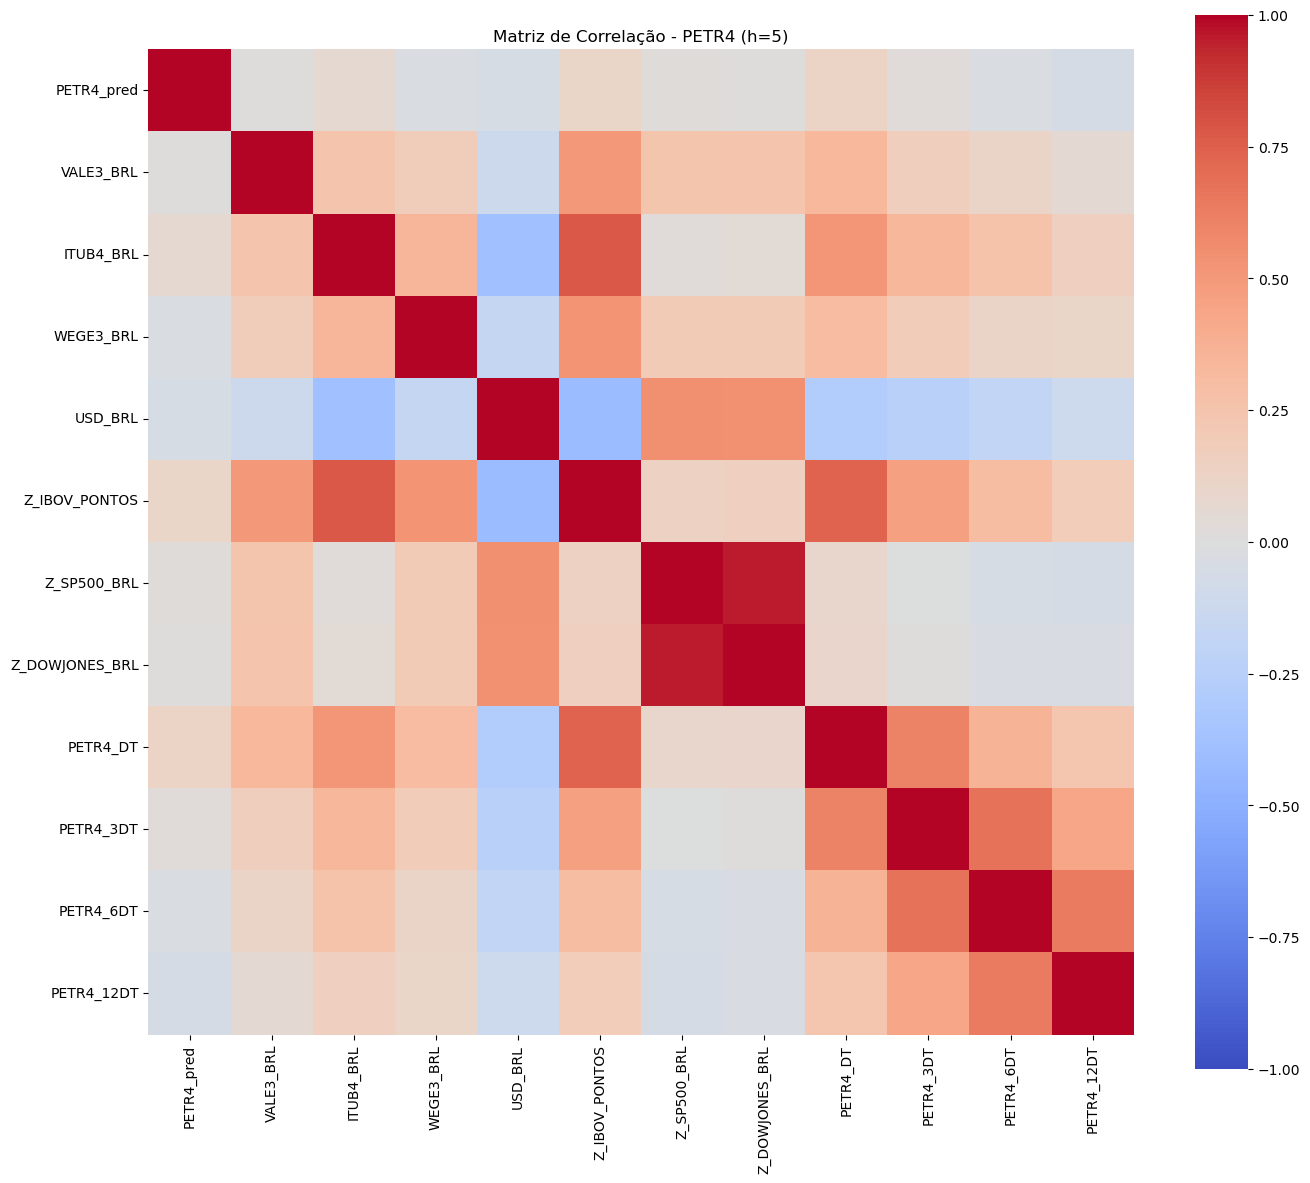

📷 Plot salvo: outputs/graficos/scatter_h5_20260227_200243.jpeg


<Figure size 1000x1000 with 0 Axes>

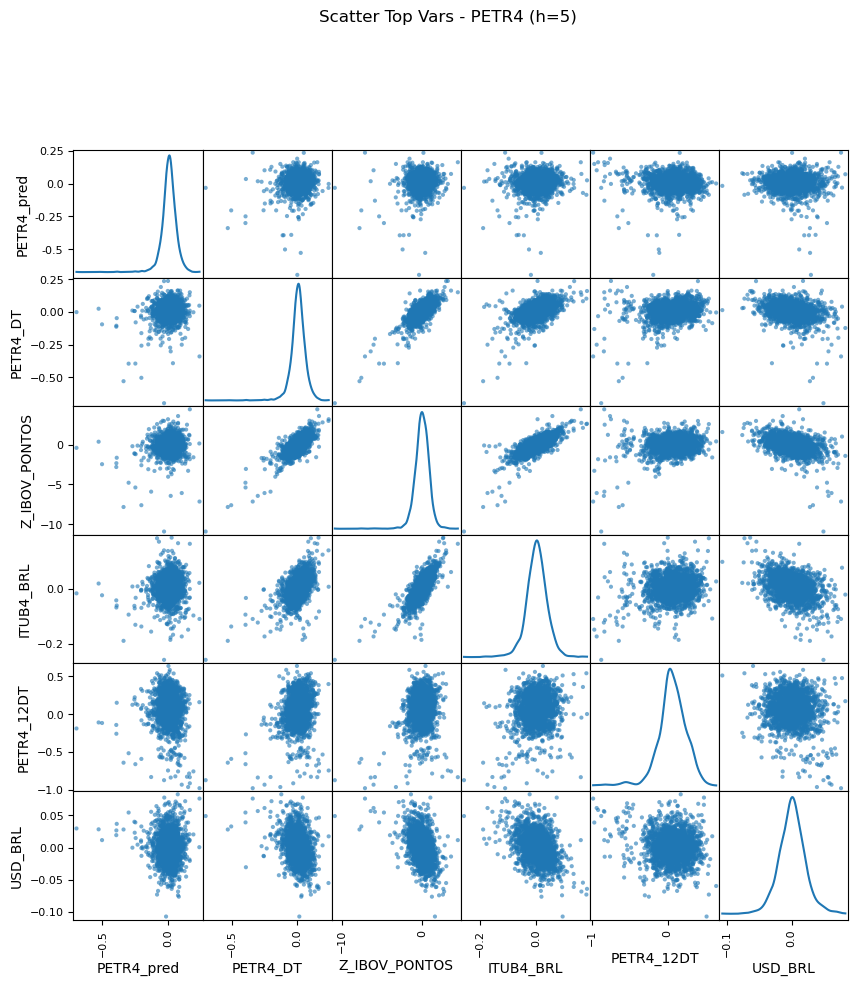

📷 Plot salvo: outputs/graficos/decompose_h5_20260227_200244.jpeg


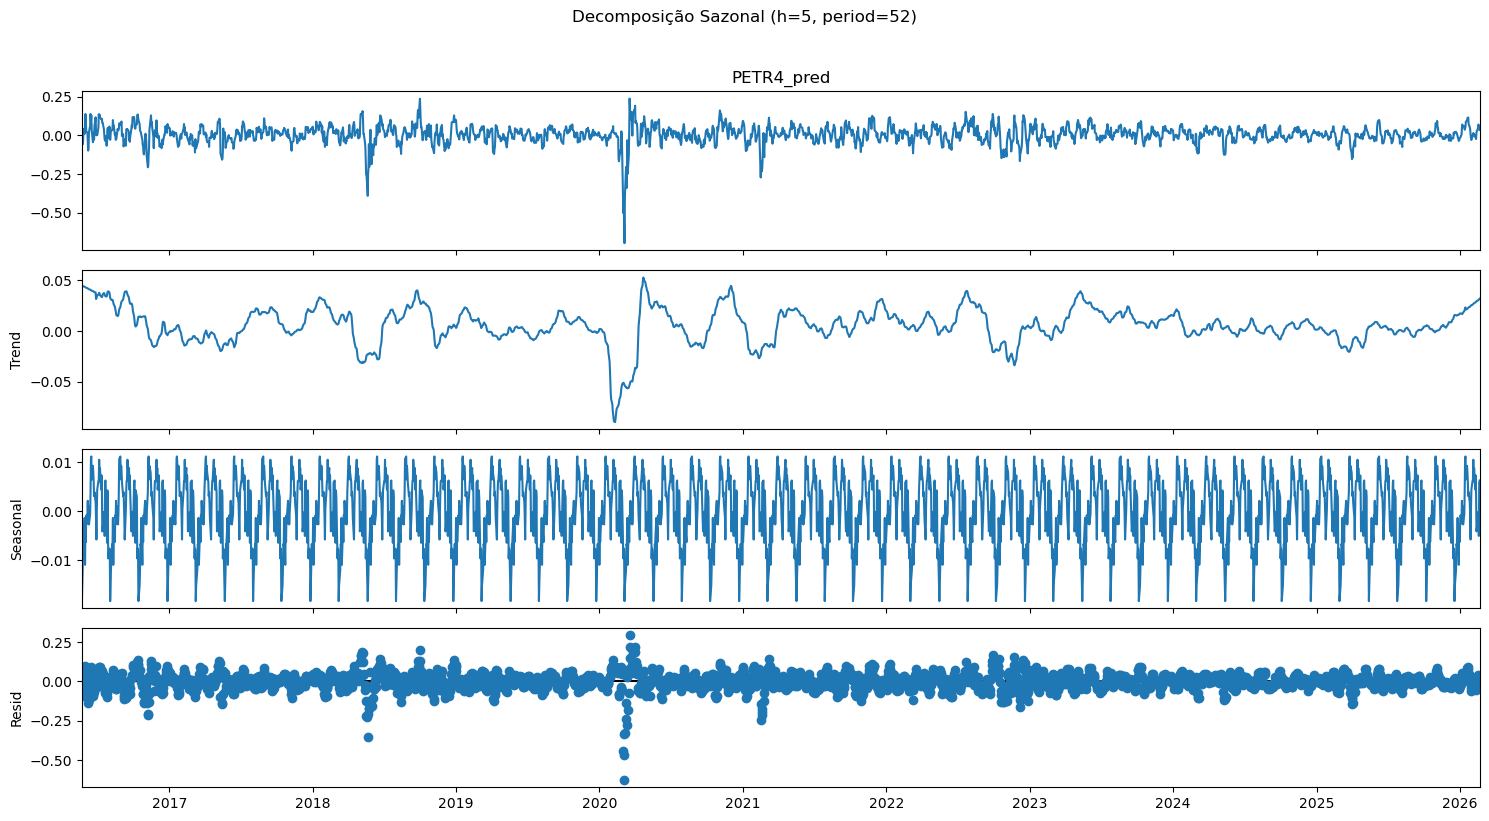

💾 CSV resultados salvo: outputs/resultados/results_h5_20260227_200314.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h5_20260227_200314.jpeg


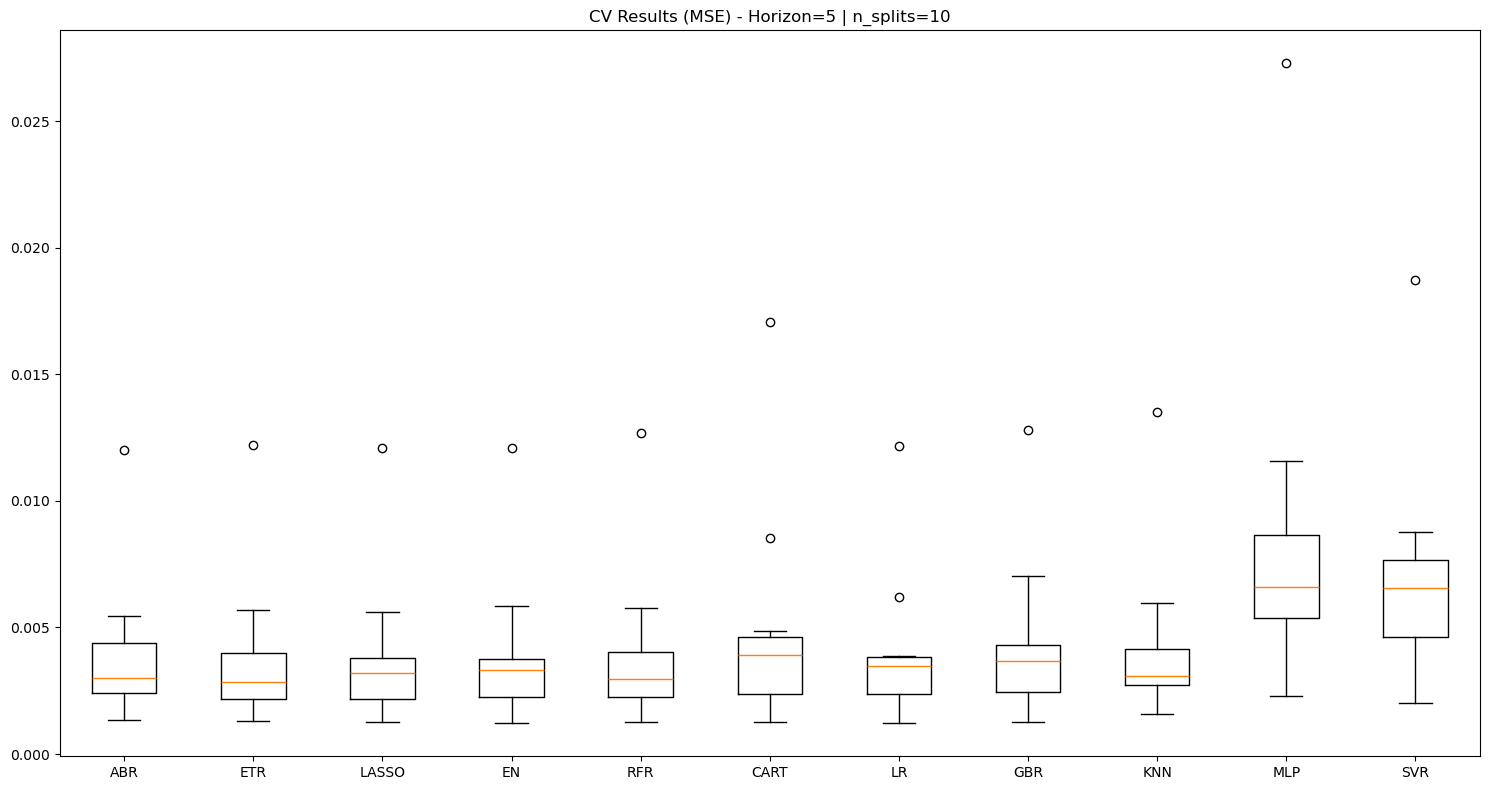

📷 Plot salvo: outputs/graficos/train_vs_test_h5_20260227_200315.jpeg


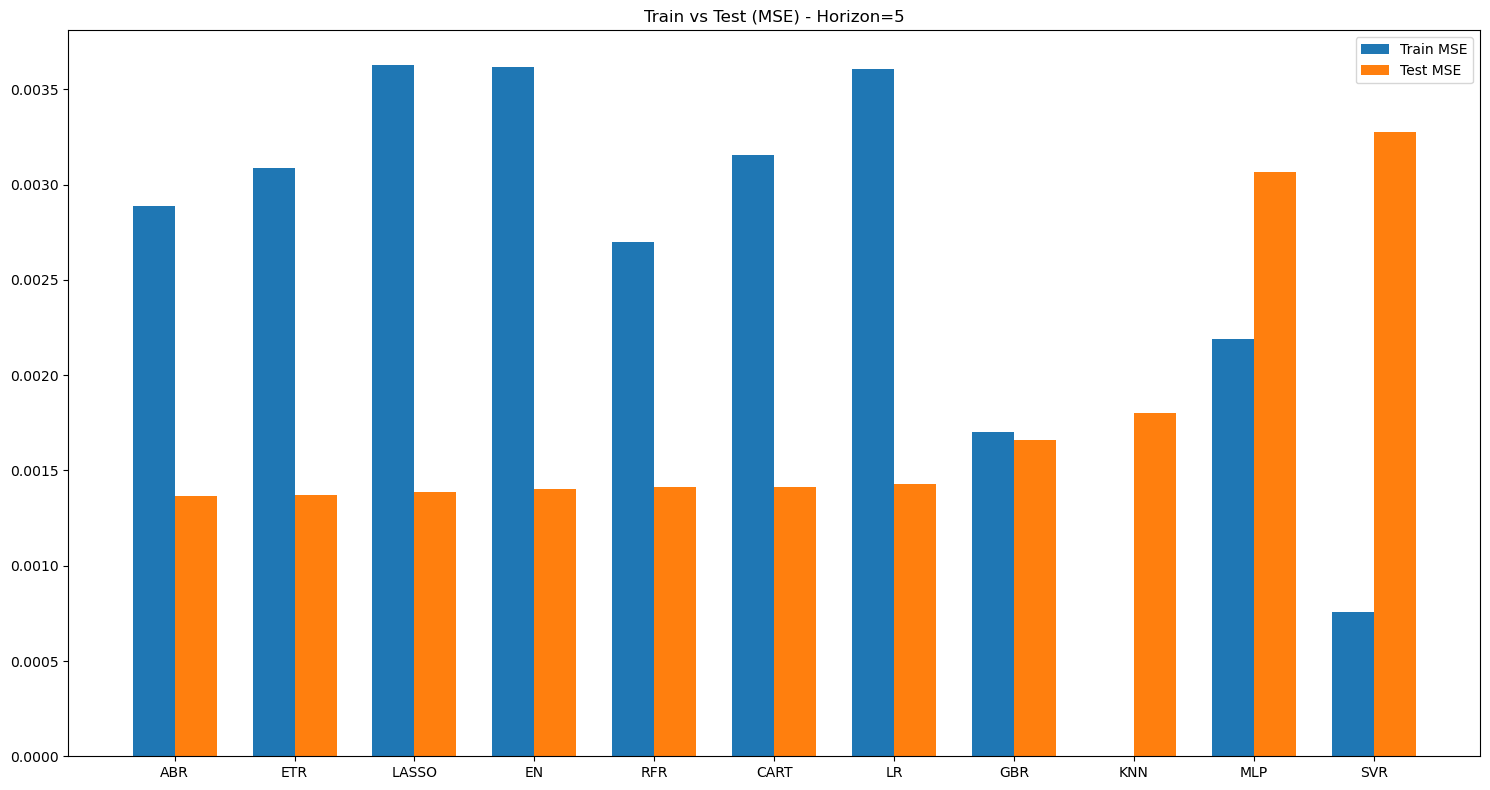


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
       5   ABR    0.004016   0.002907  0.002886 0.001366        10     2032     509
       5   ETR    0.003867   0.003052  0.003090 0.001369        10     2032     509
       5 LASSO    0.003877   0.003000  0.003629 0.001386        10     2032     509
       5    EN    0.003933   0.003000  0.003618 0.001403        10     2032     509
       5   RFR    0.003965   0.003168  0.002698 0.001411        10     2032     509
       5  CART    0.004983   0.004485  0.003156 0.001413        10     2032     509
       5    LR    0.004048   0.003032  0.003606 0.001428        10     2032     509
       5   GBR    0.004408   0.003190  0.001701 0.001659        10     2032     509
       5   KNN    0.004271   0.003304  0.000000 0.001803        10     2032     509
       5   MLP    0.008611   0.006687  0.002189 0.003065        10     2032     509
       5   SVR    0.007153   0.004294  0.00

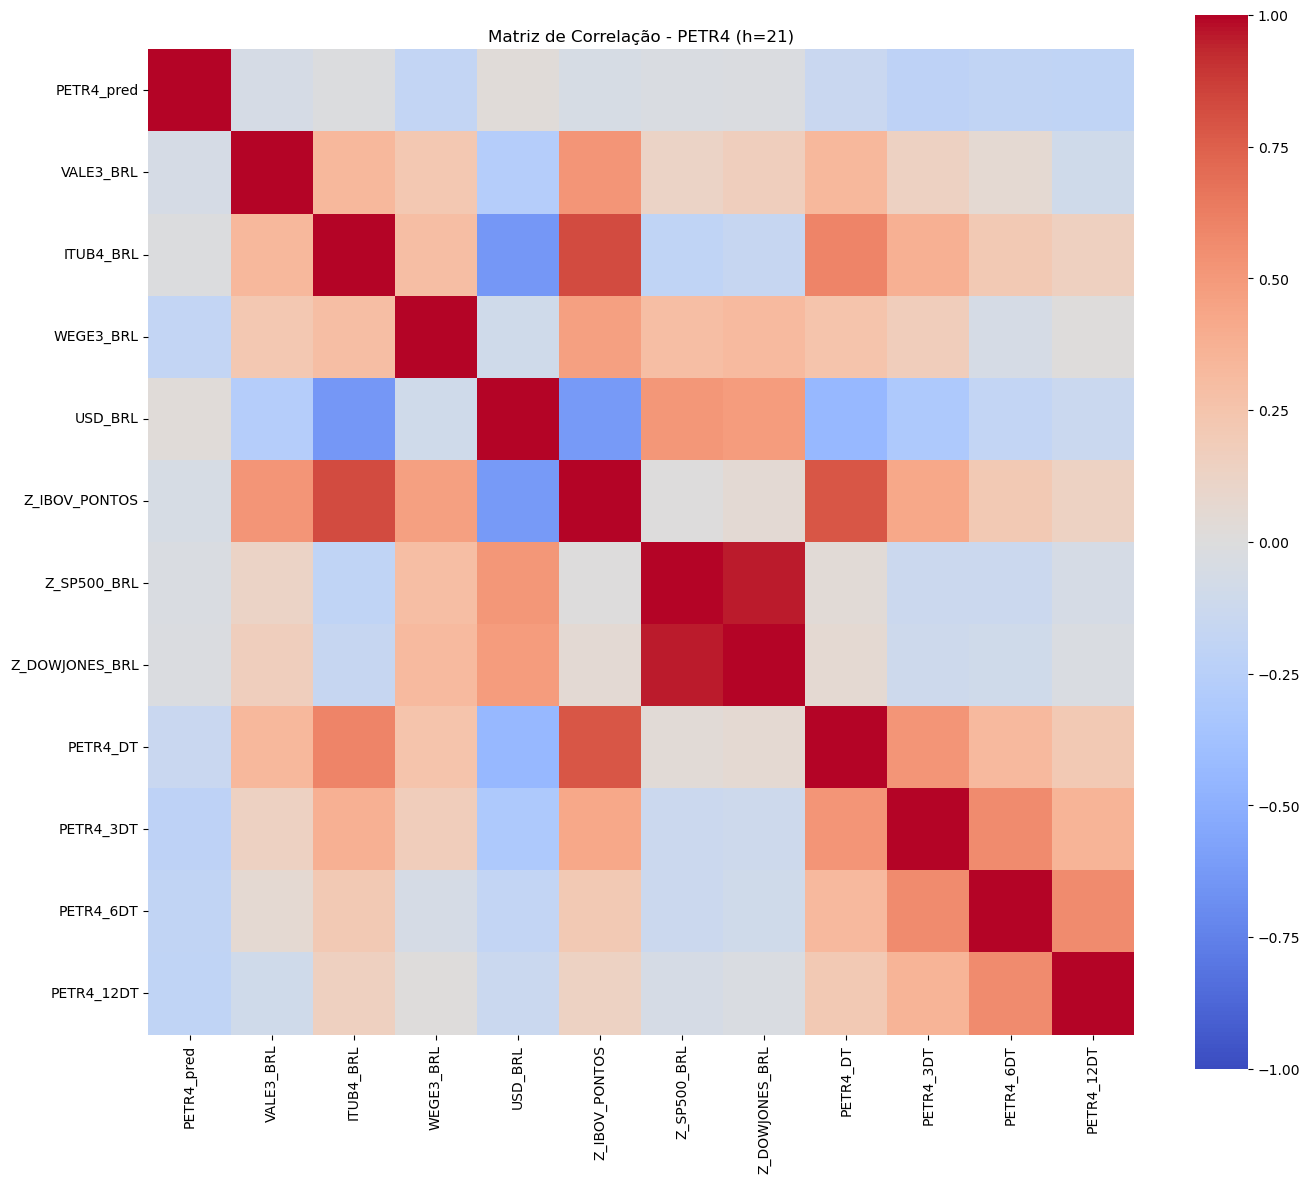

📷 Plot salvo: outputs/graficos/scatter_h21_20260227_200317.jpeg


<Figure size 1000x1000 with 0 Axes>

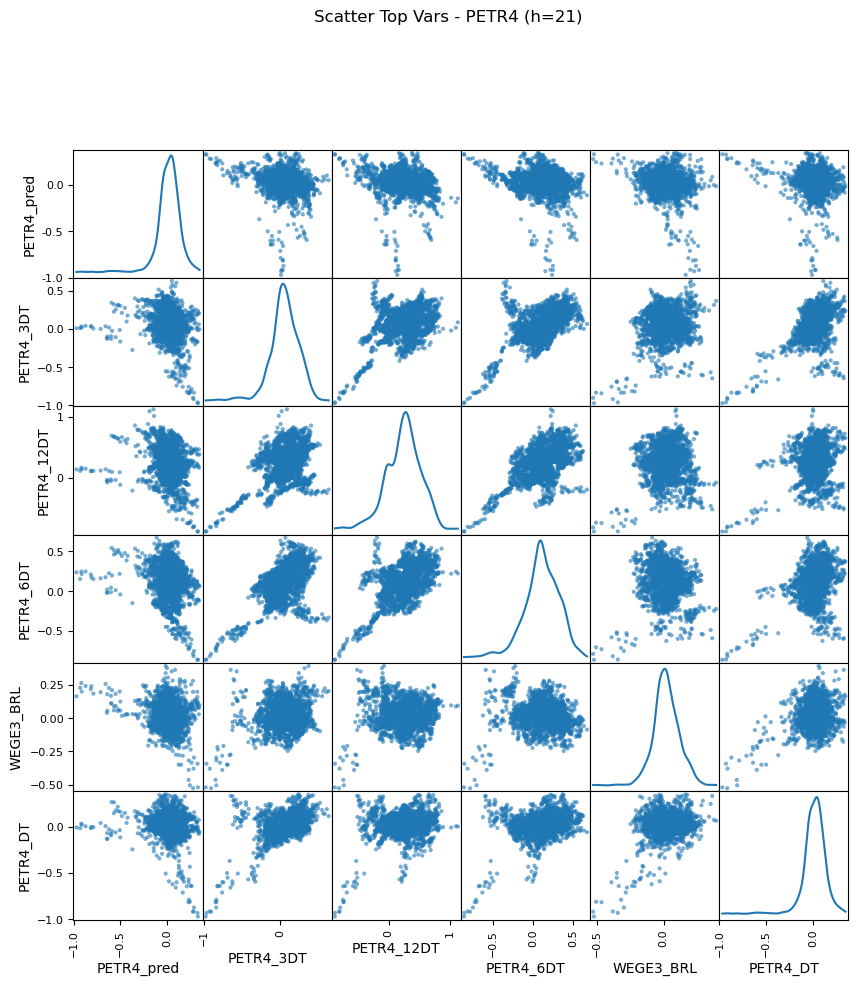

📷 Plot salvo: outputs/graficos/decompose_h21_20260227_200318.jpeg


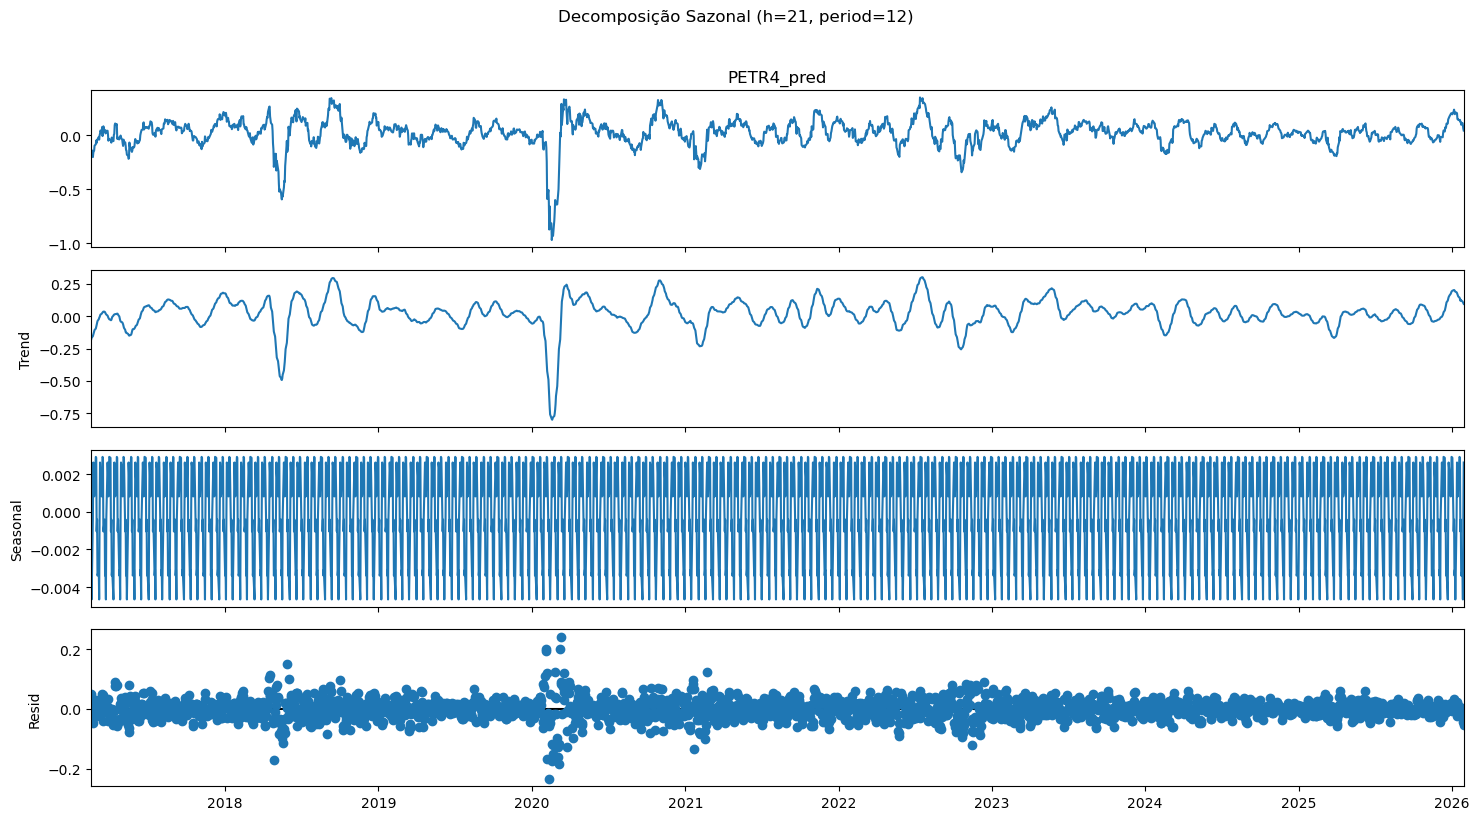

💾 CSV resultados salvo: outputs/resultados/results_h21_20260227_200340.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h21_20260227_200340.jpeg


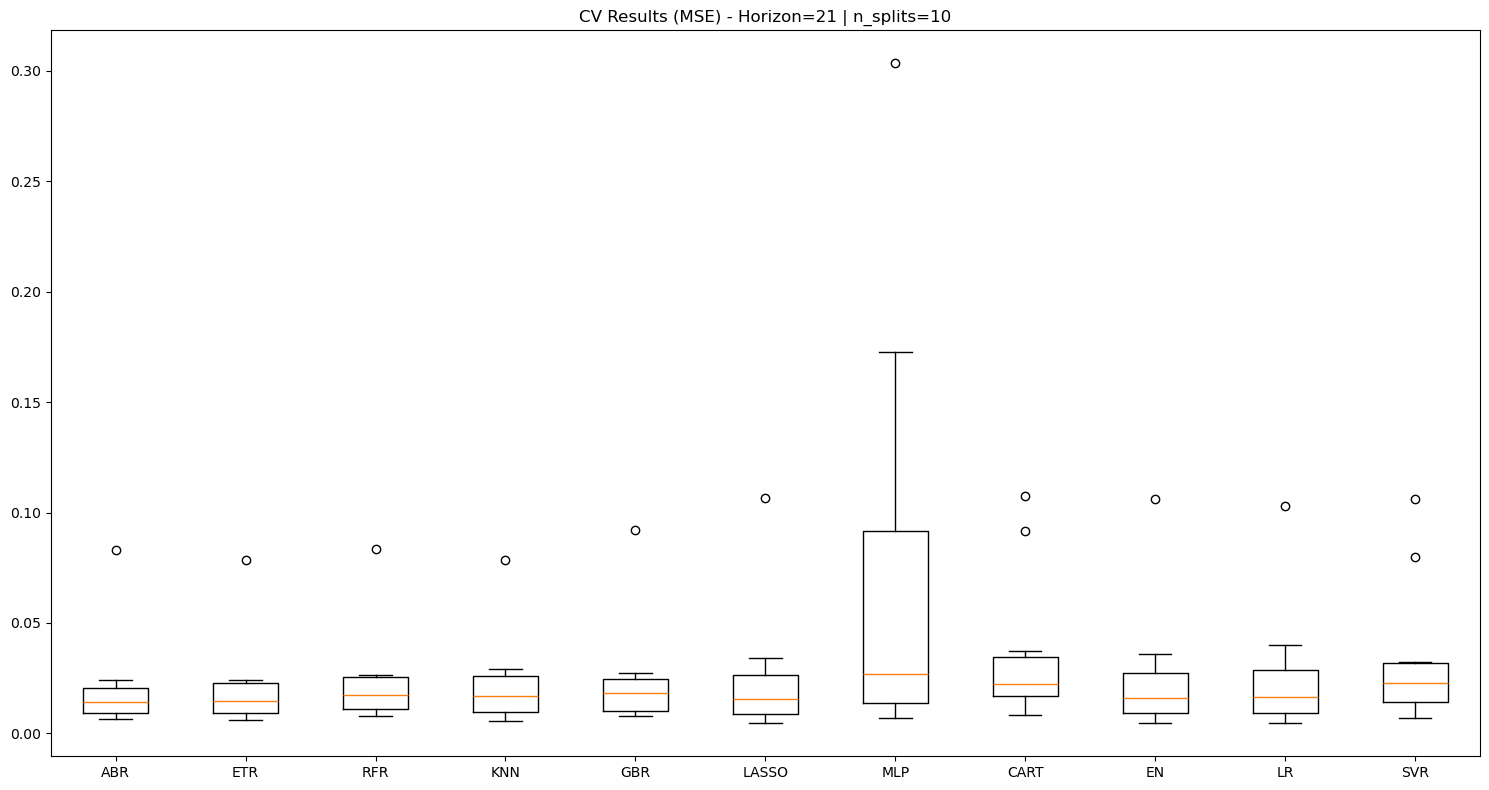

📷 Plot salvo: outputs/graficos/train_vs_test_h21_20260227_200340.jpeg


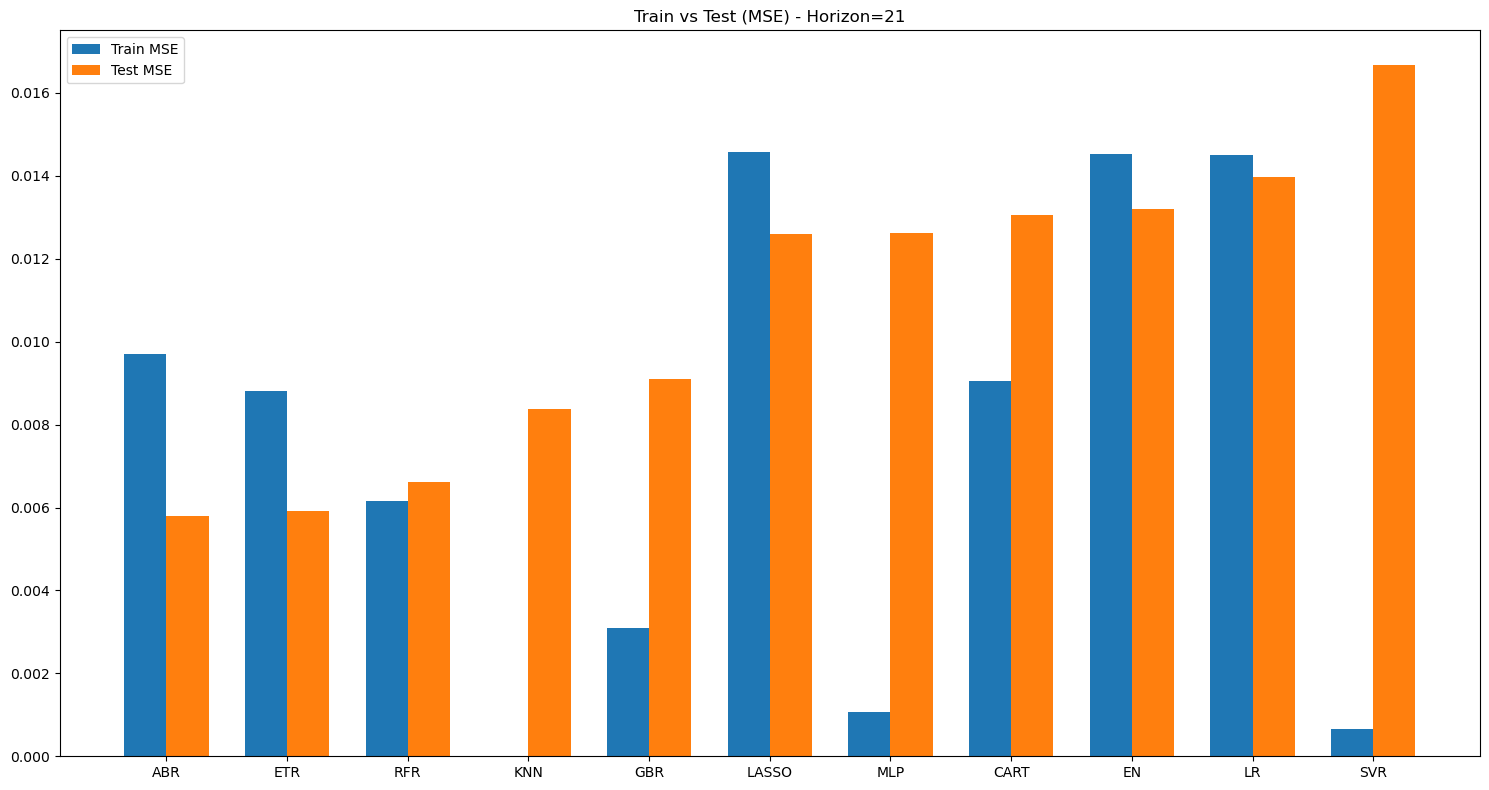


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
      21   ABR    0.020834   0.021466  0.009693 0.005791        10     1866     467
      21   ETR    0.020871   0.020252  0.008815 0.005920        10     1866     467
      21   RFR    0.023396   0.021250  0.006156 0.006618        10     1866     467
      21   KNN    0.022571   0.020232  0.000000 0.008373        10     1866     467
      21   GBR    0.024279   0.023644  0.003088 0.009089        10     1866     467
      21 LASSO    0.025493   0.028594  0.014582 0.012604        10     1866     467
      21   MLP    0.073672   0.091371  0.001063 0.012629        10     1866     467
      21  CART    0.036123   0.032883  0.009061 0.013063        10     1866     467
      21    EN    0.025918   0.028381  0.014539 0.013205        10     1866     467
      21    LR    0.026370   0.027648  0.014510 0.013961        10     1866     467
      21   SVR    0.033978   0.031332  0.00

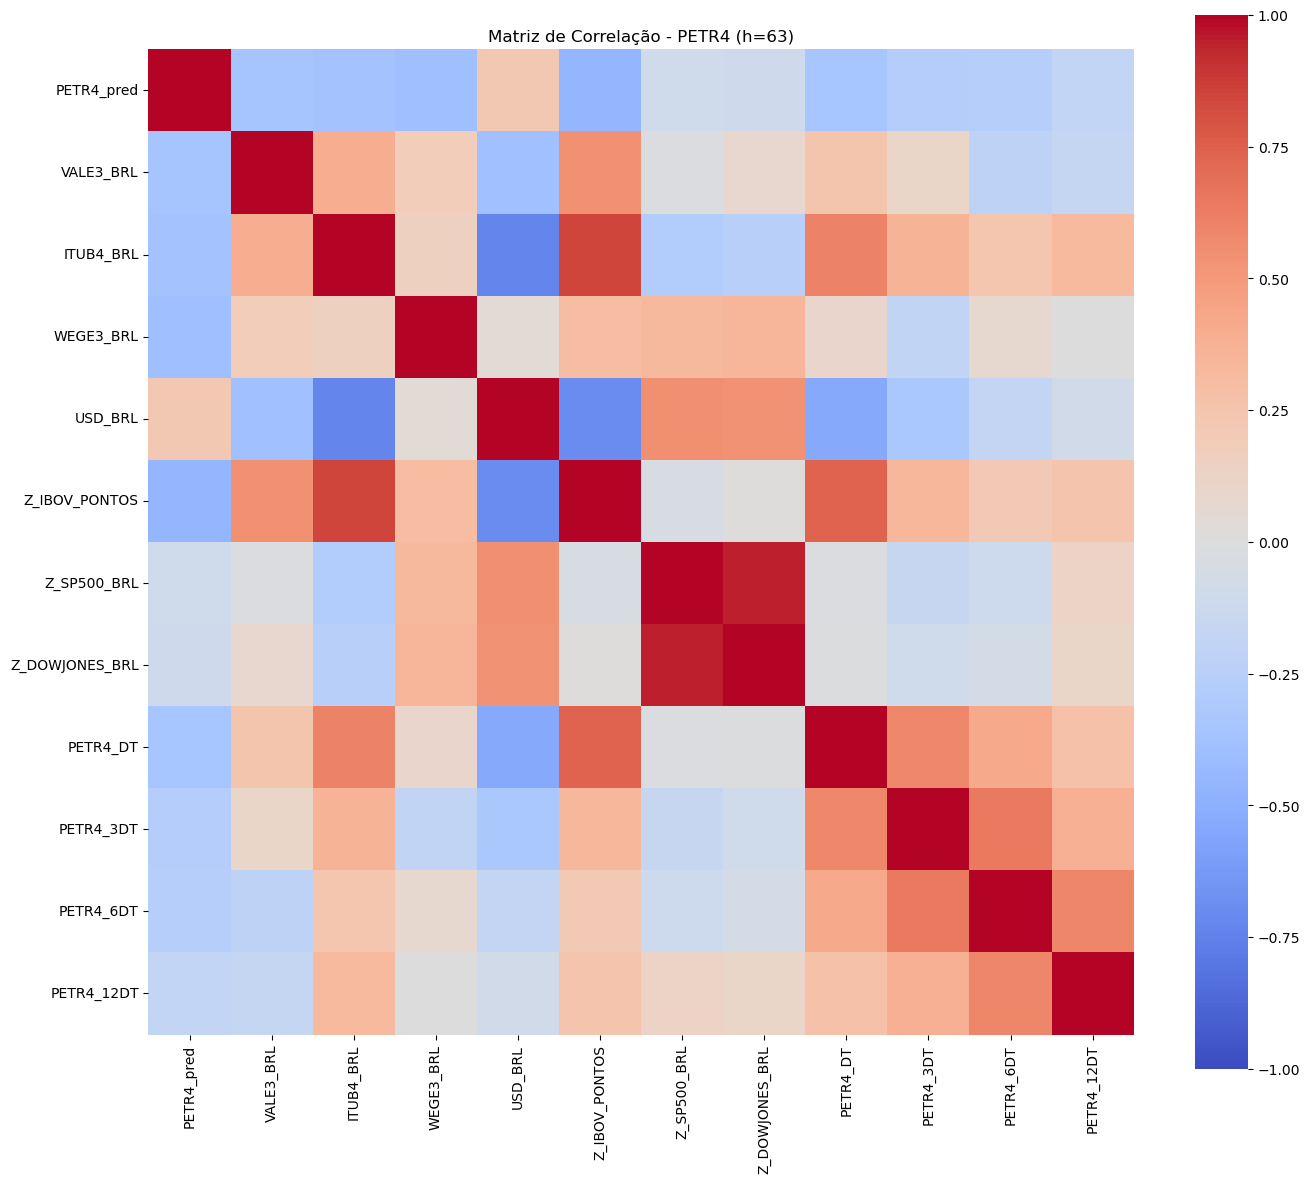

📷 Plot salvo: outputs/graficos/scatter_h63_20260227_200342.jpeg


<Figure size 1000x1000 with 0 Axes>

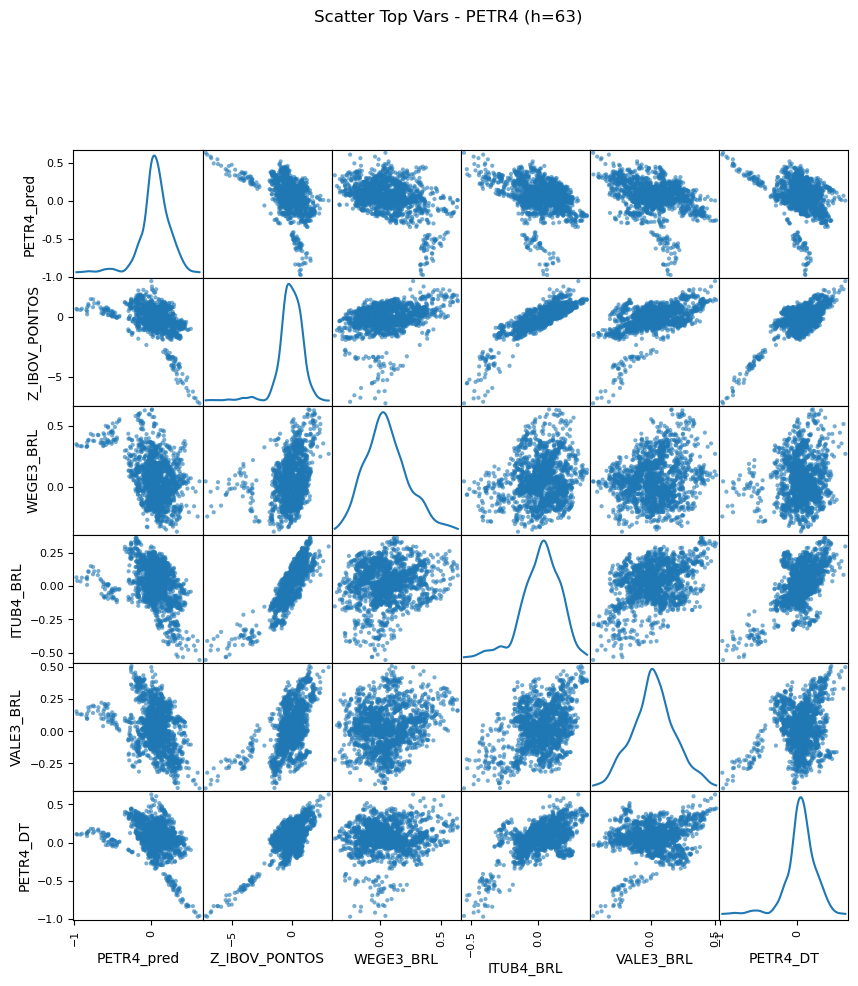

📷 Plot salvo: outputs/graficos/decompose_h63_20260227_200343.jpeg


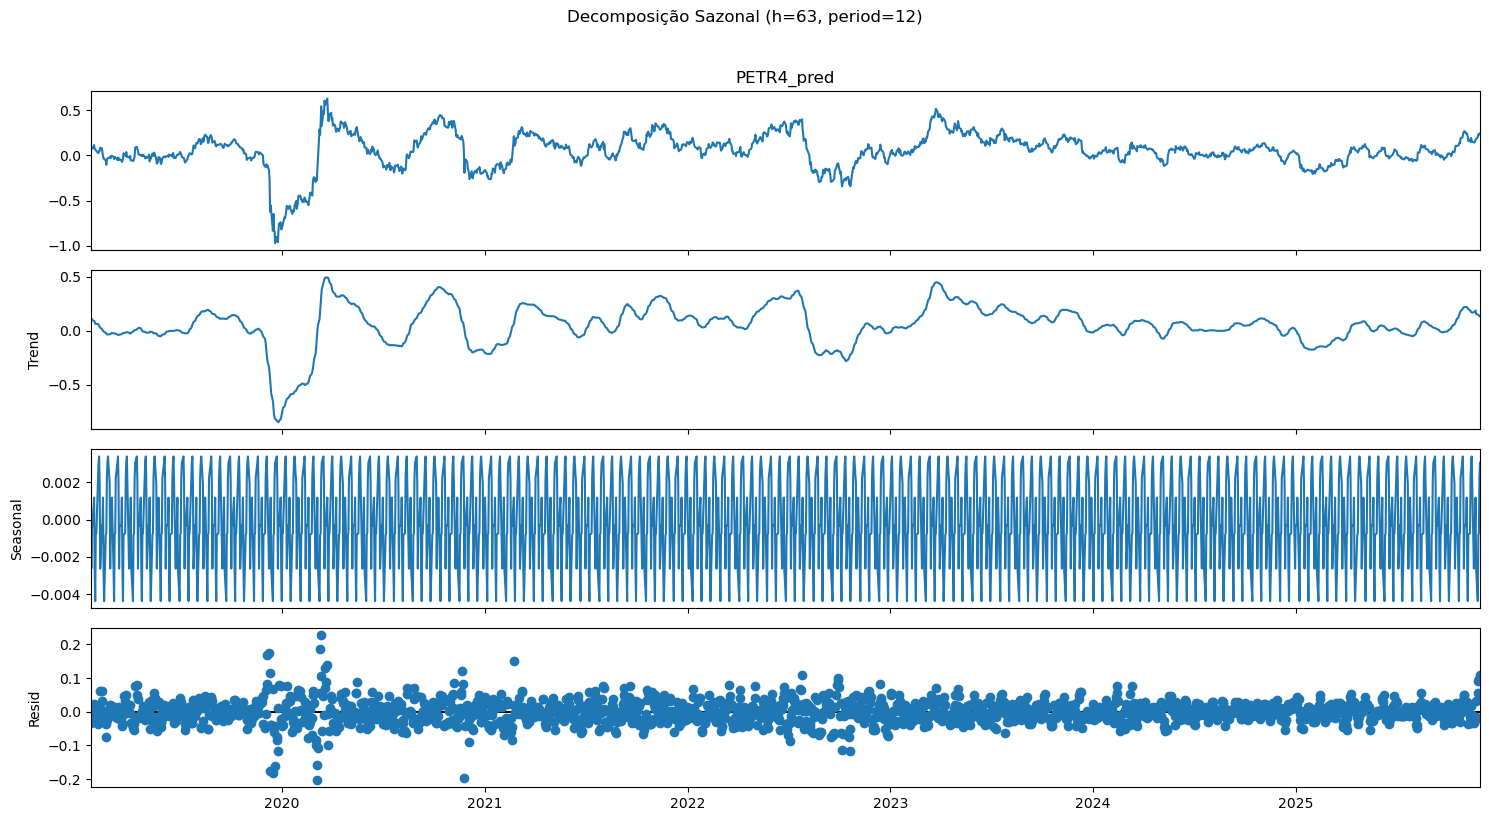

💾 CSV resultados salvo: outputs/resultados/results_h63_20260227_200401.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h63_20260227_200401.jpeg


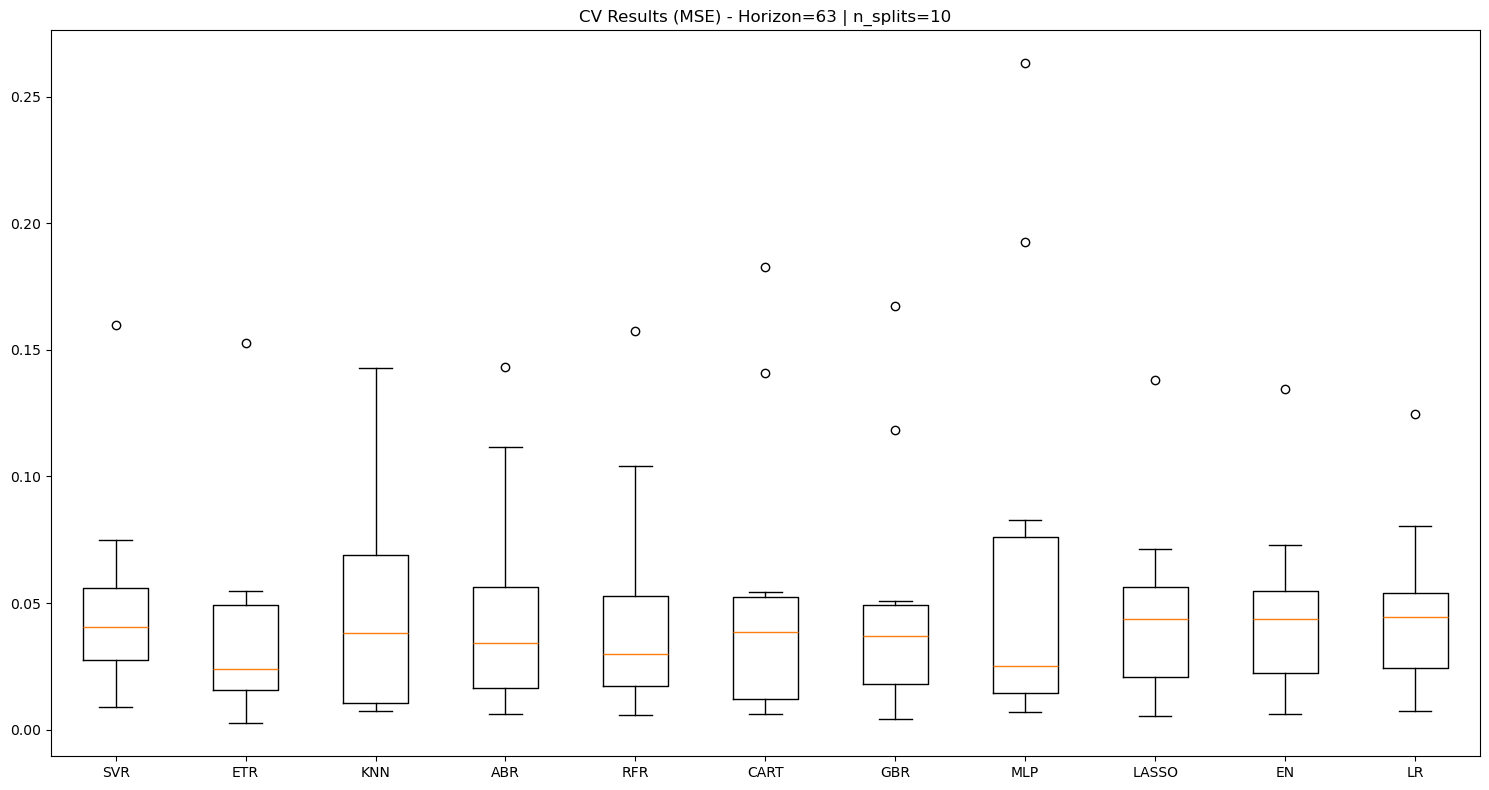

📷 Plot salvo: outputs/graficos/train_vs_test_h63_20260227_200402.jpeg


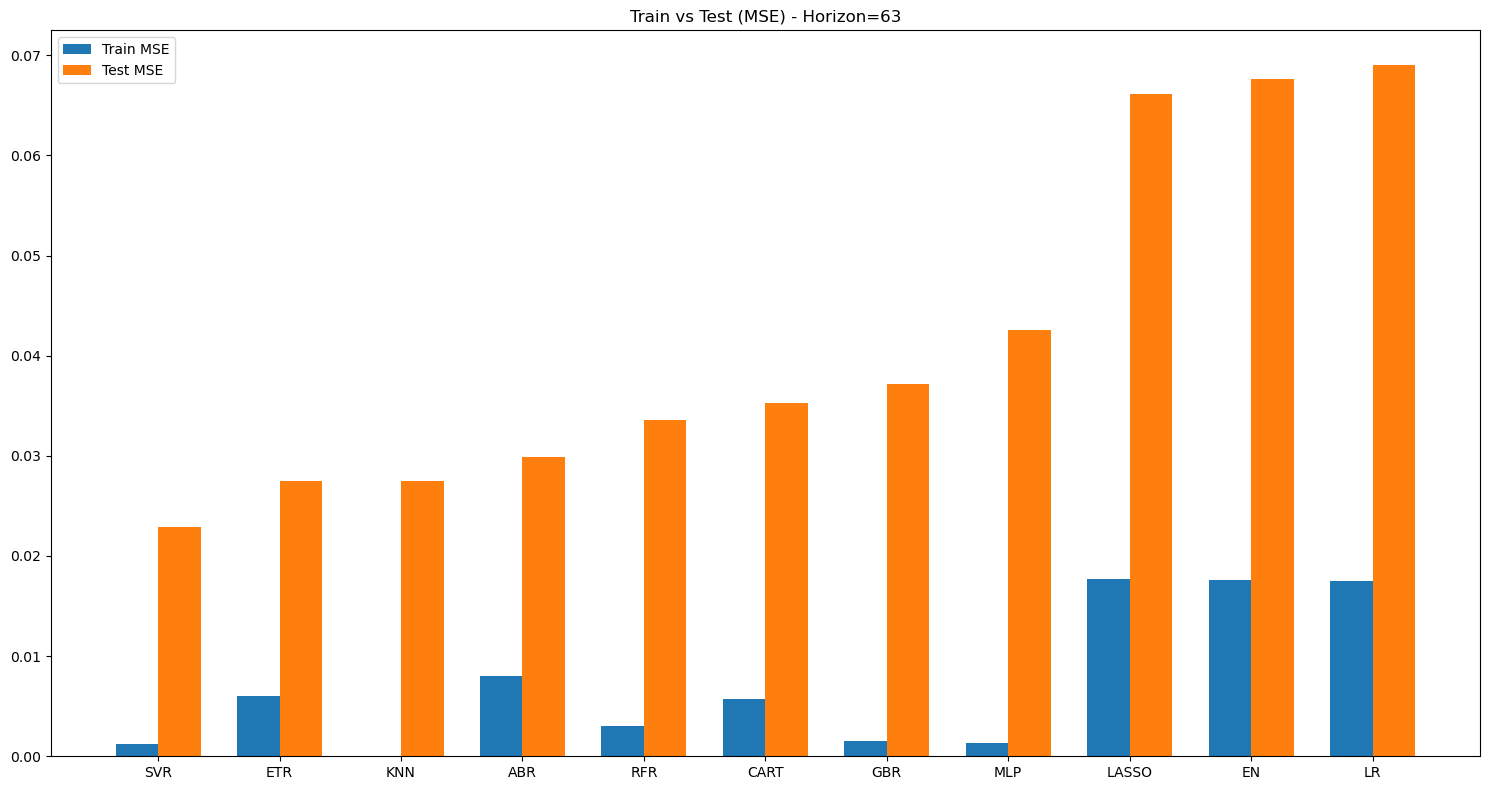


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
      63   SVR    0.050349   0.041317  0.001194 0.022886        10     1429     358
      63   ETR    0.039621   0.041471  0.005985 0.027440        10     1429     358
      63   KNN    0.047646   0.042130  0.000000 0.027494        10     1429     358
      63   ABR    0.048892   0.043112  0.007968 0.029883        10     1429     358
      63   RFR    0.046936   0.046125  0.003068 0.033538        10     1429     358
      63  CART    0.054142   0.057069  0.005691 0.035267        10     1429     358
      63   GBR    0.050332   0.049851  0.001532 0.037188        10     1429     358
      63   MLP    0.069557   0.083703  0.001338 0.042595        10     1429     358
      63 LASSO    0.047282   0.036664  0.017703 0.066108        10     1429     358
      63    EN    0.047063   0.035693  0.017600 0.067597        10     1429     358
      63    LR    0.047272   0.033545  0.01

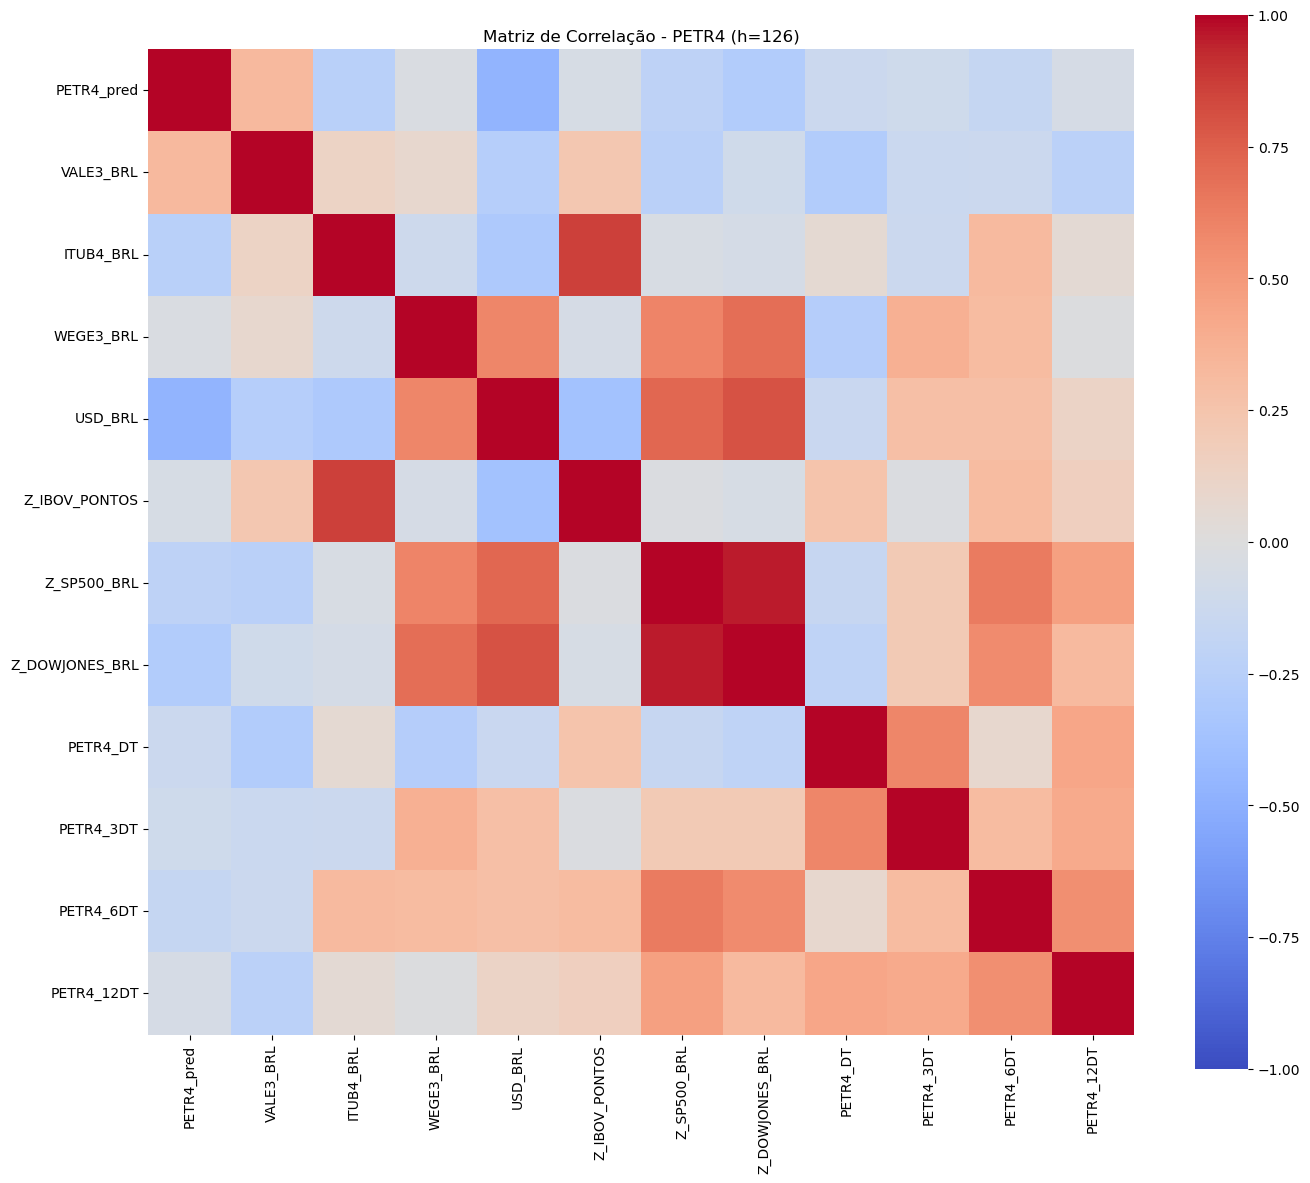

📷 Plot salvo: outputs/graficos/scatter_h126_20260227_200404.jpeg


<Figure size 1000x1000 with 0 Axes>

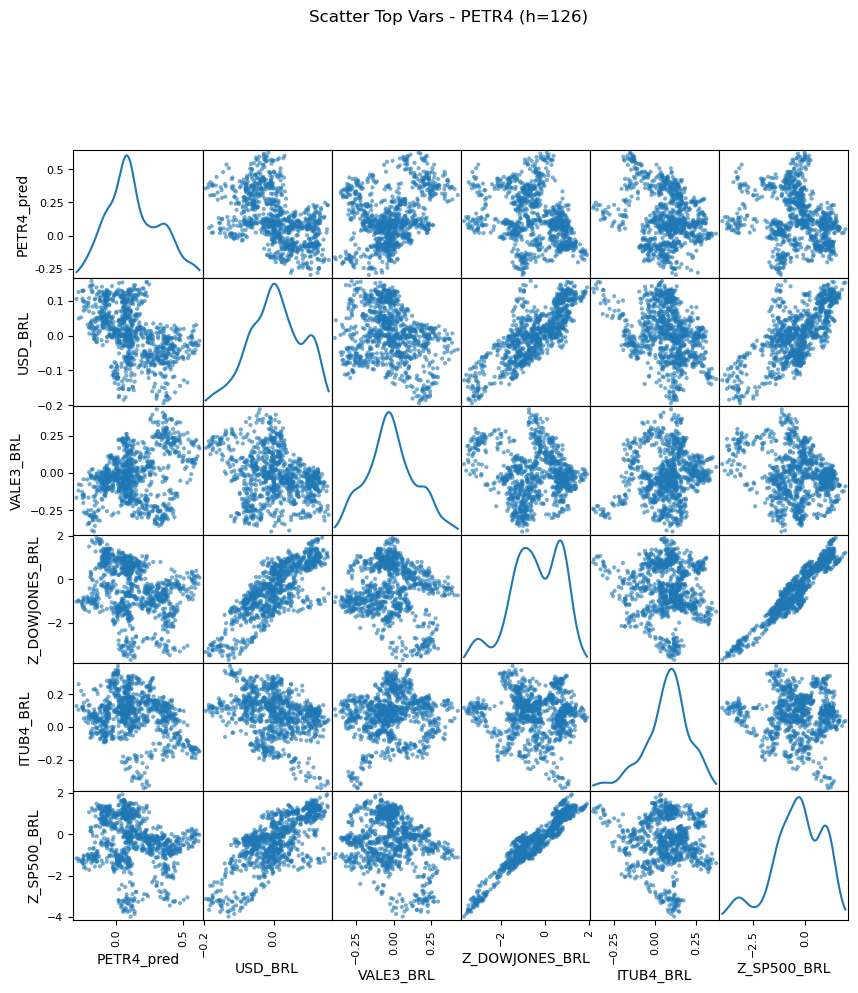

📷 Plot salvo: outputs/graficos/decompose_h126_20260227_200405.jpeg


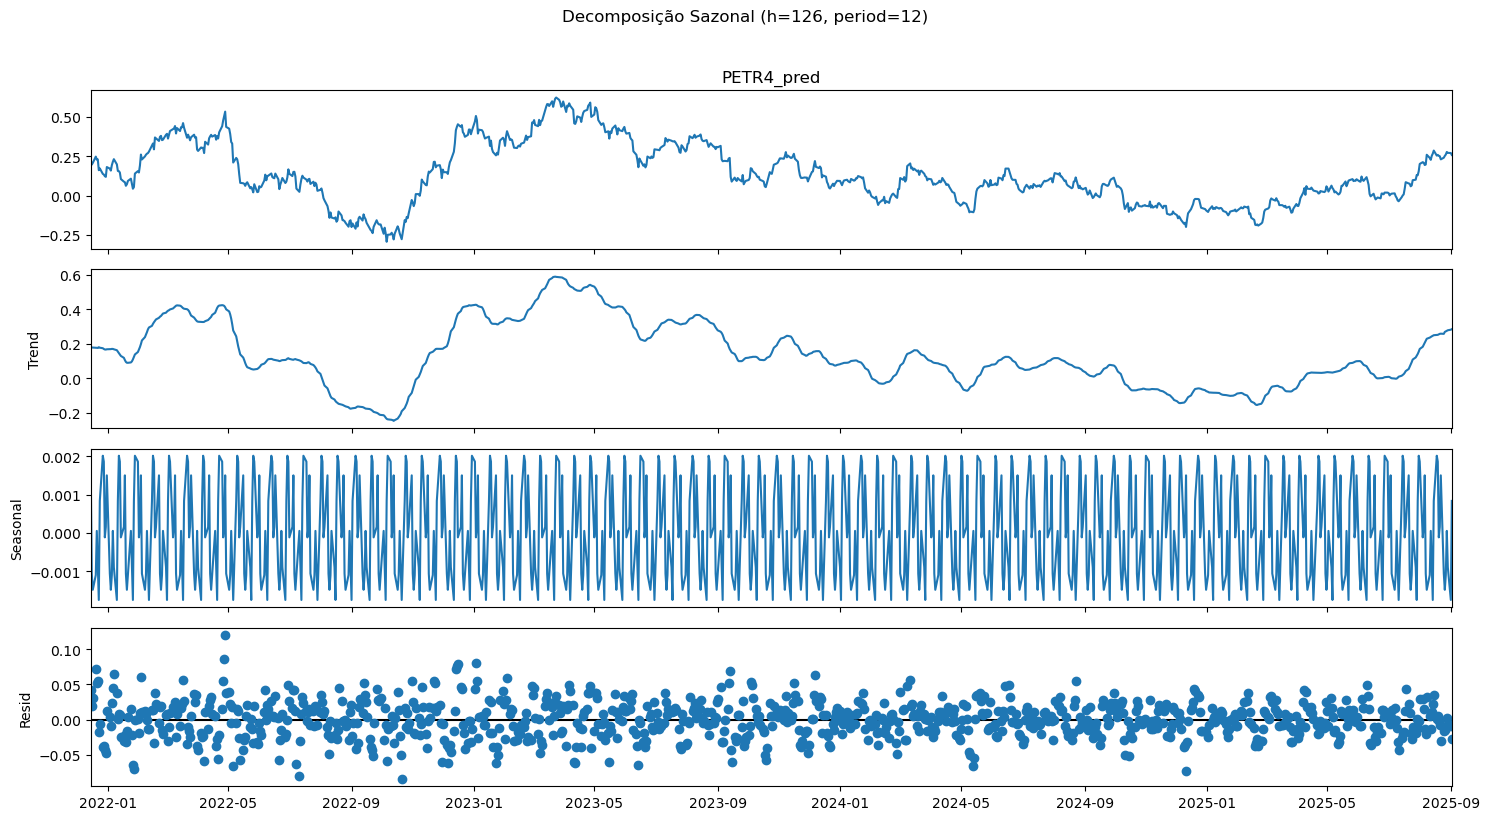

💾 CSV resultados salvo: outputs/resultados/results_h126_20260227_200418.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h126_20260227_200418.jpeg


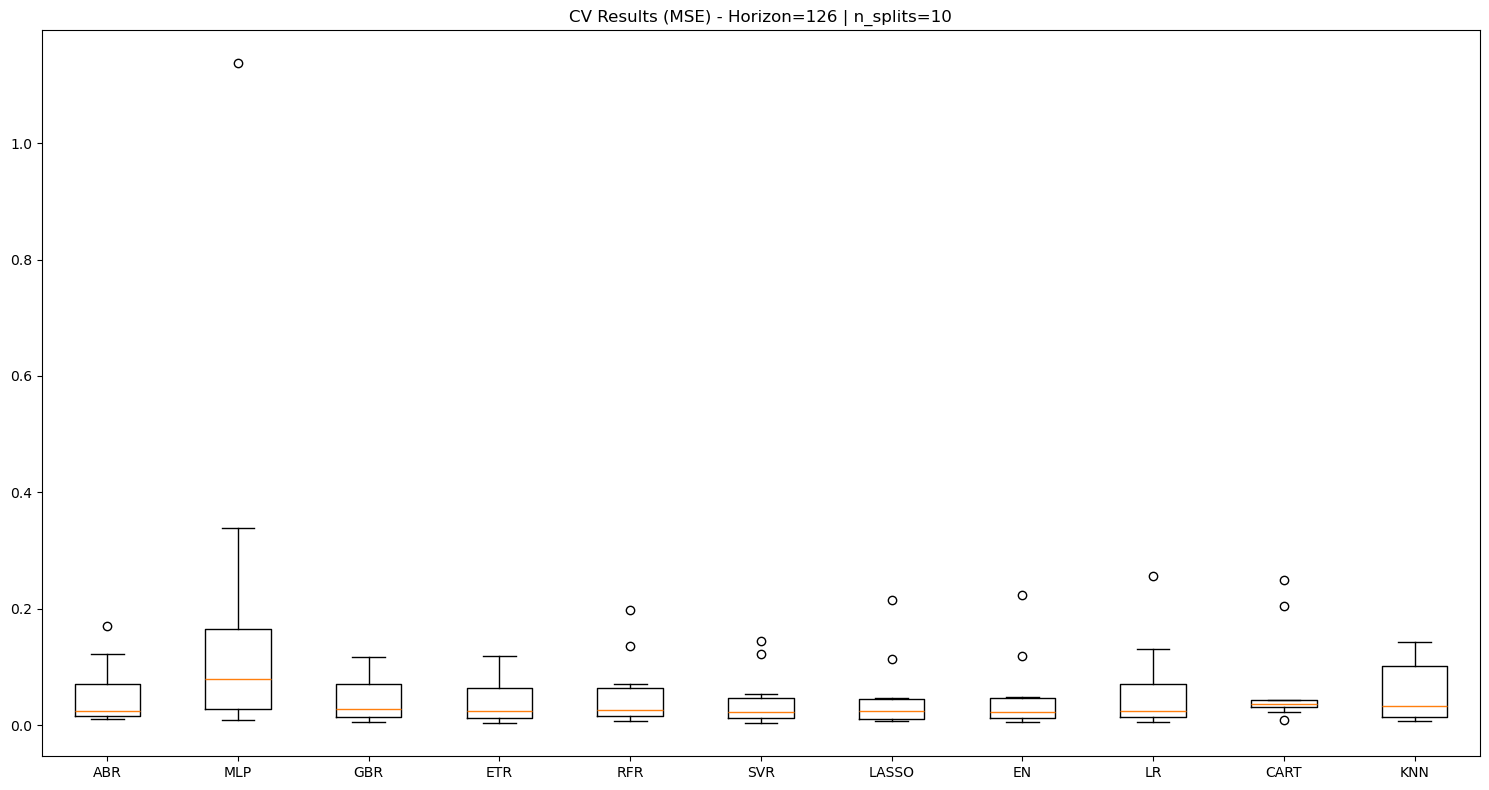

📷 Plot salvo: outputs/graficos/train_vs_test_h126_20260227_200419.jpeg


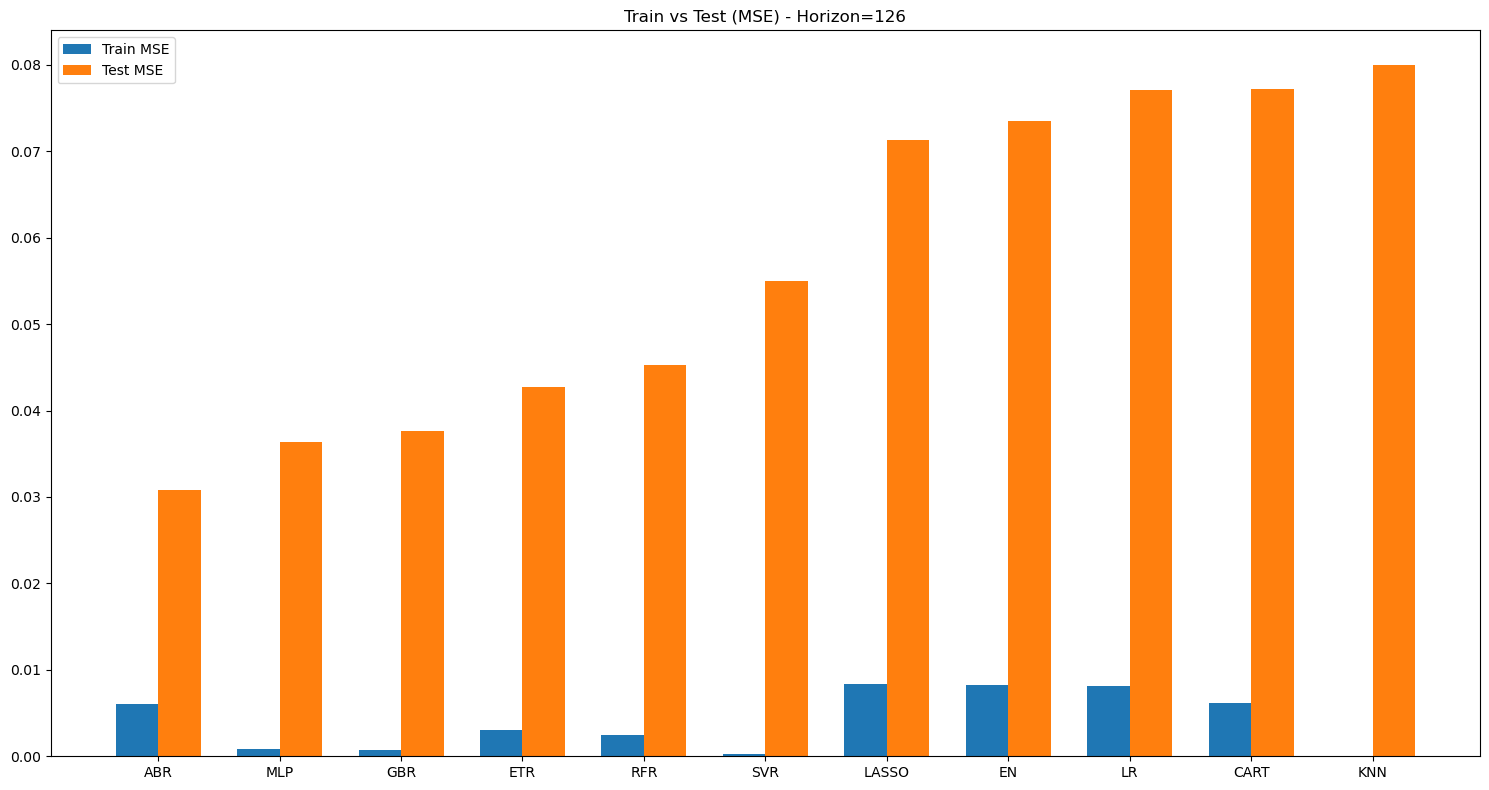


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
     126   ABR    0.052286   0.052026  0.006057 0.030803        10      774     194
     126   MLP    0.204740   0.325489  0.000844 0.036392        10      774     194
     126   GBR    0.044383   0.039457  0.000673 0.037673        10      774     194
     126   ETR    0.042400   0.040371  0.003016 0.042775        10      774     194
     126   RFR    0.054637   0.060255  0.002480 0.045259        10      774     194
     126   SVR    0.043333   0.046747  0.000214 0.055027        10      774     194
     126 LASSO    0.050090   0.062681  0.008327 0.071286        10      774     194
     126    EN    0.051880   0.065217  0.008207 0.073470        10      774     194
     126    LR    0.061138   0.075021  0.008143 0.077046        10      774     194
     126  CART    0.070678   0.079351  0.006107 0.077193        10      774     194
     126   KNN    0.055865   0.048750  0.00

In [110]:

if __name__ == "__main__":
    # Dica: se você tiver poucos dados, comece com (5, 21, 63)
    # CFG.horizons = (5, 21, 63)

    px, all_results, best = run(CFG)

In [112]:
# ============================================================
# SALVAR MELHOR MODELO EM PKL (BINÁRIO)
# ============================================================

import joblib


def salvar_melhor_modelo_pkl(
    X: pd.DataFrame,
    y: pd.Series,
    results: pd.DataFrame,
    horizon: int,
    cfg: Config,
    nome_base: str = "PETR4"
):
    """
    Treina o melhor modelo com todos os dados e salva em .pkl
    """

    if results.empty:
        print("⚠️ Nenhum resultado disponível.")
        return None

    # Melhor modelo
    best_model_name = results.iloc[0]["Model"]
    print(f"\n🏆 Melhor modelo para horizonte {horizon}: {best_model_name}")

    # buscar modelo na lista
    models = dict(get_models(cfg))
    if best_model_name not in models:
        raise ValueError("Modelo não encontrado.")

    best_model = models[best_model_name]

    # pipeline com scaler (evita problemas futuros)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_model)
    ])

    # treinar com todos os dados disponíveis
    pipeline.fit(X, y)

    # salvar binário
    filename = f"{nome_base}_best_model_h{horizon}.pkl"
    path = os.path.join(cfg.results_dir, filename)

    joblib.dump(pipeline, path)

    print("💾 Modelo salvo:", path)
    return path

In [113]:
# ============================================================
# CARREGAR MODELO E PREVER PETR4
# ============================================================

def carregar_modelo_pkl(path: str):
    return joblib.load(path)


def prever_petr4(model, X_novo: pd.DataFrame):
    """
    Retorna previsão de retorno futuro da PETR4
    """
    return model.predict(X_novo)

💾 CSV preços salvo: outputs/resultados/prices_market_brl_2016-02-27_2026-02-27.csv
Ticker      ITUB4_BRL  PETR4_BRL  USD_BRL  VALE3_BRL  WEGE3_BRL  IBOV_PONTOS  \
Date                                                                           
2016-02-29   7.673161   1.369432   3.9647   5.839019   4.169322      42794.0   
2016-03-01   8.034375   1.414724   4.0129   6.333432   4.188289      44122.0   
2016-03-02   8.221785   1.505310   3.9220   7.030553   4.314728      44893.0   
2016-03-03   9.034888   1.750422   3.8893   7.722733   4.283118      47193.0   
2016-03-04   9.476207   1.923599   3.7961   8.182536   4.340017      49085.0   

Ticker        SP500_BRL  DOWJONES_BRL  
Date                                   
2016-02-29  7660.712172  65482.967279  
2016-03-01  7938.920371  67677.877748  
2016-03-02  7790.856572  66279.133105  
2016-03-03  7752.930930  65899.913618  
2016-03-04  7592.161804  64559.396137  

🚀 HORIZONTE: 5 dias
Índices incluídos: ['IBOV_PONTOS', 'SP500_BRL', 'DOWJON

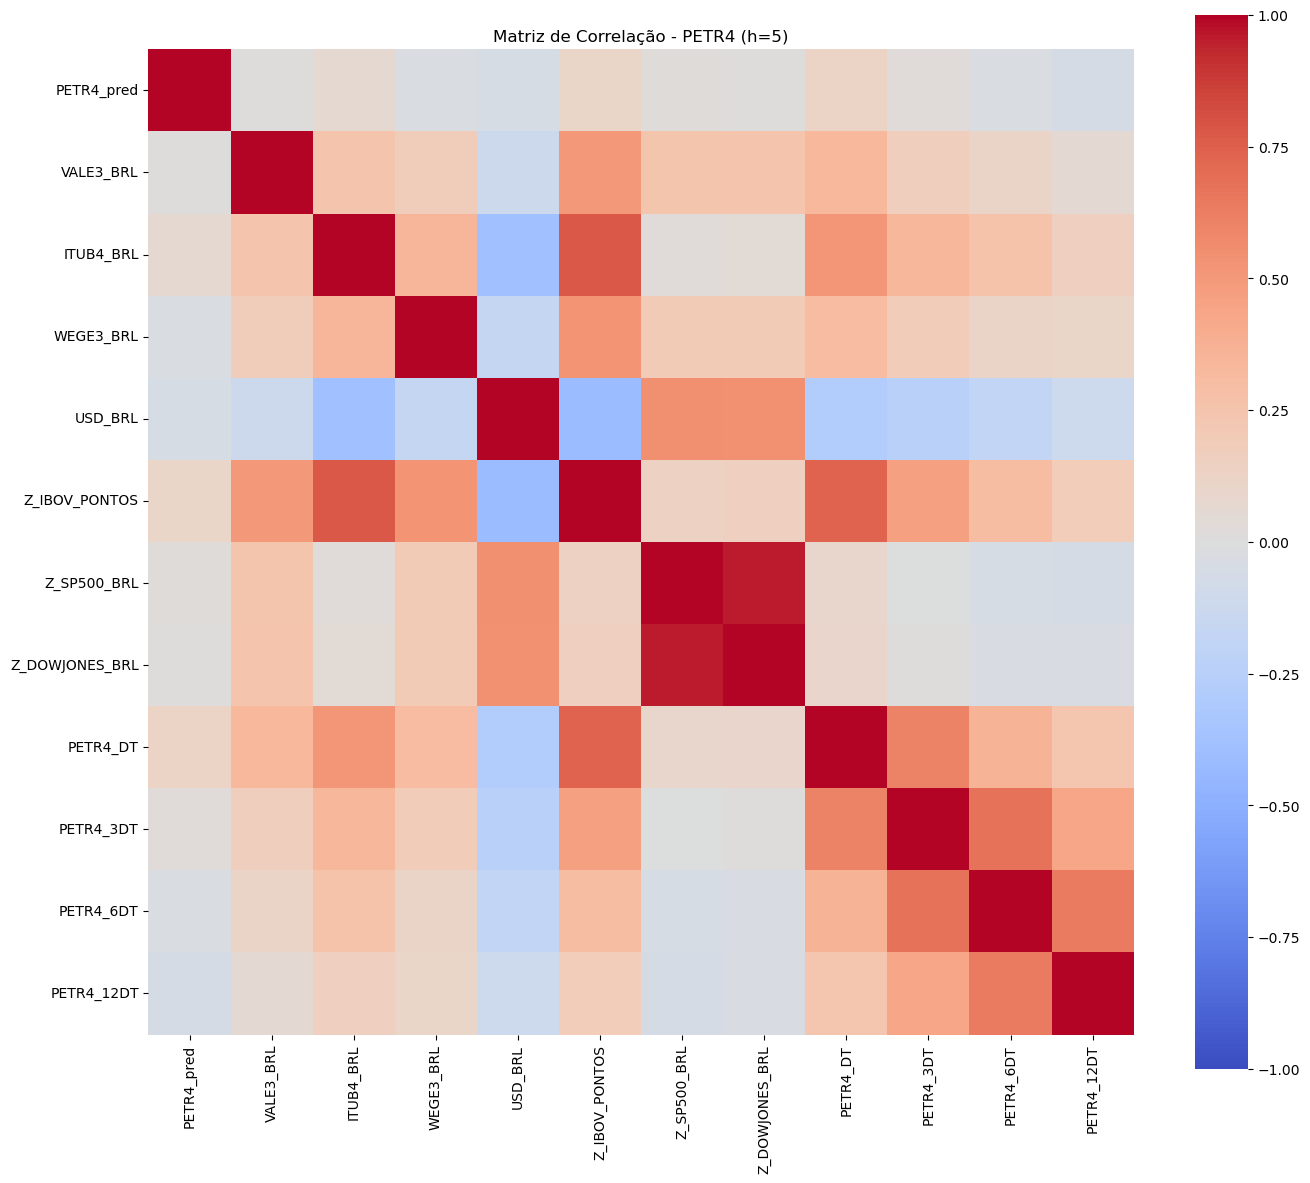

📷 Plot salvo: outputs/graficos/scatter_h5_20260227_200456.jpeg


<Figure size 1000x1000 with 0 Axes>

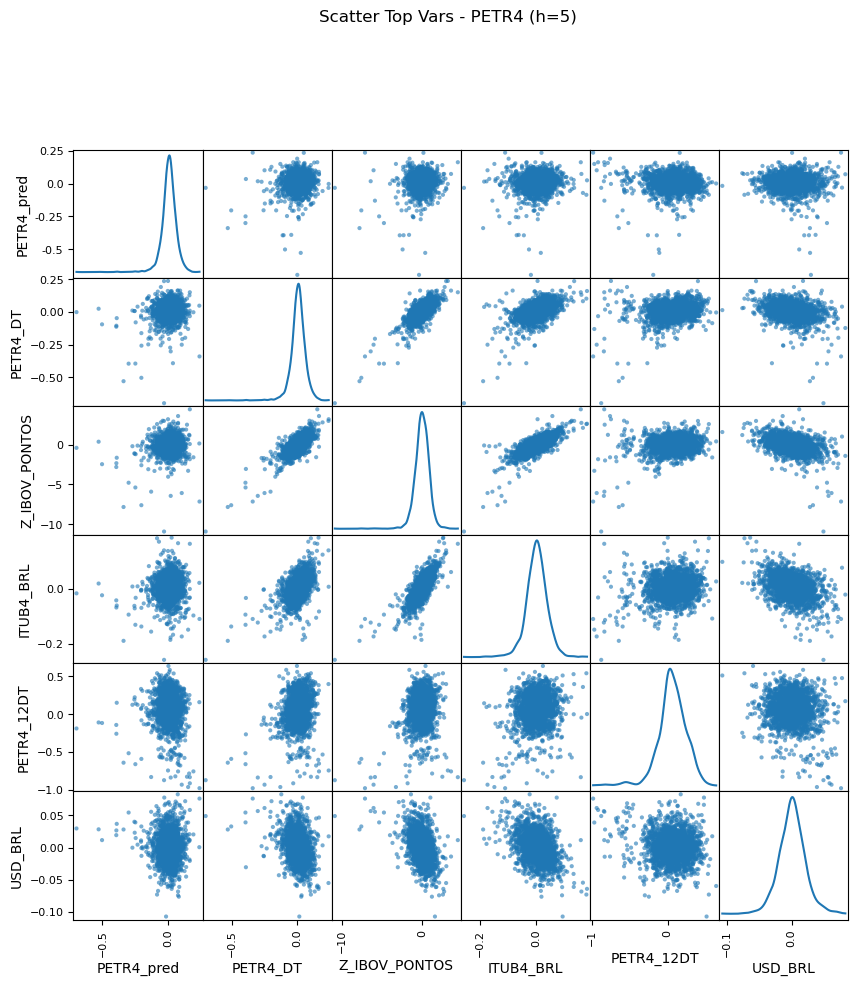

📷 Plot salvo: outputs/graficos/decompose_h5_20260227_200457.jpeg


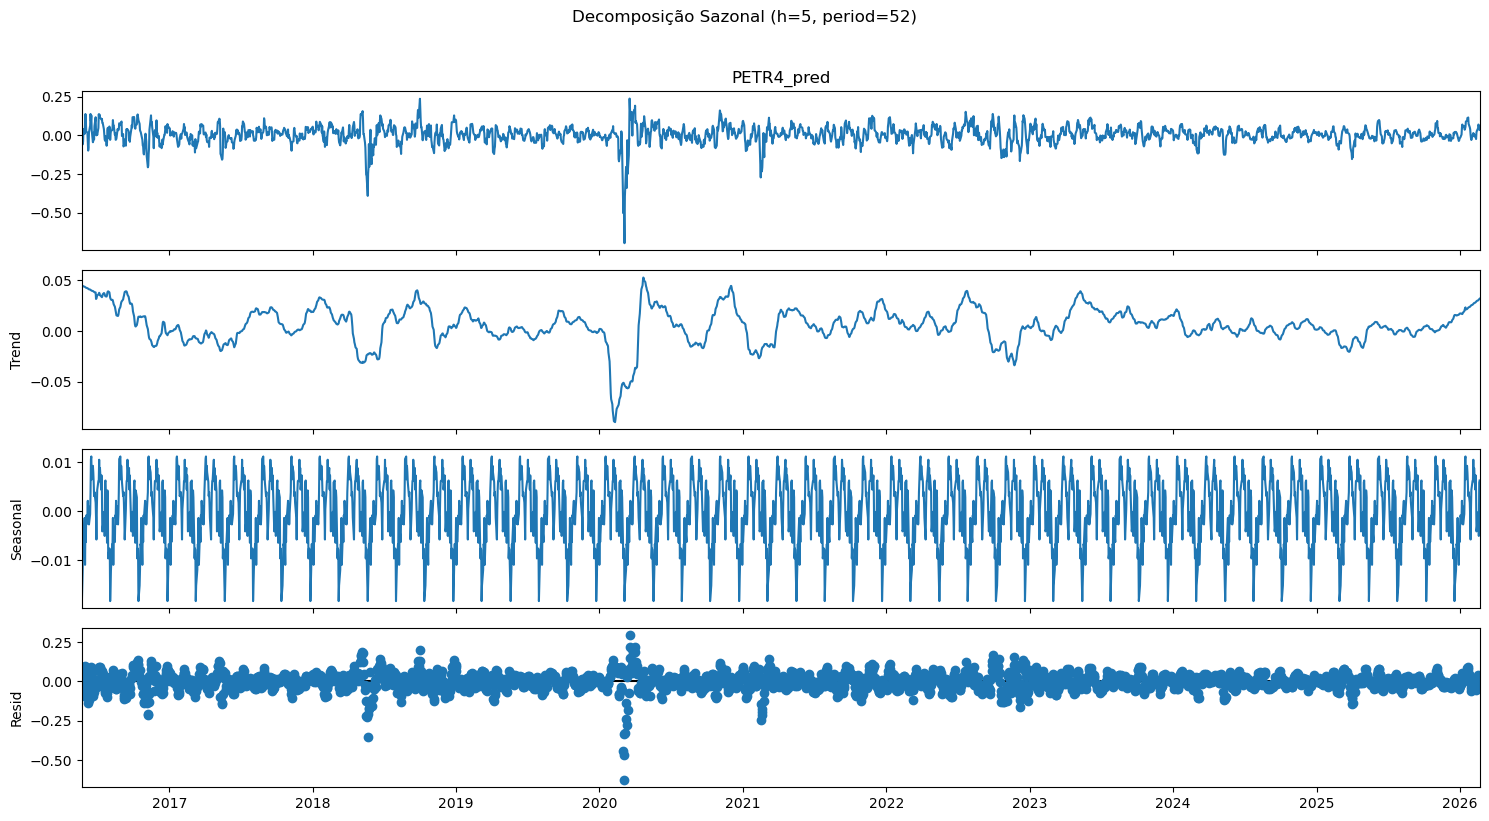

💾 CSV resultados salvo: outputs/resultados/results_h5_20260227_200519.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h5_20260227_200519.jpeg


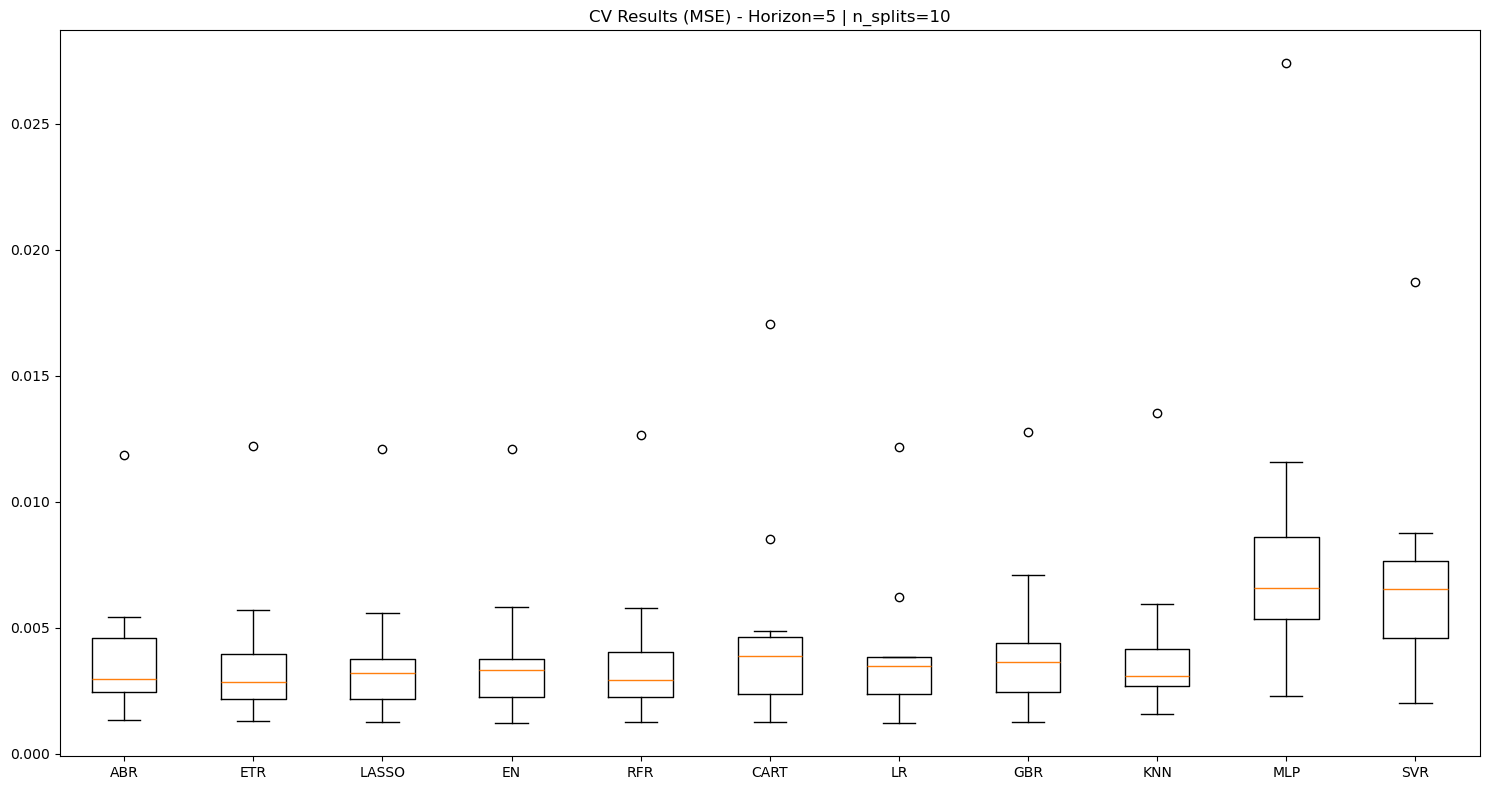

📷 Plot salvo: outputs/graficos/train_vs_test_h5_20260227_200519.jpeg


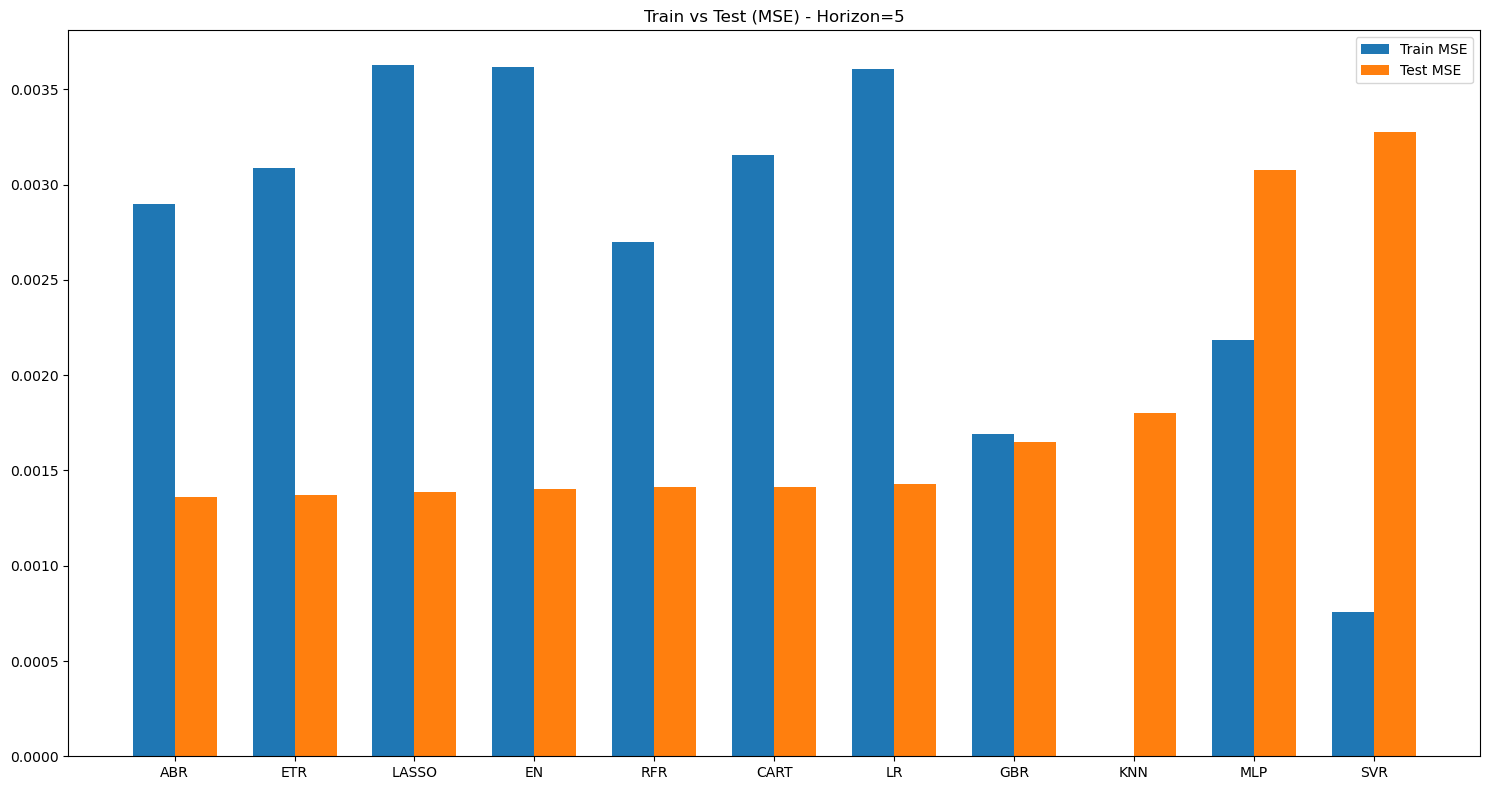


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
       5   ABR    0.004014   0.002872  0.002897 0.001359        10     2032     509
       5   ETR    0.003867   0.003052  0.003090 0.001369        10     2032     509
       5 LASSO    0.003877   0.003000  0.003629 0.001386        10     2032     509
       5    EN    0.003933   0.003000  0.003618 0.001403        10     2032     509
       5   RFR    0.003964   0.003164  0.002698 0.001411        10     2032     509
       5  CART    0.004981   0.004486  0.003156 0.001413        10     2032     509
       5    LR    0.004048   0.003032  0.003606 0.001428        10     2032     509
       5   GBR    0.004433   0.003189  0.001692 0.001652        10     2032     509
       5   KNN    0.004271   0.003304  0.000000 0.001803        10     2032     509
       5   MLP    0.008618   0.006714  0.002187 0.003078        10     2032     509
       5   SVR    0.007154   0.004296  0.00

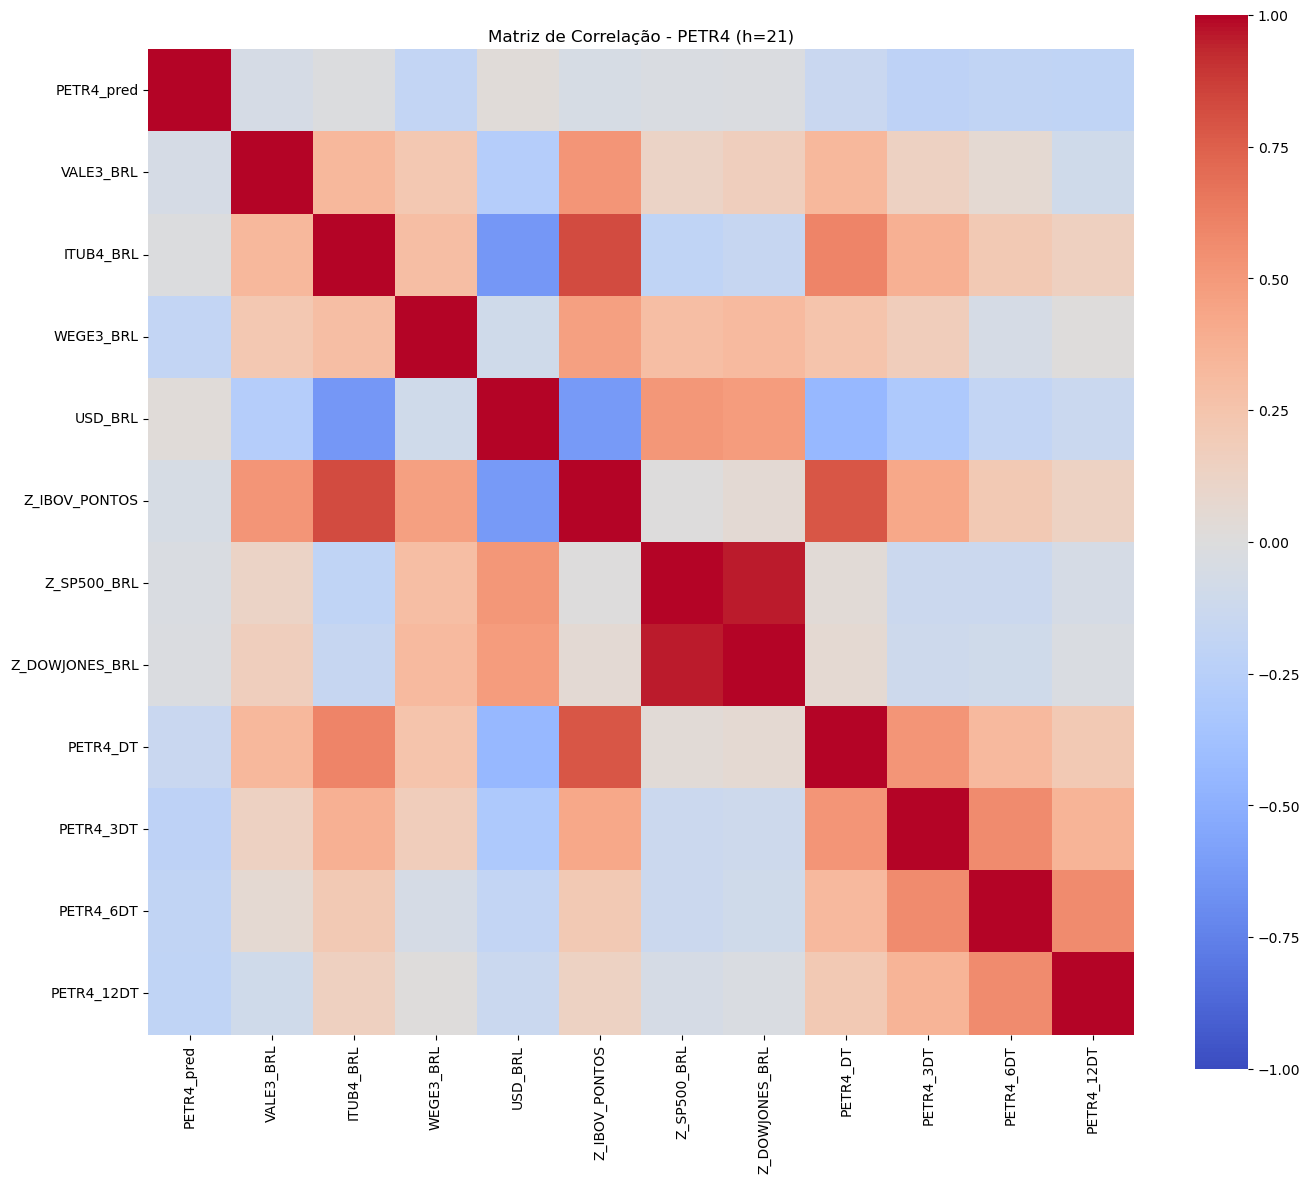

📷 Plot salvo: outputs/graficos/scatter_h21_20260227_200521.jpeg


<Figure size 1000x1000 with 0 Axes>

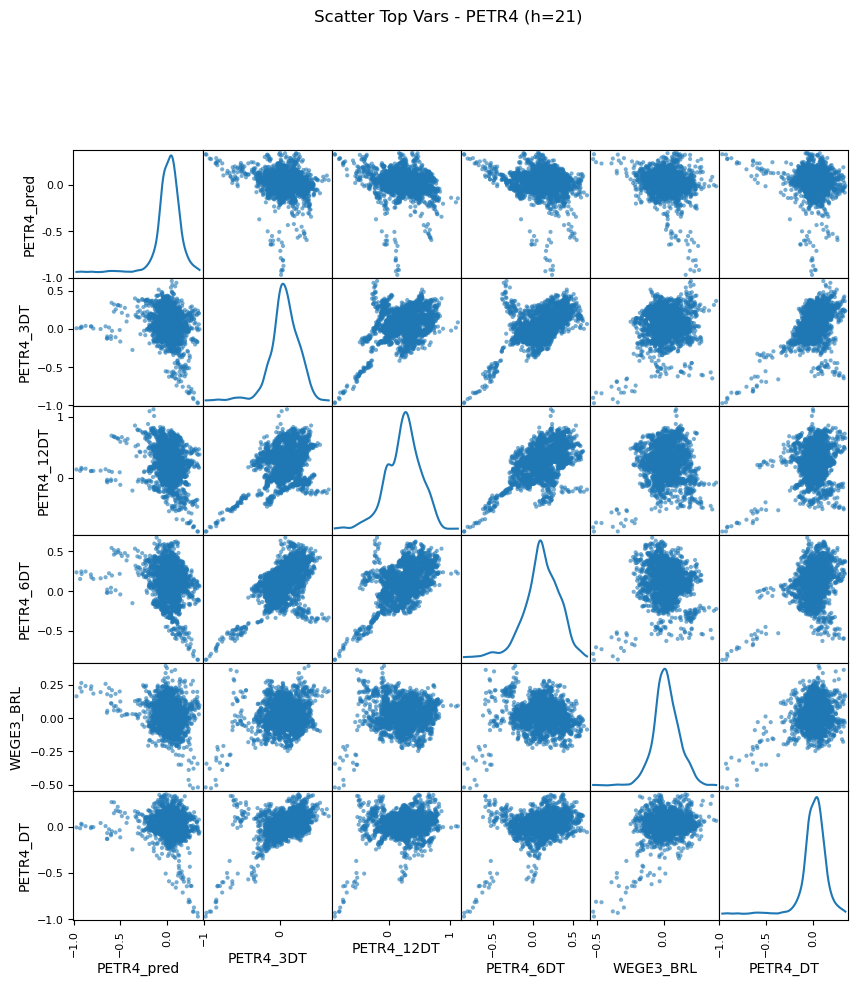

📷 Plot salvo: outputs/graficos/decompose_h21_20260227_200522.jpeg


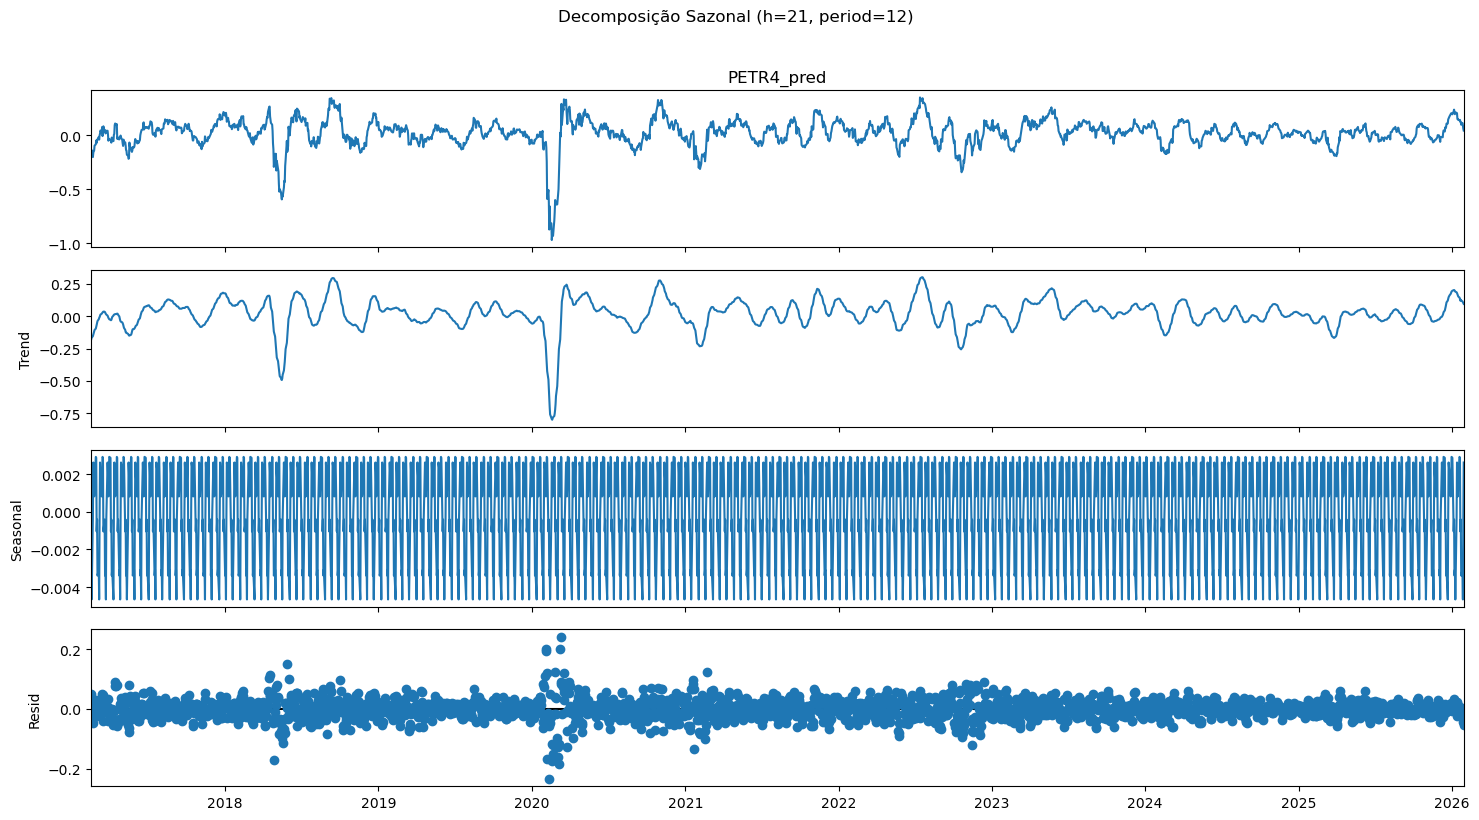

💾 CSV resultados salvo: outputs/resultados/results_h21_20260227_200543.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h21_20260227_200543.jpeg


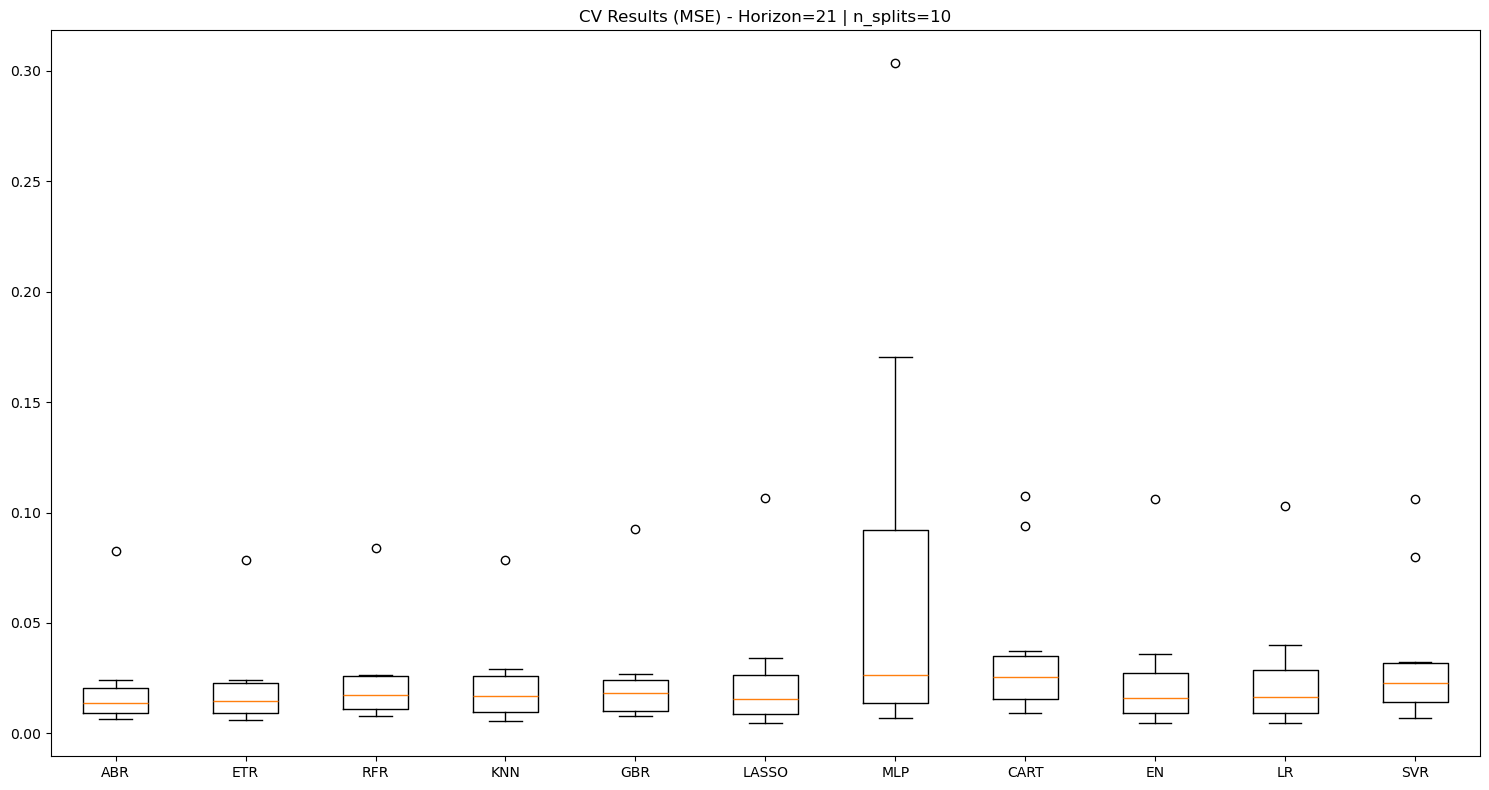

📷 Plot salvo: outputs/graficos/train_vs_test_h21_20260227_200544.jpeg


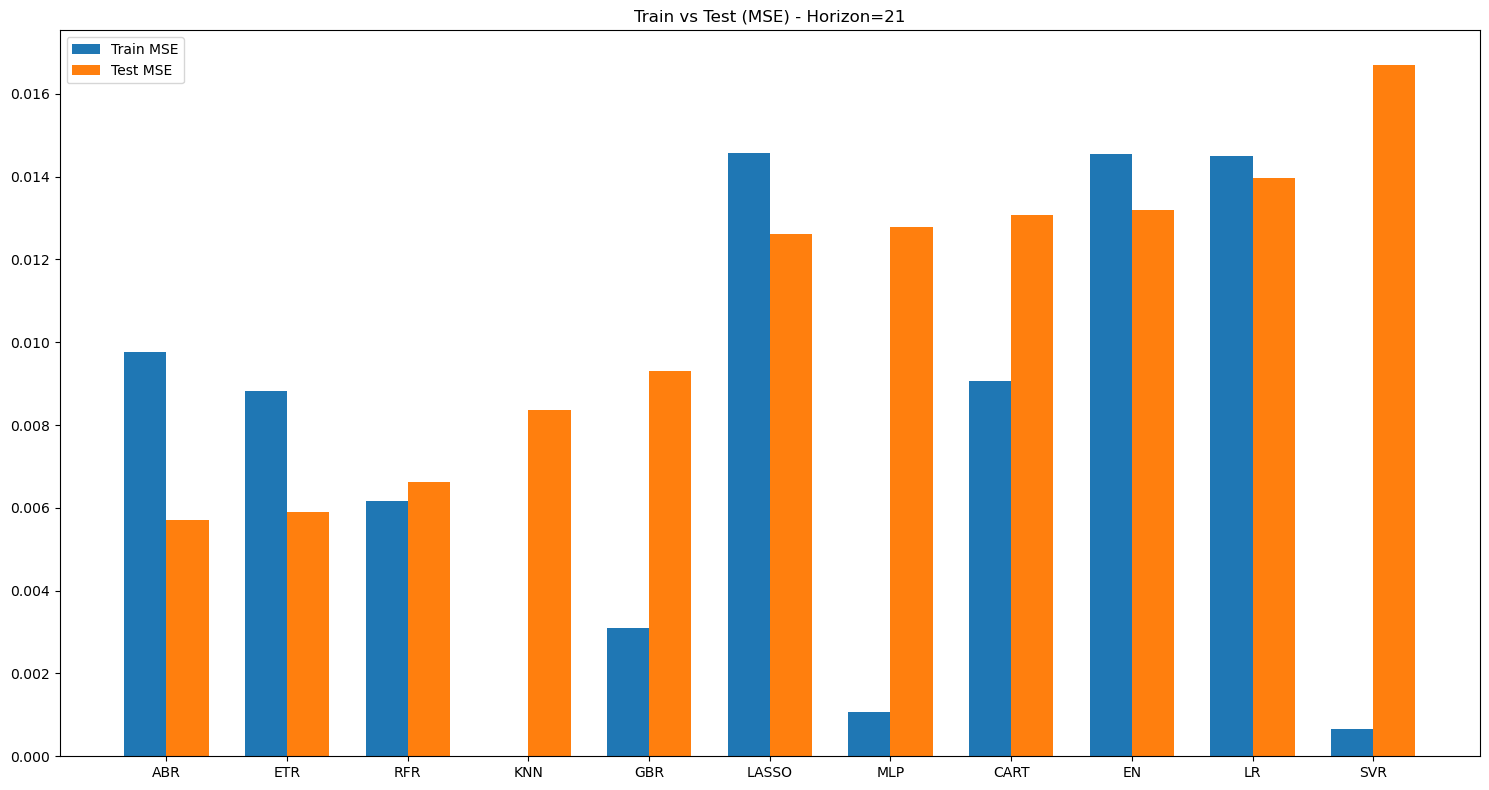


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
      21   ABR    0.020807   0.021392  0.009766 0.005715        10     1866     467
      21   ETR    0.020841   0.020250  0.008813 0.005909        10     1866     467
      21   RFR    0.023534   0.021282  0.006154 0.006628        10     1866     467
      21   KNN    0.022571   0.020232  0.000000 0.008373        10     1866     467
      21   GBR    0.024194   0.023732  0.003088 0.009303        10     1866     467
      21 LASSO    0.025493   0.028594  0.014582 0.012604        10     1866     467
      21   MLP    0.073336   0.091190  0.001058 0.012791        10     1866     467
      21  CART    0.037063   0.033002  0.009061 0.013063        10     1866     467
      21    EN    0.025918   0.028381  0.014539 0.013205        10     1866     467
      21    LR    0.026370   0.027648  0.014510 0.013961        10     1866     467
      21   SVR    0.033965   0.031309  0.00

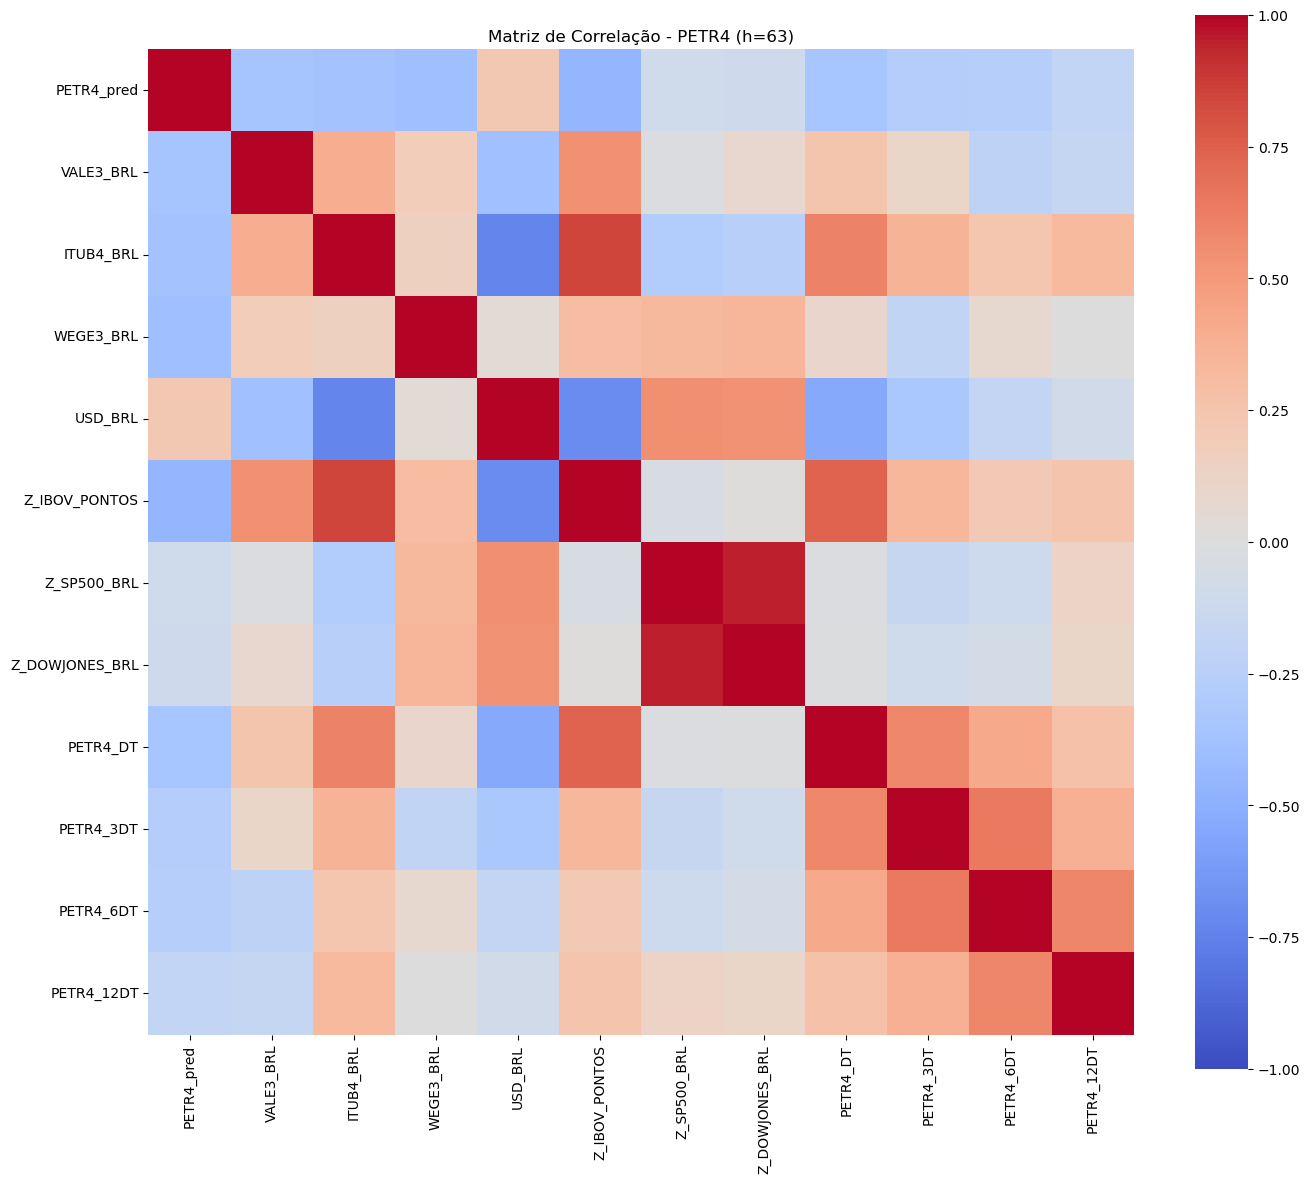

📷 Plot salvo: outputs/graficos/scatter_h63_20260227_200546.jpeg


<Figure size 1000x1000 with 0 Axes>

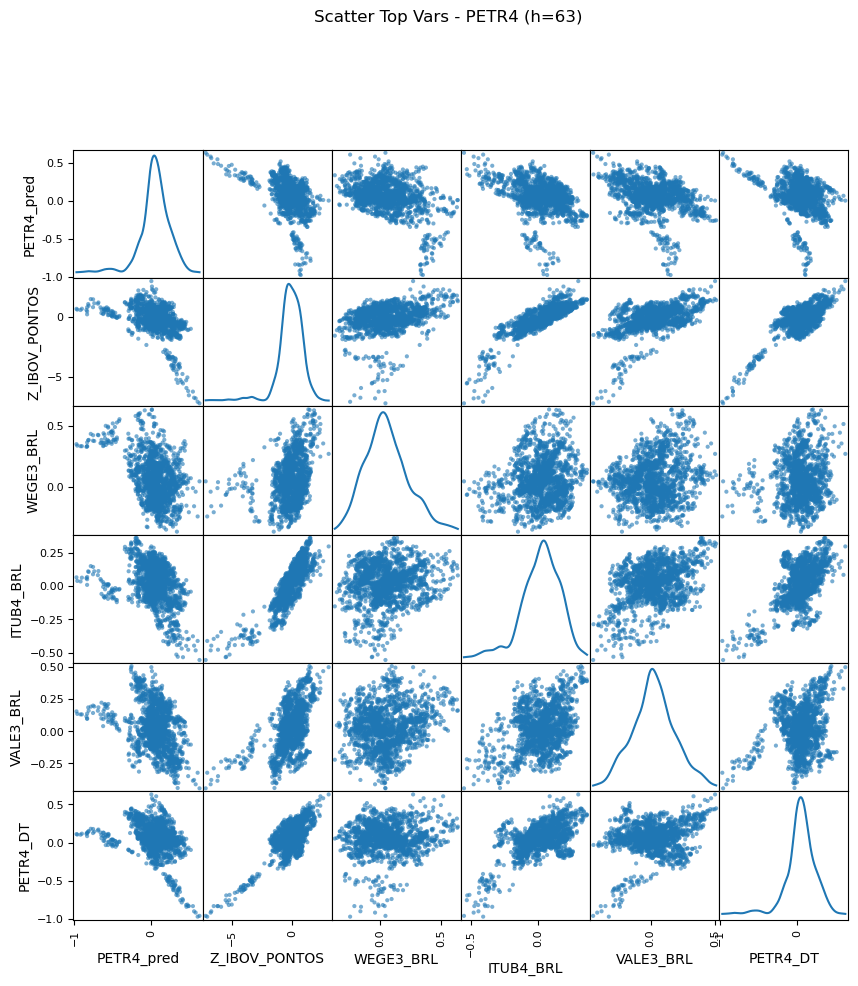

📷 Plot salvo: outputs/graficos/decompose_h63_20260227_200547.jpeg


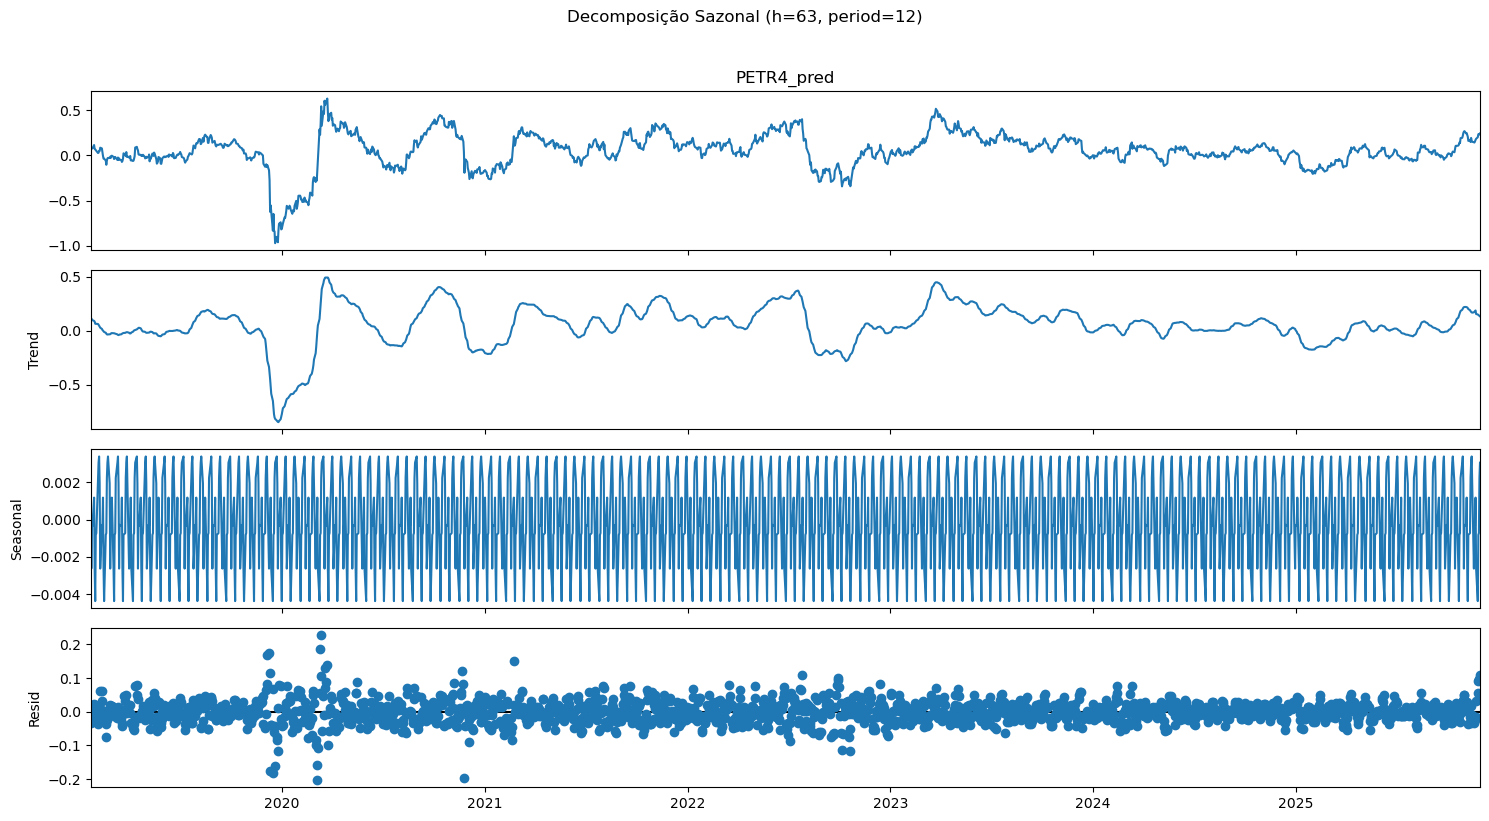

💾 CSV resultados salvo: outputs/resultados/results_h63_20260227_200604.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h63_20260227_200604.jpeg


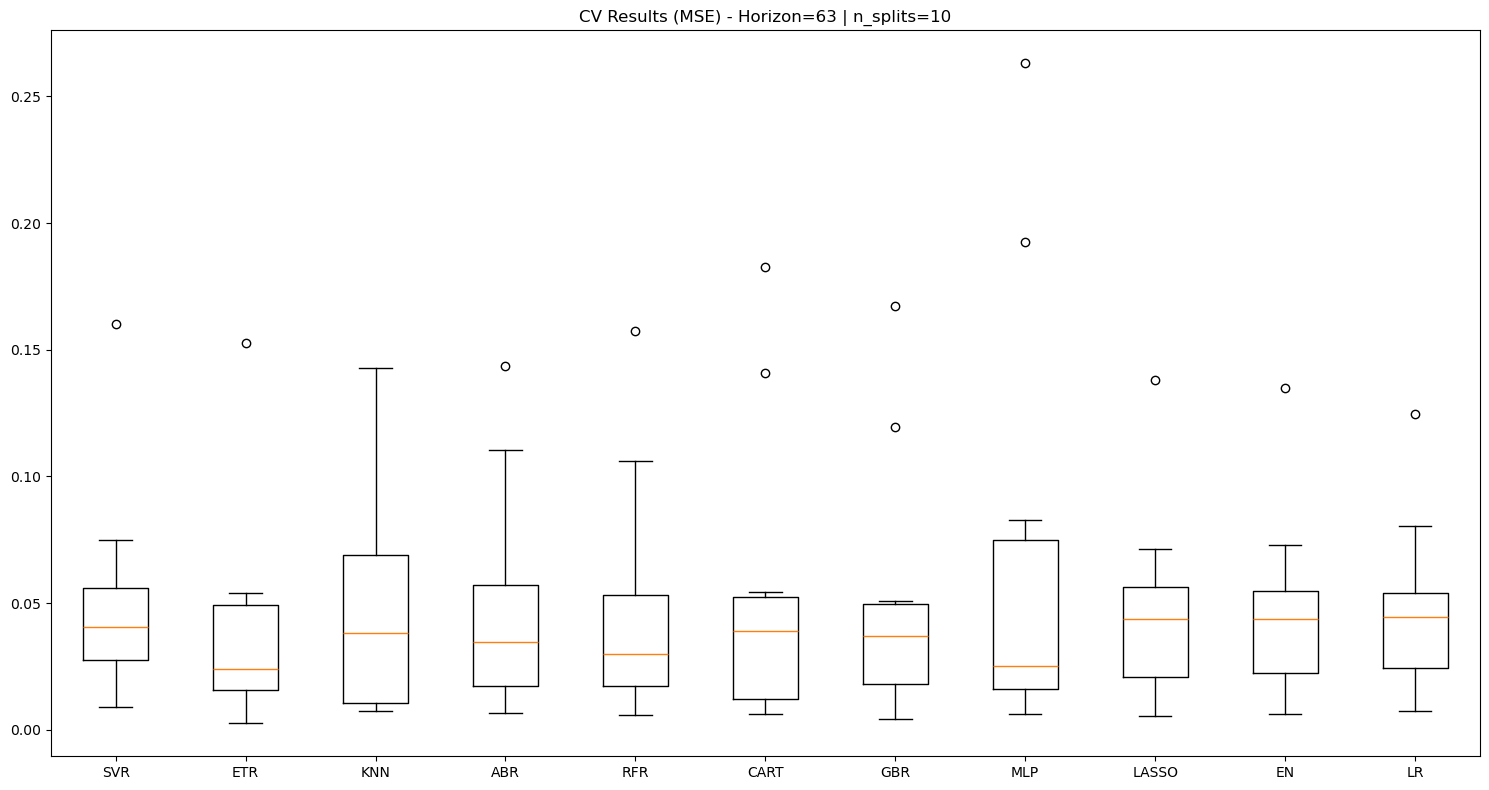

📷 Plot salvo: outputs/graficos/train_vs_test_h63_20260227_200604.jpeg


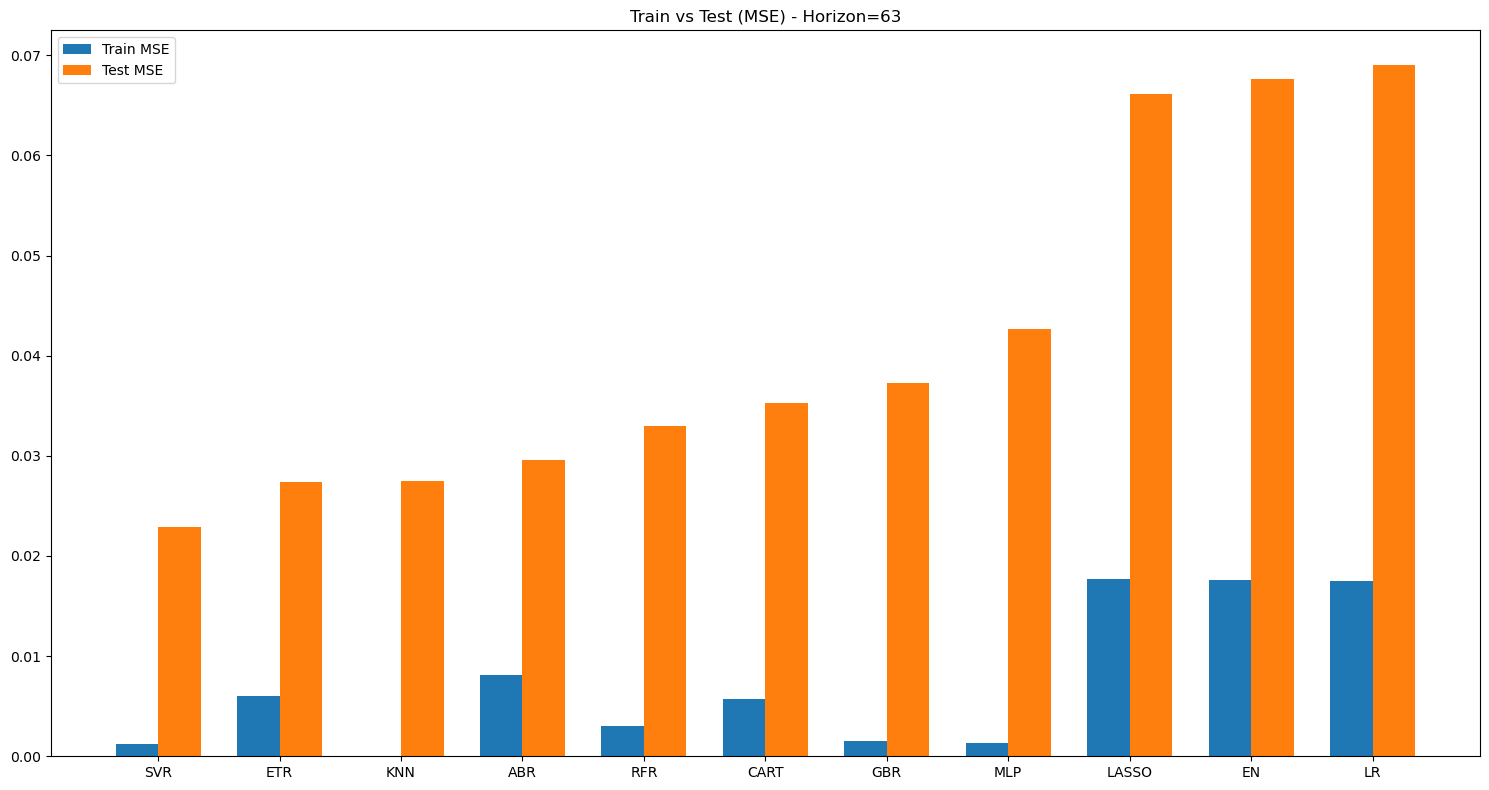


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
      63   SVR    0.050373   0.041405  0.001194 0.022862        10     1429     358
      63   ETR    0.039485   0.041461  0.005987 0.027411        10     1429     358
      63   KNN    0.047646   0.042130  0.000000 0.027494        10     1429     358
      63   ABR    0.049047   0.042986  0.008094 0.029593        10     1429     358
      63   RFR    0.047183   0.046327  0.003062 0.032962        10     1429     358
      63  CART    0.054276   0.057050  0.005691 0.035267        10     1429     358
      63   GBR    0.050577   0.049949  0.001532 0.037292        10     1429     358
      63   MLP    0.069218   0.083654  0.001303 0.042703        10     1429     358
      63 LASSO    0.047282   0.036664  0.017703 0.066108        10     1429     358
      63    EN    0.047063   0.035693  0.017600 0.067597        10     1429     358
      63    LR    0.047272   0.033545  0.01

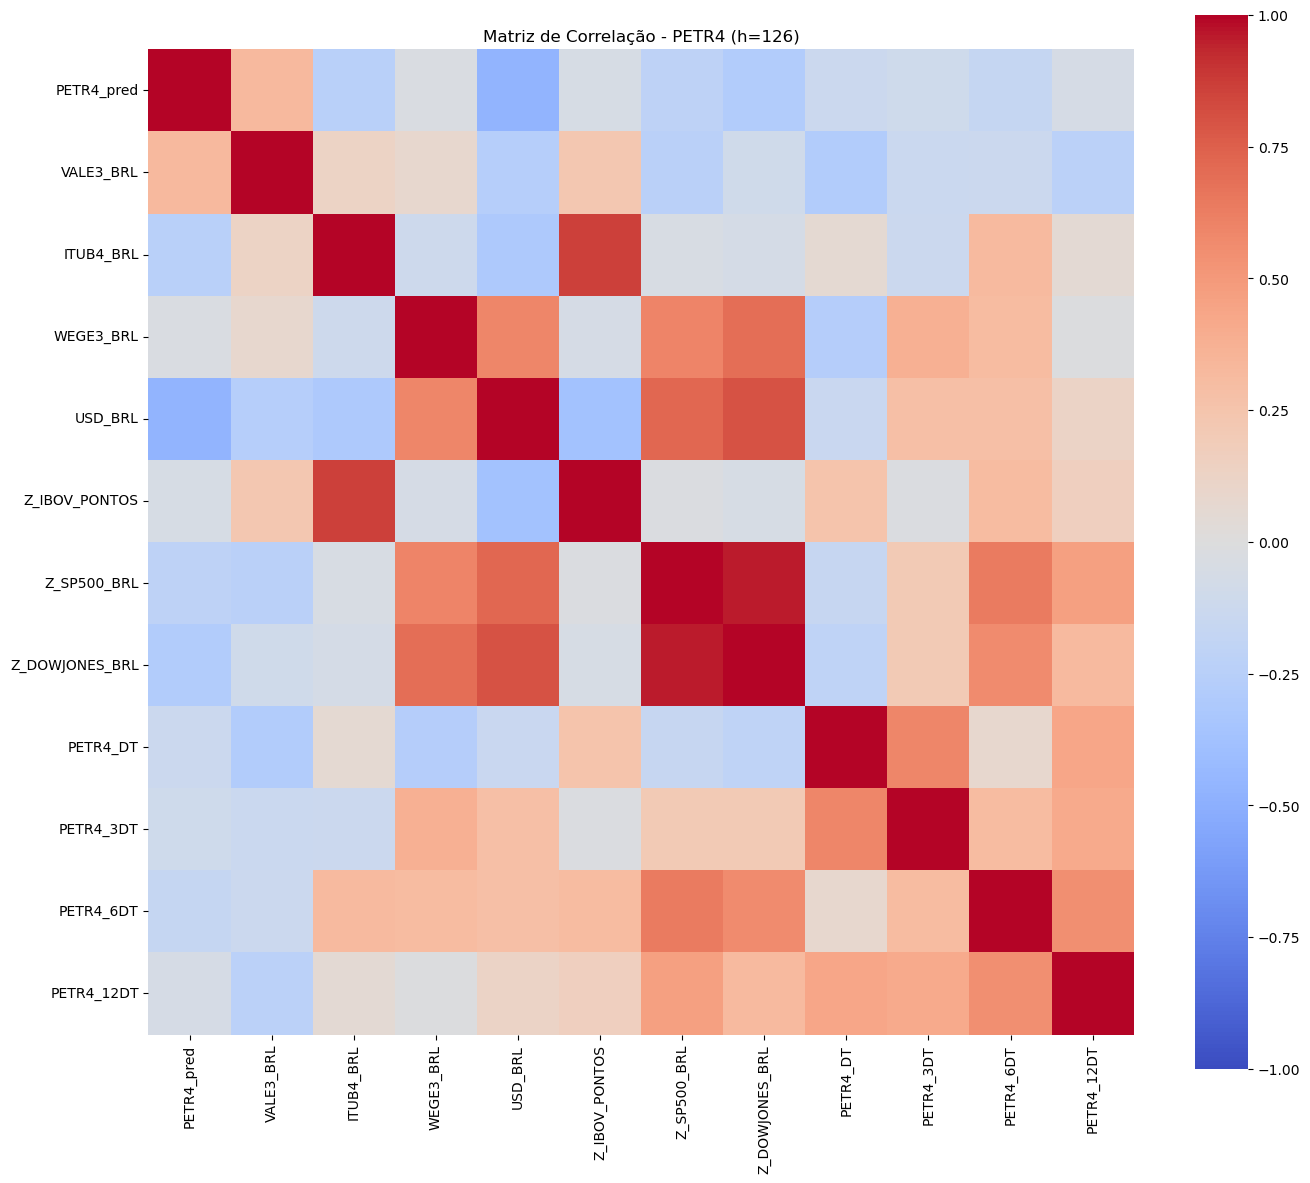

📷 Plot salvo: outputs/graficos/scatter_h126_20260227_200606.jpeg


<Figure size 1000x1000 with 0 Axes>

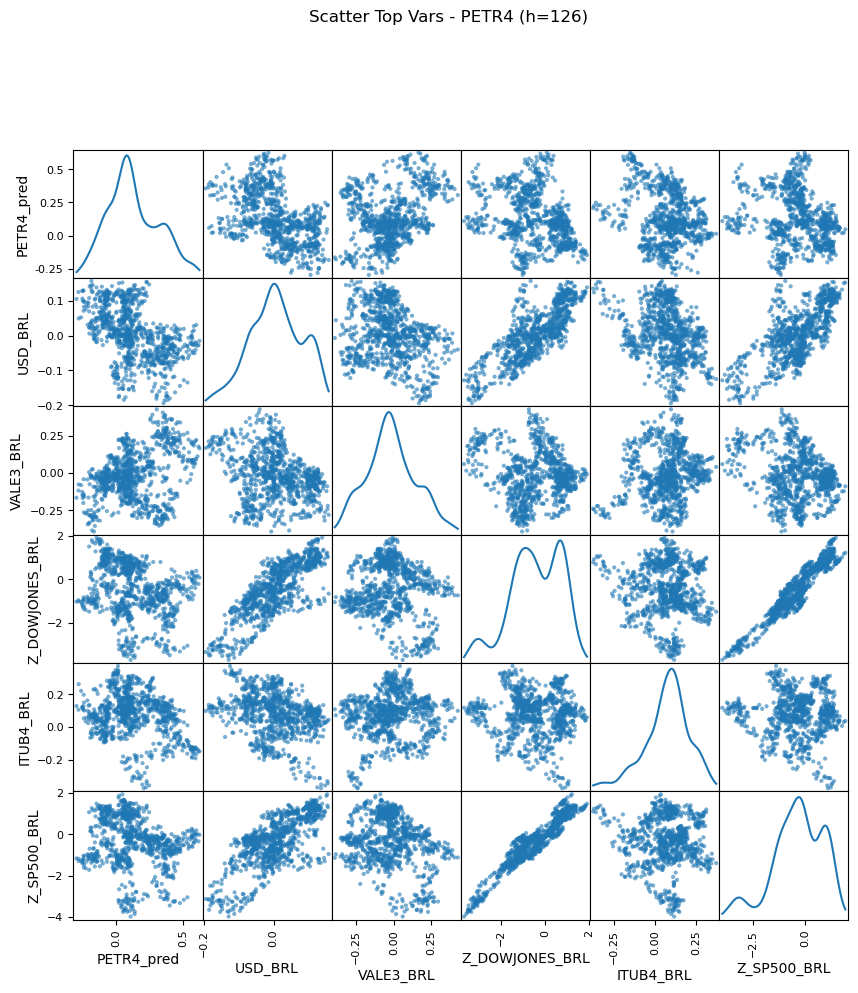

📷 Plot salvo: outputs/graficos/decompose_h126_20260227_200607.jpeg


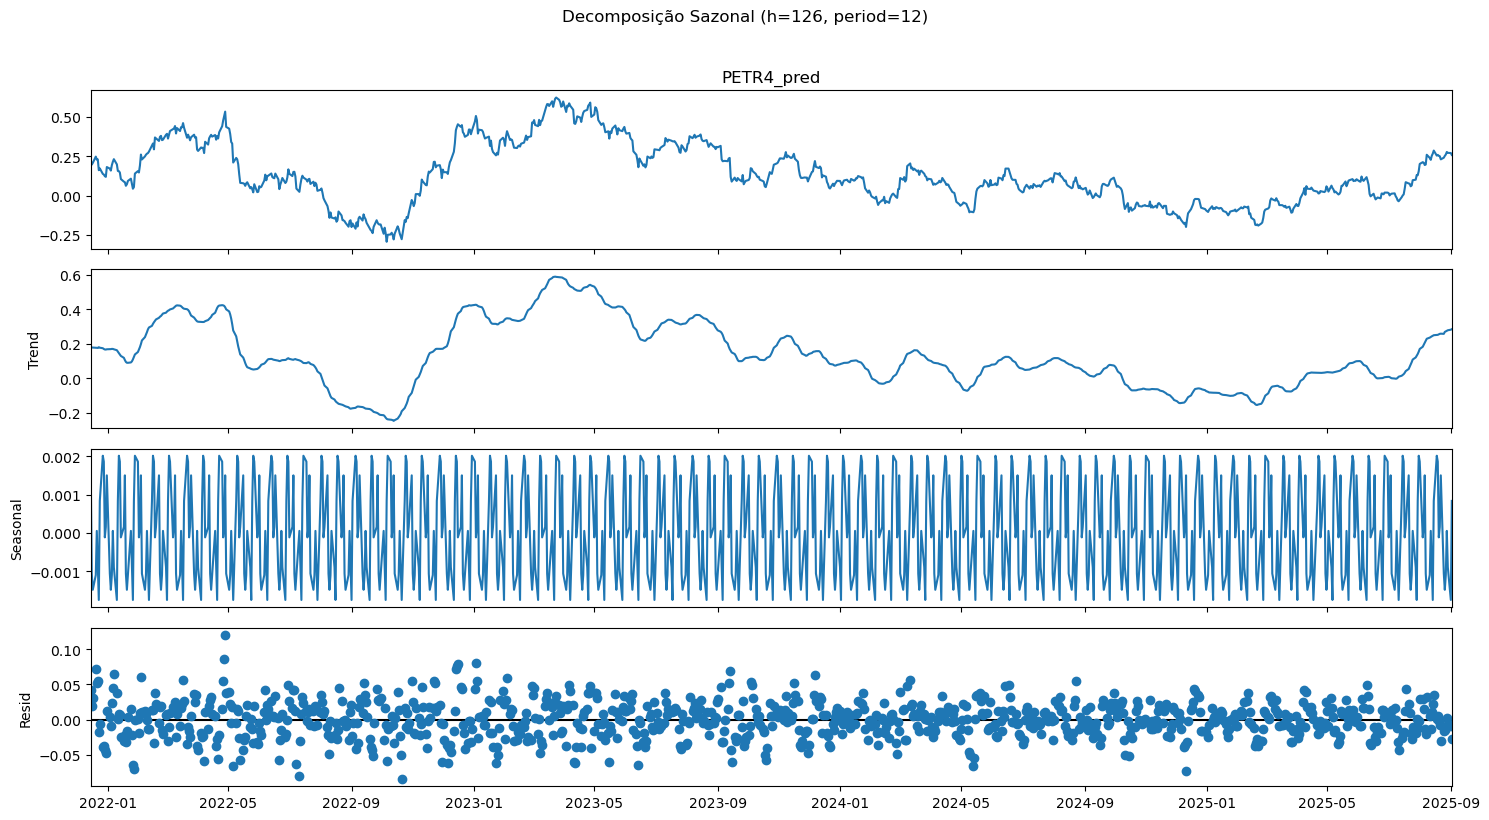

💾 CSV resultados salvo: outputs/resultados/results_h126_20260227_200620.csv
📷 Plot salvo: outputs/graficos/cv_boxplot_h126_20260227_200620.jpeg


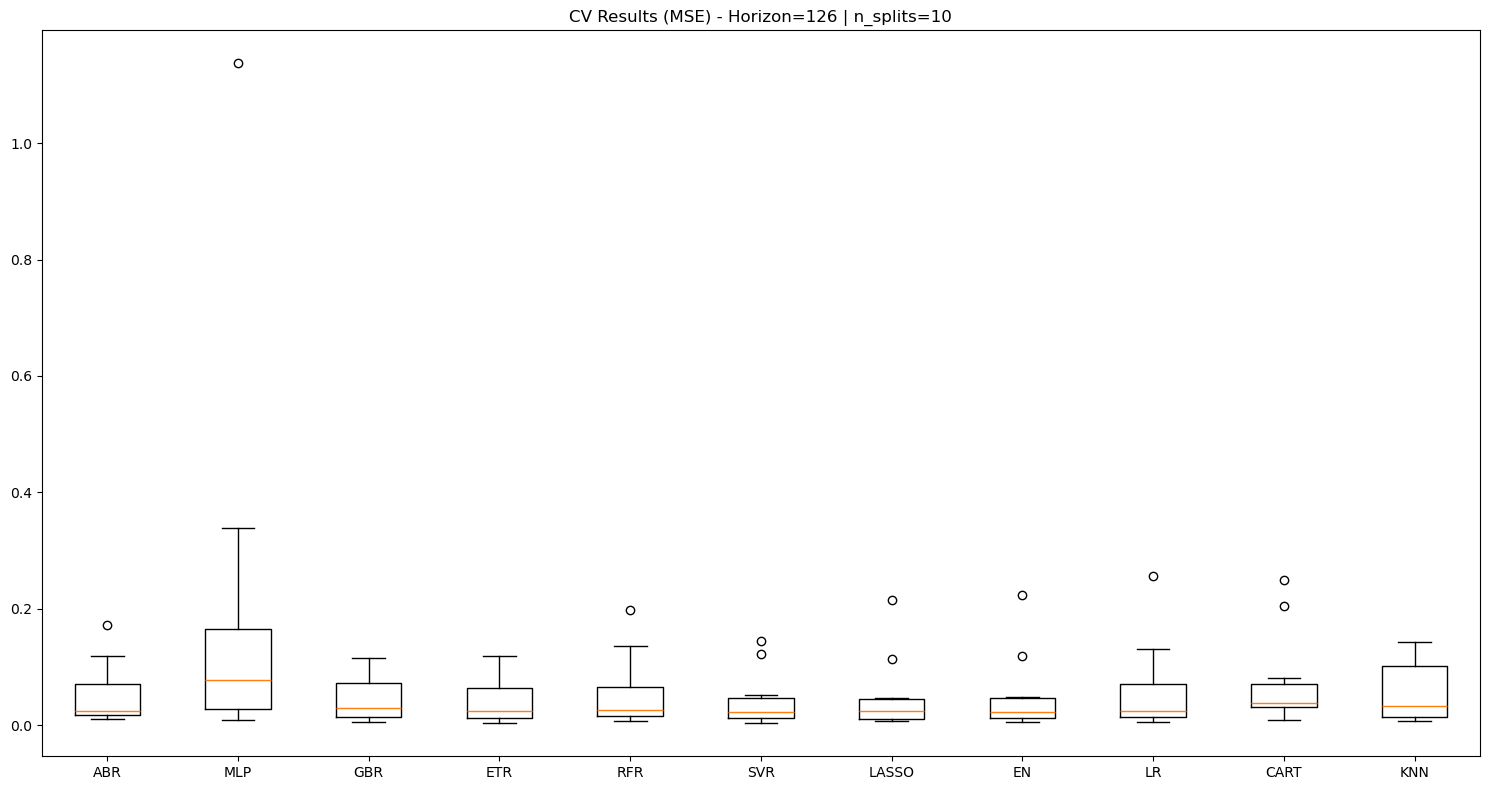

📷 Plot salvo: outputs/graficos/train_vs_test_h126_20260227_200621.jpeg


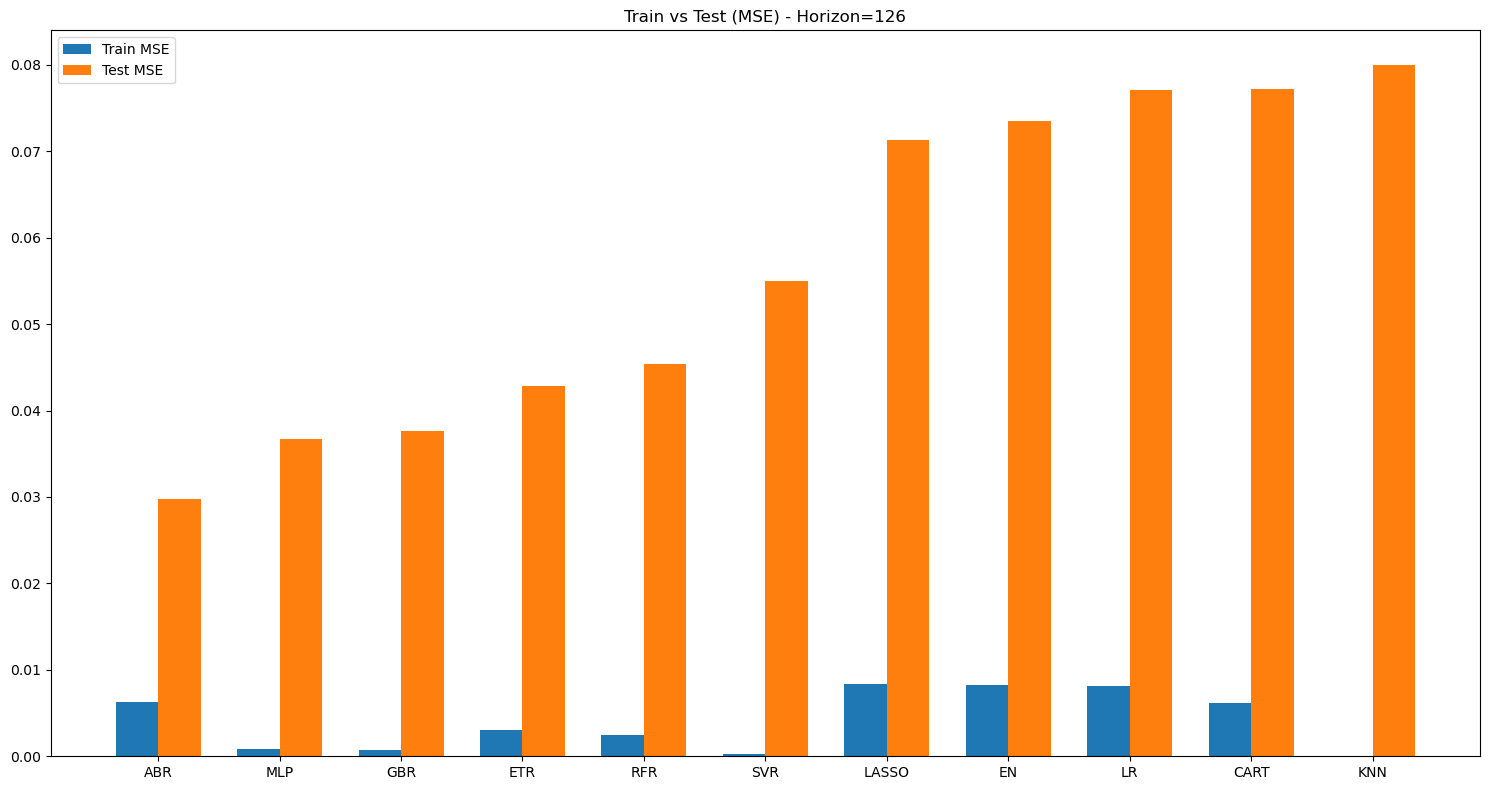


Resumo (ordenado por Test_MSE):
 Horizon Model CV_MSE_mean CV_MSE_std Train_MSE Test_MSE  n_splits  n_train  n_test
     126   ABR    0.052108   0.051619  0.006233 0.029719        10      774     194
     126   MLP    0.204627   0.325560  0.000787 0.036724        10      774     194
     126   GBR    0.044441   0.039247  0.000673 0.037658        10      774     194
     126   ETR    0.042384   0.040270  0.003008 0.042829        10      774     194
     126   RFR    0.054833   0.060228  0.002479 0.045353        10      774     194
     126   SVR    0.043267   0.046676  0.000214 0.054952        10      774     194
     126 LASSO    0.050090   0.062681  0.008327 0.071286        10      774     194
     126    EN    0.051880   0.065217  0.008207 0.073470        10      774     194
     126    LR    0.061138   0.075021  0.008143 0.077046        10      774     194
     126  CART    0.074346   0.078911  0.006107 0.077193        10      774     194
     126   KNN    0.055865   0.048750  0.00

In [114]:
px, all_results, best = run(CFG)

In [115]:
# salvar melhor modelo para cada horizonte
for h in CFG.horizons:
    res_h = all_results[all_results["Horizon"] == h]

    if res_h.empty:
        continue

    dataset, X, y, _ = build_dataset_petr4(px, horizon=h, cfg=CFG)

    salvar_melhor_modelo_pkl(X, y, res_h, horizon=h, cfg=CFG)


🏆 Melhor modelo para horizonte 5: ABR
💾 Modelo salvo: outputs/resultados/PETR4_best_model_h5.pkl

🏆 Melhor modelo para horizonte 21: ABR
💾 Modelo salvo: outputs/resultados/PETR4_best_model_h21.pkl

🏆 Melhor modelo para horizonte 63: SVR
💾 Modelo salvo: outputs/resultados/PETR4_best_model_h63.pkl

🏆 Melhor modelo para horizonte 126: ABR
💾 Modelo salvo: outputs/resultados/PETR4_best_model_h126.pkl


In [116]:
# carregar modelo
model = carregar_modelo_pkl("outputs/resultados/PETR4_best_model_h21.pkl")

# preparar novos dados (mesma estrutura)
dataset, X, y, _ = build_dataset_petr4(px, horizon=63, cfg=CFG)

# usar últimos dados
X_last = X.iloc[-1:].copy()

# previsão
pred = prever_petr4(model, X_last)

print("Retorno previsto:", pred)

Retorno previsto: [0.02980437]


In [117]:
preco_atual = px["PETR4_BRL"].iloc[-1]

preco_previsto = preco_atual * np.exp(pred[0])

print("Preço previsto:", preco_previsto)

Preço previsto: 40.51985113388563


In [124]:
# ============================================================
# GRÁFICO DE PREVISÃO PETR4
# ============================================================

def plot_previsao_petr4(
    px: pd.DataFrame,
    pred_retorno: float,
    horizon: int,
    salvar=True,
    cfg=CFG
):
    """
    Mostra gráfico com preço histórico + previsão futura.
    """

    # preço atual
    preco_atual = px["PETR4_BRL"].iloc[-1]

    # preço previsto
    preco_previsto = preco_atual * np.exp(pred_retorno)

    # histórico recente (para visualização)
    janela = 120  # dias
    historico = px["PETR4_BRL"].iloc[-janela:]

    # eixo futuro
    datas_futuras = pd.date_range(
        start=historico.index[-1],
        periods=horizon + 1,
        freq="B"
    )

    # gráfico
    fig = plt.figure(figsize=(15, 8))

    plt.plot(historico, label="Histórico PETR4", linewidth=2)

    # ponto atual
    plt.scatter(
        historico.index[-1],
        preco_atual,
        s=120,
        label="Preço atual"
    )

    # previsão
    plt.plot(
        [historico.index[-1], datas_futuras[-1]],
        [preco_atual, preco_previsto],
        linestyle="--",
        linewidth=3,
        label=f"Previsão {horizon} dias"
    )

    plt.scatter(
        datas_futuras[-1],
        preco_previsto,
        s=150,
        label="Preço previsto"
    )

    plt.title(f"Previsão PETR4 - Horizonte {horizon} dias")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # salvar
    if salvar:
        save_fig(fig, f"previsao_PETR4_h{horizon}", cfg)

    plt.show()

    print(f"\nPreço atual: {preco_atual:.2f}")
    print(f"Preço previsto: {preco_previsto:.2f}")
    print(f"Retorno previsto: {pred_retorno:.4f}")

📷 Plot salvo: outputs/graficos/previsao_PETR4_h63_20260227_211052.jpeg


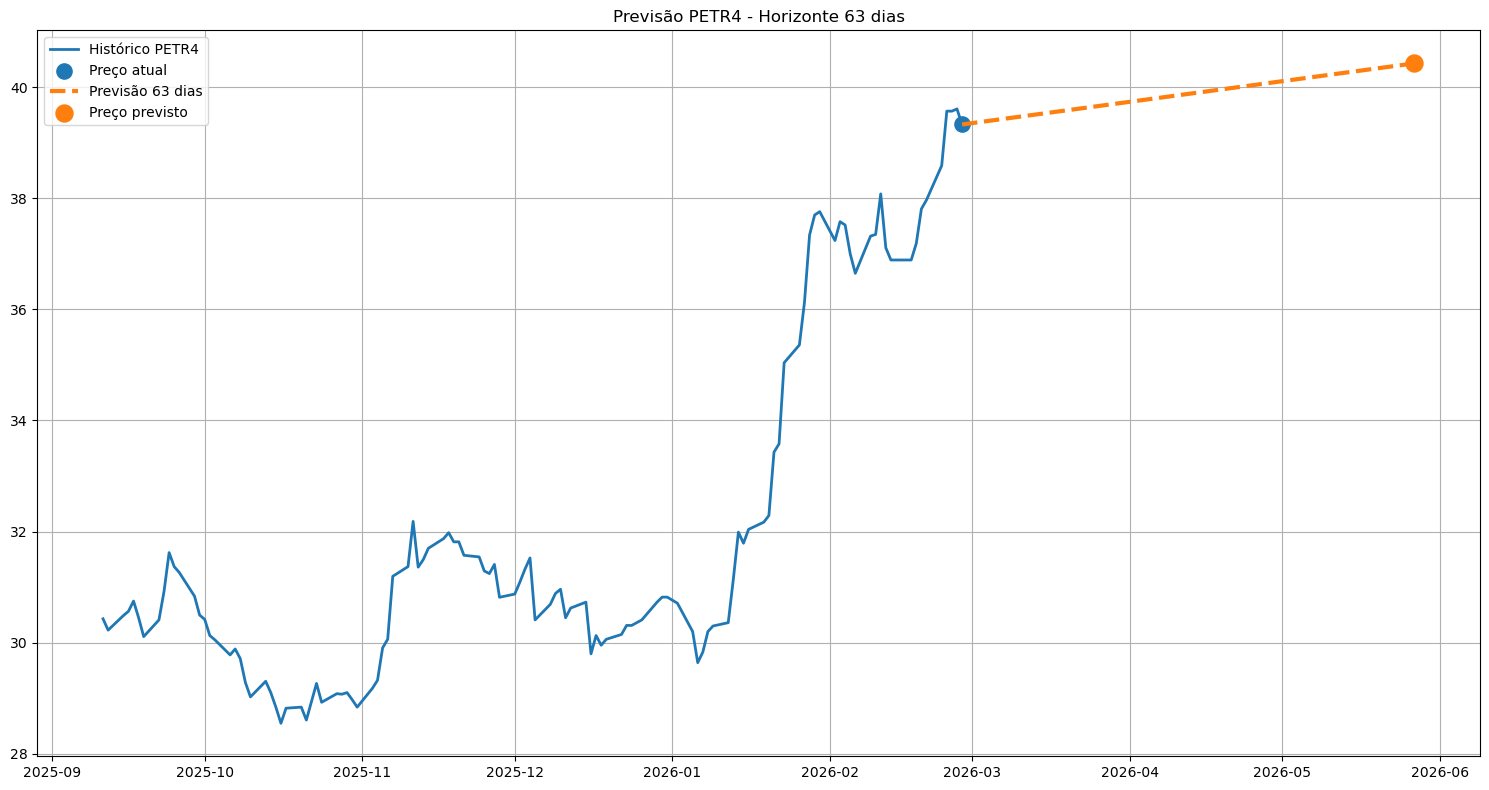


Preço atual: 39.33
Preço previsto: 40.43
Retorno previsto: 0.0276


In [125]:
# carregar modelo
model = carregar_modelo_pkl("outputs/resultados/PETR4_best_model_h21.pkl")

# preparar dataset
dataset, X, y, _ = build_dataset_petr4(px, horizon=21, cfg=CFG)

# pegar últimos dados
X_last = X.iloc[-1:]

# previsão
pred = model.predict(X_last)[0]

# gráfico

plot_previsao_petr4(px, pred, horizon=63)

In [130]:
# ------------------------------------------------------------
# Modelo SARIMAX (ARIMA com variáveis exógenas)
# ------------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. Garantir alinhamento com y
# ------------------------------------------------------------
y_train_ = y_train.loc[X_train_ARIMA.index]
y_test_  = y_test.loc[X_test_ARIMA.index]

# ------------------------------------------------------------
# 2. Checar e tratar NaN e infinitos
# ------------------------------------------------------------
X_train_ARIMA = X_train_ARIMA.replace([np.inf, -np.inf], np.nan).ffill().bfill()
X_test_ARIMA  = X_test_ARIMA.replace([np.inf, -np.inf], np.nan).ffill().bfill()

y_train_ = y_train_.replace([np.inf, -np.inf], np.nan).ffill().bfill()
y_test_  = y_test_.replace([np.inf, -np.inf], np.nan).ffill().bfill()

# ------------------------------------------------------------
# 3. Definir ordem do ARIMA
# (depois você pode otimizar)
# ------------------------------------------------------------
order = (1, 1, 1)

# ------------------------------------------------------------
# 4. Treinar o modelo
# ------------------------------------------------------------
model = SARIMAX(
    y_train_,
    exog=X_train_ARIMA,
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

print(res.summary())

# ------------------------------------------------------------
# 5. Previsão no teste
# ------------------------------------------------------------
forecast = res.get_forecast(
    steps=len(y_test_),
    exog=X_test_ARIMA
)

y_pred = forecast.predicted_mean

# ------------------------------------------------------------
# 6. Métricas
# ------------------------------------------------------------
mae  = mean_absolute_error(y_test_, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_, y_pred))

print("\nResultados SARIMAX:")
print("MAE :", mae)
print("RMSE:", rmse)

# ------------------------------------------------------------
# 7. Comparação real vs previsto
# ------------------------------------------------------------
df_result = y_test_.to_frame("Real")
df_result["Previsto"] = y_pred

print(df_result.head())

                               SARIMAX Results                                
Dep. Variable:             PETR4_pred   No. Observations:                   39
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  47.810
Date:                Fri, 27 Feb 2026   AIC                            -77.619
Time:                        21:13:54   BIC                            -63.367
Sample:                             0   HQIC                           -72.645
                                 - 39                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
VALE3_BRL        -0.7716      0.224     -3.451      0.001      -1.210      -0.333
ITUB4_BRL        -1.4936      0.536     -2.786      0.005      -2.544      -0.443
WEGE3_BRL        -0.1526      0.162     

Treino: (39,) (39, 6)

Resumo do modelo:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  52.315
Date:                Fri, 27 Feb 2026   AIC                            -86.629
Time:                        21:15:09   BIC                            -71.657
Sample:                             0   HQIC                           -81.257
                                 - 39                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0321      0.010      3.308      0.001       0.013       0.051
VALE3_BRL        -0.6551      0.188     -3.493      0.000      -1.023      -0.288

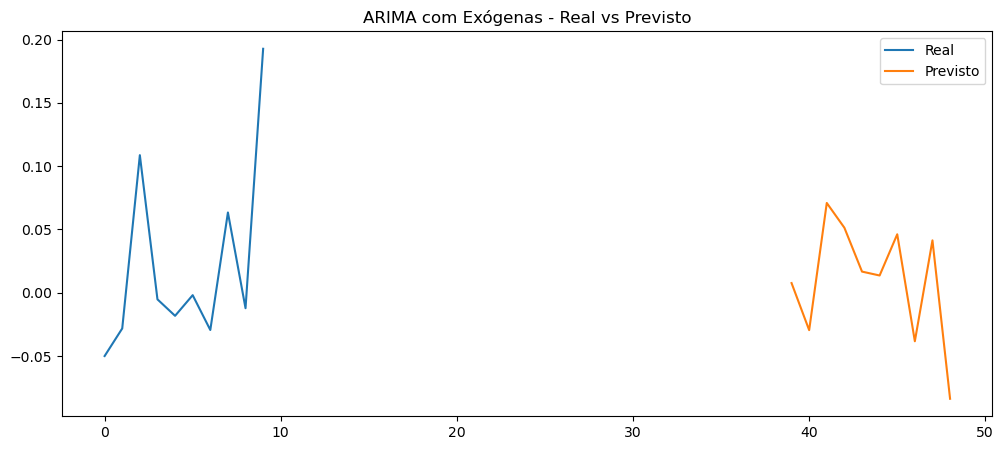

In [131]:
# ------------------------------------------------------------
# ARIMA com variáveis exógenas (pipeline completo e otimizado)
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construir dataset de treino (alinhamento + limpeza)
# ------------------------------------------------------------
df_train = (
    pd.concat([y_train.rename("y"), X_train_ARIMA], axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# separar endog e exog
y_tr = df_train["y"].astype(float).reset_index(drop=True)
X_tr = df_train.drop(columns="y").astype(float).reset_index(drop=True)

print("Treino:", y_tr.shape, X_tr.shape)


# ------------------------------------------------------------
# 2. Treinar modelo ARIMA
# ------------------------------------------------------------
order = (1, 0, 0)  # depois você pode otimizar

model = ARIMA(
    endog=y_tr,
    exog=X_tr,
    order=order
)

model_fit = model.fit()

print("\nResumo do modelo:")
print(model_fit.summary())


# ------------------------------------------------------------
# 3. Construir dataset de teste (mesma lógica)
# ------------------------------------------------------------
df_test = (
    pd.concat([y_test.rename("y"), X_test_ARIMA], axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

y_te = df_test["y"].astype(float).reset_index(drop=True)
X_te = df_test.drop(columns="y").astype(float).reset_index(drop=True)

print("Teste:", y_te.shape, X_te.shape)


# ------------------------------------------------------------
# 4. Previsão
# ------------------------------------------------------------
y_pred = model_fit.forecast(
    steps=len(y_te),
    exog=X_te
)


# ------------------------------------------------------------
# 5. Avaliação
# ------------------------------------------------------------
mae  = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print("\nResultados ARIMA:")
print("MAE :", mae)
print("RMSE:", rmse)


# ------------------------------------------------------------
# 6. Comparação Real vs Previsto
# ------------------------------------------------------------
df_result = pd.DataFrame({
    "Real": y_te,
    "Previsto": y_pred
})

print(df_result.head())


# ------------------------------------------------------------
# 7. Gráfico
# ------------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_result["Real"], label="Real")
plt.plot(df_result["Previsto"], label="Previsto")
plt.legend()
plt.title("ARIMA com Exógenas - Real vs Previsto")
plt.show()

In [132]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# 1) TREINO (alinha + limpa do mesmo jeito que o modelo usa)
# ------------------------------------------------------------
df_train = (
    pd.concat([y_train.rename("y"), X_train_ARIMA], axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

y_tr = df_train["y"].astype(float).reset_index(drop=True)
X_tr = df_train.drop(columns="y").astype(float).reset_index(drop=True)

# Fit
order = (1, 0, 0)
model_fit = ARIMA(endog=y_tr, exog=X_tr, order=order).fit()
print(model_fit.summary())

# ------------------------------------------------------------
# 2) ERRO DE TREINO (use o MESMO y_tr e o fittedvalues alinhado)
# ------------------------------------------------------------
# garante mesmo tamanho (por segurança)
y_fit = model_fit.fittedvalues
n = min(len(y_tr), len(y_fit))

error_Training_ARIMA = mean_squared_error(y_tr.iloc[:n], y_fit.iloc[:n])
print("Training MSE ARIMA:", error_Training_ARIMA)

# ------------------------------------------------------------
# 3) TESTE (alinha + limpa igual ao treino)
# ------------------------------------------------------------
df_test = (
    pd.concat([y_test.rename("y"), X_test_ARIMA], axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

y_te = df_test["y"].astype(float).reset_index(drop=True)
X_te = df_test.drop(columns="y").astype(float).reset_index(drop=True)

print("Shapes -> y_tr:", y_tr.shape, "X_tr:", X_tr.shape, "| y_te:", y_te.shape, "X_te:", X_te.shape)

# ------------------------------------------------------------
# 4) PREVISÃO FORA DA AMOSTRA (mais consistente)
# ------------------------------------------------------------
predicted = model_fit.forecast(steps=len(y_te), exog=X_te)

# ------------------------------------------------------------
# 5) ERRO DE TESTE (comparar com y_te, não y_test cru)
# ------------------------------------------------------------
error_Test_ARIMA = mean_squared_error(y_te, predicted)
print("Test MSE ARIMA:", error_Test_ARIMA)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  52.315
Date:                Fri, 27 Feb 2026   AIC                            -86.629
Time:                        21:16:46   BIC                            -71.657
Sample:                             0   HQIC                           -81.257
                                 - 39                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0321      0.010      3.308      0.001       0.013       0.051
VALE3_BRL        -0.6551      0.188     -3.493      0.000      -1.023      -0.288
ITUB4_BRL        -1.3087      0.421     


===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====
Train cols: 11 Test cols: 11 Final cols: 11

-- TEST --
Extras no test: []
Faltando no test: []
Mesma ordem test? True

-- FINAL --
Extras no final: []
Faltando no final: []
Mesma ordem final? False

===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====
Train cols: 11 Test cols: 11 Final cols: 11

-- TEST --
Extras no test: []
Faltando no test: []
Mesma ordem test? True

-- FINAL --
Extras no final: []
Faltando no final: []
Mesma ordem final? True

Colunas ARIMA: ['VALE3_BRL', 'ITUB4_BRL', 'WEGE3_BRL', 'USD_BRL', 'Z_IBOV_PONTOS', 'Z_SP500_BRL']
Train: 39 Test: 10 Total: 1028

Resumo ARIMA:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  52.315
Date:                Fri, 27 Feb 2026   AIC                            -86.629
Time:               

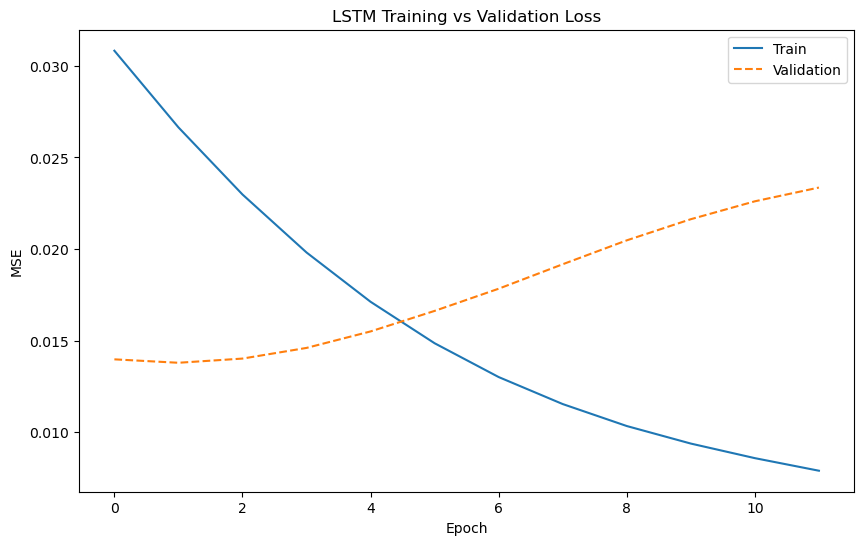


Training MSE LSTM: 0.02104385609167877
Test MSE LSTM: 0.01254011165677435
Test MAE LSTM: 0.08226261338062915

===== COMPARAÇÃO FINAL =====
ARIMA -> MSE: 0.010489 | MAE: 0.071148
LSTM  -> MSE: 0.012540 | MAE: 0.082263


In [138]:
# ============================================================
# PIPELINE COMPLETO (CONSERTO DO ERRO DE FEATURE NAMES + DIAGNÓSTICO)
# - Seleção de colunas ARIMA (exógenas)
# - ARIMA (statsmodels) + MSE treino/teste (alinhado e limpo)
# - LSTM: scaler com colunas/ordem garantidas + janelas seq_len
# - Gráfico loss LSTM (treino vs validação)
# - Diagnóstico de colunas (extras/faltando/ordem) que causam o erro
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from keras import layers, models, callbacks

from matplotlib import pyplot


# ------------------------------------------------------------
# 0) Funções utilitárias
# ------------------------------------------------------------
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    """Remove inf, converte para NaN, e faz dropna (mantém só linhas completas)."""
    return df.replace([np.inf, -np.inf], np.nan).dropna()

def align_yX(y: pd.Series, X: pd.DataFrame, name_y: str = "y"):
    """
    Concatena y e X, remove NaN/inf e devolve (y_alinhado, X_alinhado) com índice resetado.
    """
    df = clean_df(pd.concat([y.rename(name_y), X], axis=1))
    y_out = df[name_y].astype(float).reset_index(drop=True)
    X_out = df.drop(columns=[name_y]).astype(float).reset_index(drop=True)
    return y_out, X_out

def diagnose_feature_mismatch(X_train: pd.DataFrame, X_test: pd.DataFrame, X_final: pd.DataFrame):
    train_cols = list(X_train.columns)
    test_cols  = list(X_test.columns)
    final_cols = list(X_final.columns)

    print("\n===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====")
    print("Train cols:", len(train_cols), "Test cols:", len(test_cols), "Final cols:", len(final_cols))

    print("\n-- TEST --")
    print("Extras no test:",  sorted(set(test_cols) - set(train_cols))[:50])
    print("Faltando no test:", sorted(set(train_cols) - set(test_cols))[:50])
    print("Mesma ordem test?", train_cols == test_cols)

    print("\n-- FINAL --")
    print("Extras no final:",  sorted(set(final_cols) - set(train_cols))[:50])
    print("Faltando no final:", sorted(set(train_cols) - set(final_cols))[:50])
    print("Mesma ordem final?", train_cols == final_cols)

def enforce_same_columns(X_train: pd.DataFrame, X_other: pd.DataFrame, fill_value: float = 0.0) -> pd.DataFrame:
    """
    Reindexa X_other para ter exatamente as colunas de X_train na mesma ordem.
    Se faltar coluna, preenche com fill_value. Se sobrar coluna, remove.
    """
    return X_other.reindex(columns=X_train.columns, fill_value=fill_value)

def make_lstm_windows(X_train: np.ndarray, X_test: np.ndarray, X_final: np.ndarray,
                      y_train: np.ndarray, y_test: np.ndarray, seq_len: int):
    """
    Constrói janelas (samples, seq_len, n_features).
    - Treino: janelas só dentro de X_train
    - Teste: janelas cruzando treino->teste via X_final
    Retorna: X_train_LSTM, Y_train_LSTM, X_test_LSTM, Y_test_LSTM
    """
    n_features = X_train.shape[1]

    n_train_samples = X_train.shape[0] - seq_len + 1
    if n_train_samples <= 0:
        raise ValueError(f"seq_len={seq_len} é maior que o tamanho do treino ({X_train.shape[0]}).")

    n_test_samples = X_test.shape[0]

    X_train_LSTM = np.zeros((n_train_samples, seq_len, n_features), dtype=float)
    X_test_LSTM  = np.zeros((n_test_samples,  seq_len, n_features), dtype=float)

    # Treino
    for i in range(seq_len):
        X_train_LSTM[:, i, :] = X_train[i : i + n_train_samples, :]

    # Target do treino alinhado com o final de cada janela
    Y_train_LSTM = y_train[seq_len - 1 : seq_len - 1 + n_train_samples]

    # Teste (usa X_final para janelas que começam no fim do treino)
    start = X_train.shape[0] - (seq_len - 1)  # seq_len=2 => start = len(train)-1
    for i in range(seq_len):
        X_test_LSTM[:, i, :] = X_final[start + i : start + i + n_test_samples, :]

    Y_test_LSTM = y_test

    return X_train_LSTM, Y_train_LSTM, X_test_LSTM, Y_test_LSTM


# ============================================================
# 1) DIAGNÓSTICO + CORREÇÃO DO ERRO DE FEATURE NAMES (LSTM)
# ============================================================
# (1) Diagnosticar diferenças
diagnose_feature_mismatch(X_train, X_test, X_final)

# (2) Forçar mesma lista de colunas e mesma ordem
#     (se faltar coluna no test/final, preenche com 0; se sobrar, remove)
X_test_fixed  = enforce_same_columns(X_train, X_test,  fill_value=0.0)
X_final_fixed = enforce_same_columns(X_train, X_final, fill_value=0.0)

# (3) (opcional) Verificar de novo
diagnose_feature_mismatch(X_train, X_test_fixed, X_final_fixed)


# ============================================================
# 2) COLUNAS PARA ARIMA (EXÓGENAS) — usando X_train original
# ============================================================
arima_cols = [
    "VALE3_BRL",
    "ITUB4_BRL",
    "WEGE3_BRL",
    "USD_BRL",
    "Z_IBOV_PONTOS",
    "Z_SP500_BRL",
    "Z_DOW_BRL"
]

arima_cols = [c for c in arima_cols if c in X_train.columns]
print("\nColunas ARIMA:", arima_cols)

X_train_ARIMA = X_train.loc[:, arima_cols].copy()
X_test_ARIMA  = X_test_fixed.loc[:, arima_cols].copy()

print("Train:", len(X_train_ARIMA), "Test:", len(X_test_ARIMA), "Total:", len(X_final_fixed))


# ============================================================
# 3) ARIMA COM EXÓGENAS (TREINO/TESTE)
# ============================================================
# 3.1) Treino alinhado e limpo
y_tr, X_tr = align_yX(y_train, X_train_ARIMA, name_y="y")

# 3.2) Fit
order = (1, 0, 0)
model_fit = ARIMA(endog=y_tr, exog=X_tr, order=order).fit()

print("\nResumo ARIMA:")
print(model_fit.summary())

# 3.3) Erro treino
y_fit = model_fit.fittedvalues
n = min(len(y_tr), len(y_fit))
mse_train_arima = mean_squared_error(y_tr.iloc[:n], y_fit.iloc[:n])
print("\nTraining MSE ARIMA:", mse_train_arima)

# 3.4) Teste alinhado e limpo (mesma regra)
y_te, X_te = align_yX(y_test, X_test_ARIMA, name_y="y")

# 3.5) Previsão fora da amostra + erro teste

y_pred_arima = model_fit.forecast(steps=len(y_te), exog=X_te)

mse_test_arima = mean_squared_error(y_te, y_pred_arima)
mae_test_arima = mean_absolute_error(y_te, y_pred_arima)
print("Test MSE ARIMA:", mse_test_arima)
print("Test MAE ARIMA:", mae_test_arima)


# ============================================================
# 4) LSTM (PREPARAÇÃO + TREINO + LOSS + MÉTRICAS)
# ============================================================
seq_len = 2

# 4.1) Escalonar (fit só no treino; transform no test/final já com colunas/ordem corrigidas)
scaler = StandardScaler()

# IMPORTANTE: usar DataFrames com MESMAS colunas e ordem
Xtr_scaled    = scaler.fit_transform(X_train)        # fit no treino
Xte_scaled    = scaler.transform(X_test_fixed)       # transform no test corrigido
Xfinal_scaled = scaler.transform(X_final_fixed)      # transform no final corrigido

# y como array 1D
ytr_arr = np.asarray(y_train).reshape(-1)
yte_arr = np.asarray(y_test).reshape(-1)

# 4.2) Construir janelas
X_train_LSTM, Y_train_LSTM, X_test_LSTM, Y_test_LSTM = make_lstm_windows(
    X_train=Xtr_scaled,
    X_test=Xte_scaled,
    X_final=Xfinal_scaled,
    y_train=ytr_arr,
    y_test=yte_arr,
    seq_len=seq_len
)

print("\nShapes LSTM:")
print("X_train_LSTM:", X_train_LSTM.shape)
print("Y_train_LSTM:", Y_train_LSTM.shape)
print("X_test_LSTM :", X_test_LSTM.shape)
print("Y_test_LSTM :", Y_test_LSTM.shape)

# 4.3) Modelo LSTM
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_LSTM.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(seq_len, n_features)),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 4.4) Treino
LSTMModel_fit = lstm_model.fit(
    X_train_LSTM,
    Y_train_LSTM,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 4.5) Gráfico Loss (treino vs validação)
pyplot.figure(figsize=(10, 6))
pyplot.plot(LSTMModel_fit.history["loss"], label="Train")
pyplot.plot(LSTMModel_fit.history["val_loss"], "--", label="Validation")
pyplot.legend()
pyplot.title("LSTM Training vs Validation Loss")
pyplot.xlabel("Epoch")
pyplot.ylabel("MSE")
pyplot.show()

# 4.6) Métricas LSTM
yhat_train = lstm_model.predict(X_train_LSTM, verbose=0).reshape(-1)
mse_train_lstm = mean_squared_error(Y_train_LSTM, yhat_train)

yhat_test = lstm_model.predict(X_test_LSTM, verbose=0).reshape(-1)
mse_test_lstm = mean_squared_error(Y_test_LSTM, yhat_test)
mae_test_lstm = mean_absolute_error(Y_test_LSTM, yhat_test)

print("\nTraining MSE LSTM:", mse_train_lstm)
print("Test MSE LSTM:", mse_test_lstm)
print("Test MAE LSTM:", mae_test_lstm)


# ============================================================
# 5) COMPARAÇÃO FINAL
# ============================================================
print("\n===== COMPARAÇÃO FINAL =====")
print(f"ARIMA -> MSE: {mse_test_arima:.6f} | MAE: {mae_test_arima:.6f}")
print(f"LSTM  -> MSE: {mse_test_lstm:.6f} | MAE: {mae_test_lstm:.6f}")


===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====
Train cols: 11 Test cols: 11 Final cols: 11

-- TEST --
Extras no test: []
Faltando no test: []
Mesma ordem test? True

-- FINAL --
Extras no final: []
Faltando no final: []
Mesma ordem final? False

===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====
Train cols: 11 Test cols: 11 Final cols: 11

-- TEST --
Extras no test: []
Faltando no test: []
Mesma ordem test? True

-- FINAL --
Extras no final: []
Faltando no final: []
Mesma ordem final? True

Colunas ARIMA: ['VALE3_BRL', 'ITUB4_BRL', 'WEGE3_BRL', 'USD_BRL', 'Z_IBOV_PONTOS', 'Z_SP500_BRL']
Train: 39 Test: 10 Total: 1028

Resumo ARIMA:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  52.315
Date:                Fri, 27 Feb 2026   AIC                            -86.629
Time:               

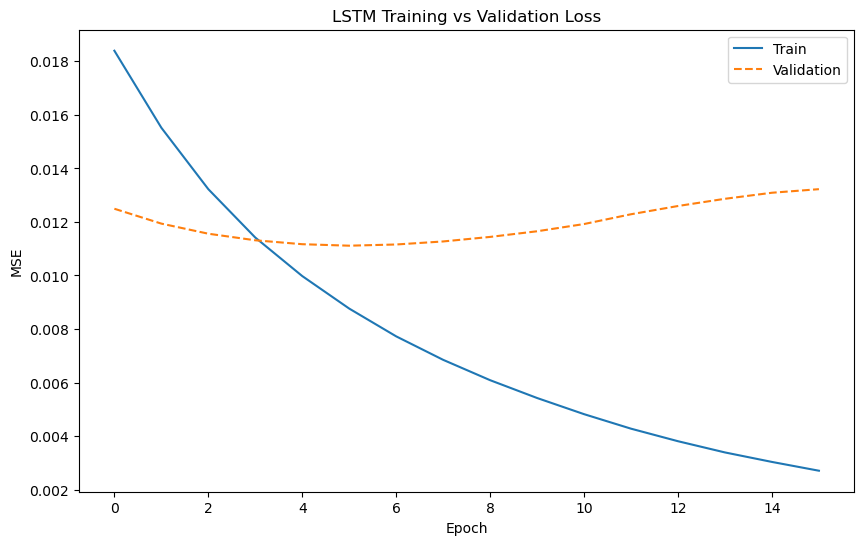


Training MSE LSTM: 0.008438897676825785
Test MSE LSTM: 0.012215782001506675

===== COMPARAÇÃO FINAL =====
ARIMA -> Train MSE: 0.004012 | Test MSE: 0.010489
LSTM  -> Train MSE: 0.008439 | Test MSE: 0.012216


In [141]:

# ============================================================
# PIPELINE COMPLETO (CONSERTO DO ERRO DE FEATURE NAMES + ARIMA + LSTM)
# Inclui:
# - Diagnóstico + correção de colunas (ordem/nome) para StandardScaler
# - ARIMA com exógenas + MSE treino/teste
# - LSTM: scaler + janelas (seq_len) + treino
# - Gráfico da loss (treino vs validação)
# - Avaliação LSTM no formato que você pediu (Training/Test MSE)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from keras import layers, models, callbacks

from matplotlib import pyplot


# ------------------------------------------------------------
# 0) Funções utilitárias
# ------------------------------------------------------------
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    return df.replace([np.inf, -np.inf], np.nan).dropna()

def align_yX(y: pd.Series, X: pd.DataFrame, name_y: str = "y"):
    df = clean_df(pd.concat([y.rename(name_y), X], axis=1))
    y_out = df[name_y].astype(float).reset_index(drop=True)
    X_out = df.drop(columns=[name_y]).astype(float).reset_index(drop=True)
    return y_out, X_out

def diagnose_feature_mismatch(X_train: pd.DataFrame, X_test: pd.DataFrame, X_final: pd.DataFrame):
    train_cols = list(X_train.columns)
    test_cols  = list(X_test.columns)
    final_cols = list(X_final.columns)

    print("\n===== DIAGNÓSTICO DE COLUNAS (Scaler / Feature Names) =====")
    print("Train cols:", len(train_cols), "Test cols:", len(test_cols), "Final cols:", len(final_cols))

    print("\n-- TEST --")
    print("Extras no test:",  sorted(set(test_cols) - set(train_cols))[:50])
    print("Faltando no test:", sorted(set(train_cols) - set(test_cols))[:50])
    print("Mesma ordem test?", train_cols == test_cols)

    print("\n-- FINAL --")
    print("Extras no final:",  sorted(set(final_cols) - set(train_cols))[:50])
    print("Faltando no final:", sorted(set(train_cols) - set(final_cols))[:50])
    print("Mesma ordem final?", train_cols == final_cols)

def enforce_same_columns(X_train: pd.DataFrame, X_other: pd.DataFrame, fill_value: float = 0.0) -> pd.DataFrame:
    return X_other.reindex(columns=X_train.columns, fill_value=fill_value)

def make_lstm_windows(X_train: np.ndarray, X_test: np.ndarray, X_final: np.ndarray,
                      y_train: np.ndarray, y_test: np.ndarray, seq_len: int):
    n_features = X_train.shape[1]

    n_train_samples = X_train.shape[0] - seq_len + 1
    if n_train_samples <= 0:
        raise ValueError(f"seq_len={seq_len} é maior que o tamanho do treino ({X_train.shape[0]}).")

    n_test_samples = X_test.shape[0]

    X_train_LSTM = np.zeros((n_train_samples, seq_len, n_features), dtype=float)
    X_test_LSTM  = np.zeros((n_test_samples,  seq_len, n_features), dtype=float)

    # treino
    for i in range(seq_len):
        X_train_LSTM[:, i, :] = X_train[i : i + n_train_samples, :]

    # target do treino alinhado com o final da janela
    Y_train_LSTM = y_train[seq_len - 1 : seq_len - 1 + n_train_samples]

    # teste (usa X_final para cruzar treino->teste)
    start = X_train.shape[0] - (seq_len - 1)  # seq_len=2 => start = len(train)-1
    for i in range(seq_len):
        X_test_LSTM[:, i, :] = X_final[start + i : start + i + n_test_samples, :]

    Y_test_LSTM = y_test
    return X_train_LSTM, Y_train_LSTM, X_test_LSTM, Y_test_LSTM


# ============================================================
# 1) DIAGNÓSTICO + CORREÇÃO DO ERRO DE FEATURE NAMES
# ============================================================
diagnose_feature_mismatch(X_train, X_test, X_final)

X_test_fixed  = enforce_same_columns(X_train, X_test,  fill_value=0.0)
X_final_fixed = enforce_same_columns(X_train, X_final, fill_value=0.0)

diagnose_feature_mismatch(X_train, X_test_fixed, X_final_fixed)


# ============================================================
# 2) COLUNAS PARA ARIMA (EXÓGENAS)
# ============================================================
arima_cols = [
    "VALE3_BRL",
    "ITUB4_BRL",
    "WEGE3_BRL",
    "USD_BRL",
    "Z_IBOV_PONTOS",
    "Z_SP500_BRL",
    "Z_DOW_BRL"
]
arima_cols = [c for c in arima_cols if c in X_train.columns]
print("\nColunas ARIMA:", arima_cols)

X_train_ARIMA = X_train.loc[:, arima_cols].copy()
X_test_ARIMA  = X_test_fixed.loc[:, arima_cols].copy()

print("Train:", len(X_train_ARIMA), "Test:", len(X_test_ARIMA), "Total:", len(X_final_fixed))


# ============================================================
# 3) ARIMA COM EXÓGENAS (TREINO/TESTE)
# ============================================================
y_tr, X_tr = align_yX(y_train, X_train_ARIMA, name_y="y")

order = (1, 0, 0)
ARIMAModel_fit = ARIMA(endog=y_tr, exog=X_tr, order=order).fit()

print("\nResumo ARIMA:")
print(ARIMAModel_fit.summary())

# erro treino ARIMA
y_fit = ARIMAModel_fit.fittedvalues
n = min(len(y_tr), len(y_fit))
error_Training_ARIMA = mean_squared_error(y_tr.iloc[:n], y_fit.iloc[:n])
print("\nTraining MSE ARIMA:", error_Training_ARIMA)

# teste ARIMA (alinhado e limpo)
y_te, X_te = align_yX(y_test, X_test_ARIMA, name_y="y")

pred_arima = ARIMAModel_fit.forecast(steps=len(y_te), exog=X_te)
error_Test_ARIMA = mean_squared_error(y_te, pred_arima)
print("Test MSE ARIMA:", error_Test_ARIMA)


# ============================================================
# 4) LSTM (PREPARAÇÃO + TREINO)
# ============================================================
seq_len = 2

# scaler (fit no treino, transform no test/final corrigidos)
scaler = StandardScaler()
Xtr_scaled    = scaler.fit_transform(X_train)        # X_train é referência do fit (nomes/ordem)
Xte_scaled    = scaler.transform(X_test_fixed)
Xfinal_scaled = scaler.transform(X_final_fixed)

# y como array
ytr_arr = np.asarray(y_train).reshape(-1)
yte_arr = np.asarray(y_test).reshape(-1)

# janelas
X_train_LSTM, Y_train_LSTM, X_test_LSTM, Y_test_LSTM = make_lstm_windows(
    X_train=Xtr_scaled,
    X_test=Xte_scaled,
    X_final=Xfinal_scaled,
    y_train=ytr_arr,
    y_test=yte_arr,
    seq_len=seq_len
)

print("\nShapes LSTM:")
print("X_train_LSTM:", X_train_LSTM.shape)
print("Y_train_LSTM:", Y_train_LSTM.shape)
print("X_test_LSTM :", X_test_LSTM.shape)
print("Y_test_LSTM :", Y_test_LSTM.shape)

# modelo LSTM
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_LSTM.shape[2]

LSTMModel = models.Sequential([
    layers.Input(shape=(seq_len, n_features)),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

LSTMModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# treino
LSTMModel_fit = LSTMModel.fit(
    X_train_LSTM,
    Y_train_LSTM,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 5) GRÁFICO LOSS LSTM (TREINO vs VALIDAÇÃO)
# ============================================================
pyplot.figure(figsize=(10, 6))
pyplot.plot(LSTMModel_fit.history["loss"], label="Train")
pyplot.plot(LSTMModel_fit.history["val_loss"], "--", label="Validation")
pyplot.legend()
pyplot.title("LSTM Training vs Validation Loss")
pyplot.xlabel("Epoch")
pyplot.ylabel("MSE")
pyplot.show()


# ============================================================
# 6) AVALIAÇÃO DO LSTM (DO JEITO QUE VOCÊ PEDIU)
# ============================================================
# erro no treino
yhat_train = LSTMModel.predict(X_train_LSTM, verbose=0)

# garantir vetor 1D (às vezes vem 2D)
yhat_train = yhat_train.flatten()

error_Training_LSTM = mean_squared_error(
    Y_train_LSTM,
    yhat_train
)
print("\nTraining MSE LSTM:", error_Training_LSTM)

# previsão no teste
predicted = LSTMModel.predict(X_test_LSTM, verbose=0).flatten()

error_Test_LSTM = mean_squared_error(
    Y_test_LSTM,
    predicted
)
print("Test MSE LSTM:", error_Test_LSTM)


# ============================================================
# 7) COMPARAÇÃO FINAL
# ============================================================
print("\n===== COMPARAÇÃO FINAL =====")
print(f"ARIMA -> Train MSE: {error_Training_ARIMA:.6f} | Test MSE: {error_Test_ARIMA:.6f}")
print(f"LSTM  -> Train MSE: {error_Training_LSTM:.6f} | Test MSE: {error_Test_LSTM:.6f}")


In [143]:
import numpy as np
import pandas as pd

# -----------------------------
# Horizontes (dias úteis)
# -----------------------------
H = {
    "5_dias": 5,
    "1_mes": 21,
    "3_meses": 63,
    "6_meses": 126,
    "1_ano": 252
}

# ============================================================
# 0) Defina o último fechamento (base)
# ============================================================
# Opção A (recomendado): pegue do seu dataset de preços reais
# Exemplo (ajuste o nome da coluna):
# last_close = float(df_precos["Close"].iloc[-1])

# Opção B: se o seu y_train/y_test for PREÇO (não retorno), use o último valor observado:
# last_close = float(pd.concat([y_train, y_test]).iloc[-1])

# >>> AJUSTE AQUI <<<
last_close = float(pd.concat([y_train, y_test]).iloc[-1])  # troque se necessário

print("Último fechamento (base):", last_close)

# ============================================================
# 1) PREVISÃO ARIMA (com exógenas) — cenário exógenas constantes
# ============================================================
def make_future_exog_like_last(X_last_row: pd.Series, steps: int) -> pd.DataFrame:
    return pd.DataFrame([X_last_row.values] * steps, columns=X_last_row.index)

X_last_arima = (X_test_ARIMA.iloc[-1] if len(X_test_ARIMA) > 0 else X_train_ARIMA.iloc[-1])

preds_arima = {}
for nome, steps in H.items():
    X_future_arima = make_future_exog_like_last(X_last_arima, steps)
    preds_arima[nome] = ARIMAModel_fit.forecast(steps=steps, exog=X_future_arima).to_numpy()

# ============================================================
# 2) PREVISÃO LSTM multi-step — cenário features constantes
# ============================================================
def lstm_multi_step_forecast(model, last_window, last_x_row, steps: int) -> np.ndarray:
    seq_len, n_features = last_window.shape
    window = last_window.copy()
    out = np.zeros(steps, dtype=float)

    for t in range(steps):
        yhat = model.predict(window.reshape(1, seq_len, n_features), verbose=0).reshape(-1)[0]
        out[t] = yhat
        window[:-1, :] = window[1:, :]
        window[-1, :] = last_x_row  # mantém features futuras constantes

    return out

last_window_lstm = (X_test_LSTM[-1] if len(X_test_LSTM) > 0 else X_train_LSTM[-1])

x_last_raw = X_final_fixed.iloc[-1:,:]
x_last_scaled = scaler.transform(x_last_raw).reshape(-1)

preds_lstm = {}
for nome, steps in H.items():
    preds_lstm[nome] = lstm_multi_step_forecast(
        model=LSTMModel,
        last_window=last_window_lstm,
        last_x_row=x_last_scaled,
        steps=steps
    )

# ============================================================
# 3) CONVERTER RETORNOS -> PREÇOS (usando último fechamento)
# ============================================================
def returns_to_prices(last_price: float, returns: np.ndarray, mode: str = "simple") -> np.ndarray:
    """
    mode="simple": P_t = P_{t-1}*(1+r_t)
    mode="log":    P_t = P_{t-1}*exp(r_t)
    """
    prices = np.zeros_like(returns, dtype=float)
    p = float(last_price)

    for i, r in enumerate(returns):
        if mode == "simple":
            p = p * (1.0 + float(r))
        elif mode == "log":
            p = p * float(np.exp(r))
        else:
            raise ValueError("mode deve ser 'simple' ou 'log'")
        prices[i] = p

    return prices

# >>> ESCOLHA AQUI o tipo do seu retorno:
RET_MODE = "simple"   # troque para "log" se seu y for log-retorno

prices_arima = {k: returns_to_prices(last_close, v, mode=RET_MODE) for k, v in preds_arima.items()}
prices_lstm  = {k: returns_to_prices(last_close, v, mode=RET_MODE) for k, v in preds_lstm.items()}

# ============================================================
# 4) Resumo: preço previsto no final de cada horizonte
# ============================================================
def summarize_prices(price_dict):
    rows = []
    for k, arr in price_dict.items():
        rows.append({
            "Horizonte": k,
            "Passos": len(arr),
            "Preco_previsto_final": float(arr[-1]),
            "Preco_previsto_medio": float(np.mean(arr))
        })
    return pd.DataFrame(rows).set_index("Horizonte")

df_price_arima = summarize_prices(prices_arima)
df_price_lstm  = summarize_prices(prices_lstm)

print("\n=== PREÇO previsto (ARIMA) ===")
print(df_price_arima)

print("\n=== PREÇO previsto (LSTM) ===")
print(df_price_lstm)

# (Opcional) Trajetória completa para 1 mês
# print("\nTrajetória ARIMA 1 mês:", prices_arima["1_mes"])
# print("Trajetória LSTM  1 mês:", prices_lstm["1_mes"])

Último fechamento (base): 0.19279519283977287

=== PREÇO previsto (ARIMA) ===
           Passos  Preco_previsto_final  Preco_previsto_medio
Horizonte                                                    
5_dias          5          1.231906e-01              0.147817
1_mes          21          3.035490e-02              0.083512
3_meses        63          7.678820e-04              0.032970
6_meses       126          3.089534e-06              0.016551
1_ano         252          5.001382e-11              0.008276

=== PREÇO previsto (LSTM) ===
           Passos  Preco_previsto_final  Preco_previsto_medio
Horizonte                                                    
5_dias          5              0.276708              0.249581
1_mes          21              0.697810              0.416407
3_meses        63              7.911109              2.177127
6_meses       126            301.986860             42.638331
1_ano         252         440037.209153          31086.268134


In [51]:
# ------------------------------------------------------------
# Avaliação do LSTM
# ------------------------------------------------------------
from sklearn.metrics import mean_squared_error

# erro no treino
yhat_train = LSTMModel.predict(X_train_LSTM)
error_Training_LSTM = mean_squared_error(
    Y_train_LSTM,
    yhat_train
)

print("Training MSE LSTM:", error_Training_LSTM)


# ------------------------------------------------------------
# Previsão no teste
# ------------------------------------------------------------
predicted = LSTMModel.predict(X_test_LSTM)

# garantir formato correto (às vezes sai como vetor 2D)
predicted = predicted.flatten()

# erro no teste
error_Test_LSTM = mean_squared_error(
    Y_test_LSTM,
    predicted
)

print("Test MSE LSTM:", error_Test_LSTM)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Training MSE LSTM: 7.282025334646311e-05
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Test MSE LSTM: 0.0174512551473685


In [52]:
# ------------------------------------------------------------
# Adicionar ARIMA e LSTM à comparação
# ------------------------------------------------------------
test_results.append(error_Test_ARIMA)
test_results.append(error_Test_LSTM)

train_results.append(error_Training_ARIMA)
train_results.append(error_Training_LSTM)

names.append("ARIMA")
names.append("LSTM")

In [53]:
# ------------------------------------------------------------
# Grid search simples para ARIMA/ARIMAX (com exógenas)
# Adaptado ao seu pipeline (y_train / X_train_ARIMA) e sem aspas “curvas”
# ------------------------------------------------------------
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# (opcional, recomendado) alinhar e remover NaNs uma vez
df_tr = (
    y_train.to_frame("y")
    .join(X_train_ARIMA, how="inner")
    .dropna()
).reset_index(drop=True)  # remove DateTimeIndex para evitar warning de freq

y_tr = df_tr["y"]
X_tr = df_tr.drop(columns=["y"])

def evaluate_arima_model(arima_order):
    model = ARIMA(endog=y_tr, exog=X_tr, order=arima_order)
    model_fit = model.fit()
    mse = mean_squared_error(y_tr, model_fit.fittedvalues)
    return mse

def evaluate_models(p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    mse = evaluate_arima_model(order)
                    print(f"ARIMA{order} MSE={mse:.7f}")
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                except Exception:
                    continue

    print(f"Best ARIMA{best_cfg} MSE={best_score:.7f}")
    return best_cfg, best_score

# ------------------------------------------------------------
# Avaliação de parâmetros
# ------------------------------------------------------------
p_values = [0, 1, 2]
d_values = range(0, 2)
q_values = range(0, 2)

warnings.filterwarnings("ignore")
best_cfg, best_score = evaluate_models(p_values, d_values, q_values)

ARIMA(0, 0, 0) MSE=0.0054263
ARIMA(0, 0, 1) MSE=0.0036616
ARIMA(0, 1, 0) MSE=0.0123205
ARIMA(0, 1, 1) MSE=0.0065170
ARIMA(1, 0, 0) MSE=0.0043500
ARIMA(1, 0, 1) MSE=0.0038254
ARIMA(1, 1, 0) MSE=0.0080149
ARIMA(1, 1, 1) MSE=0.0053811
ARIMA(2, 0, 0) MSE=0.0038111
ARIMA(2, 0, 1) MSE=0.0037223
ARIMA(2, 1, 0) MSE=0.0066961
ARIMA(2, 1, 1) MSE=0.0050843
Best ARIMA(0, 0, 1) MSE=0.0036616


In [54]:
# ------------------------------------------------------------
# ARIMA/ARIMAX "tuned" (2,0,1) com exógenas + MSE no teste
# (adaptado ao seu pipeline: y_train / y_test)
# ------------------------------------------------------------
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas as pd

# alinhar treino (mesmo índice, sem NaN) e remover DateTimeIndex (evita warning de freq)
df_tr = (
    y_train.to_frame("y")
    .join(X_train_ARIMA, how="inner")
    .dropna()
).reset_index(drop=True)

y_tr = df_tr["y"]
X_tr = df_tr.drop(columns=["y"])

# alinhar teste também (importante!)
df_te = (
    y_test.to_frame("y")
    .join(X_test_ARIMA, how="inner")
    .dropna()
).reset_index(drop=True)

y_te = df_te["y"]
X_te = df_te.drop(columns=["y"])

# ------------------------------------------------------------
# Treinar modelo ajustado
# ------------------------------------------------------------
modelARIMA_tuned = ARIMA(endog=y_tr, exog=X_tr, order=(2, 0, 1))
model_fit_tuned = modelARIMA_tuned.fit()

# ------------------------------------------------------------
# Prever no teste (fora da amostra)
# ------------------------------------------------------------
tr_len = len(y_tr)
te_len = len(y_te)

predicted_tuned = model_fit_tuned.predict(
    start=tr_len,
    end=tr_len + te_len - 1,
    exog=X_te
).to_numpy()

# ------------------------------------------------------------
# MSE no teste
# ------------------------------------------------------------
mse_test = mean_squared_error(y_te.to_numpy(), predicted_tuned)
print("Test MSE (ARIMA tuned):", mse_test)

Test MSE (ARIMA tuned): 0.014774231560071025


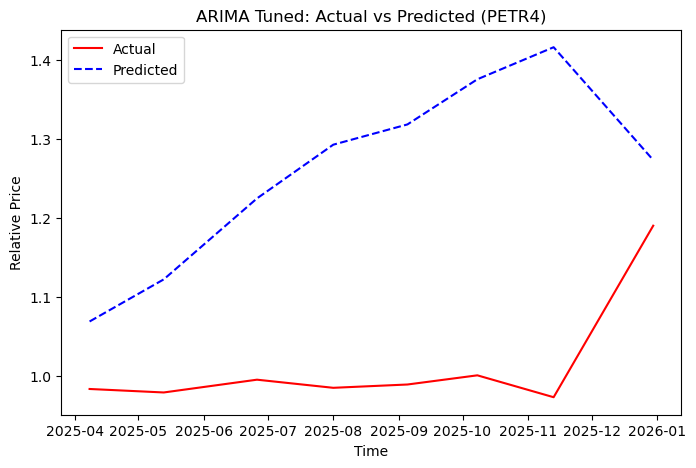

In [55]:
# ------------------------------------------------------------
# Plot: valores reais vs previstos (ARIMA tuned)
# ------------------------------------------------------------
from matplotlib import pyplot
import numpy as np
import pandas as pd

# garantir que predicted seja série com o mesmo índice
predicted_series = pd.Series(
    predicted_tuned,
    index=y_test.index
)

# transformar retornos log em preço relativo acumulado
actual = np.exp(y_test).cumprod()
predicted = np.exp(predicted_series).cumprod()

# gráfico
pyplot.figure(figsize=(8, 5))

pyplot.plot(actual, "r", label="Actual")
pyplot.plot(predicted, "b--", label="Predicted")

pyplot.legend()
pyplot.title("ARIMA Tuned: Actual vs Predicted (PETR4)")
pyplot.xlabel("Time")
pyplot.ylabel("Relative Price")

pyplot.show()

Faltando: []
px['PETR4_BRL'] shape: (1248,)
X_test_ARIMA shape: (8, 6)


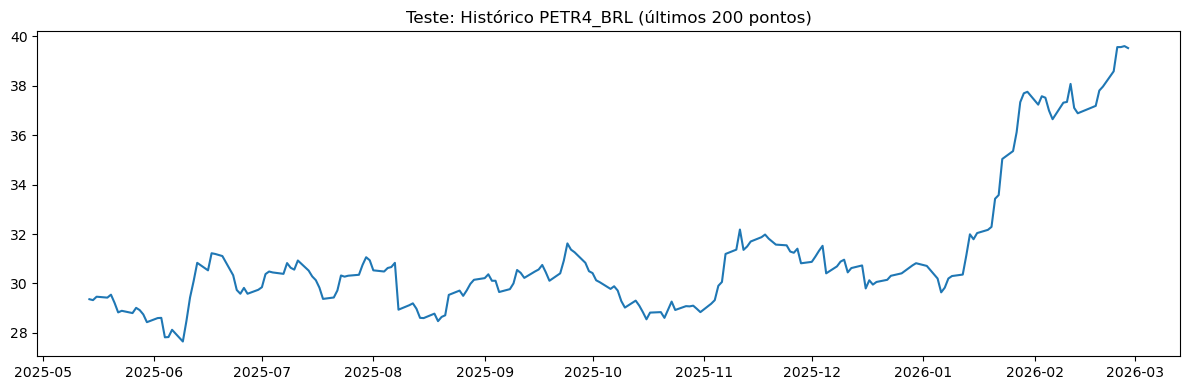

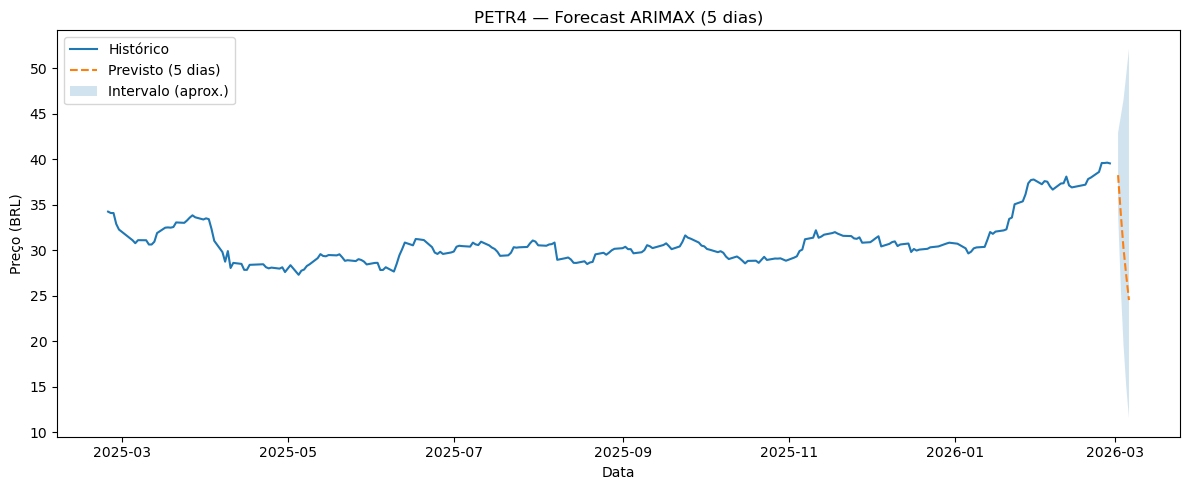

5 dias: preço previsto no final = 24.52 BRL


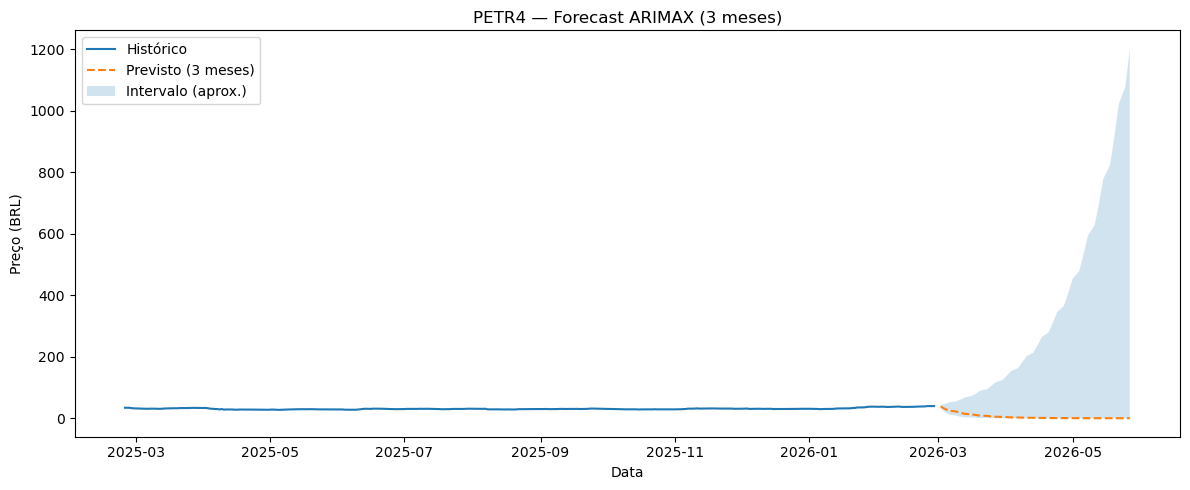

3 meses: preço previsto no final = 0.05 BRL


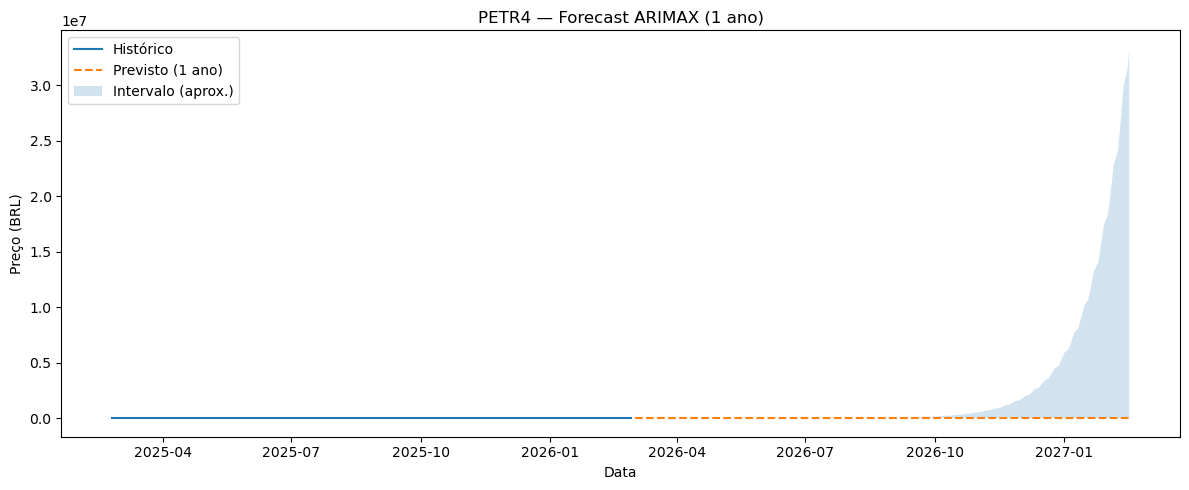

1 ano: preço previsto no final = 0.00 BRL


In [16]:
# Retornos diários
ret = px.pct_change().dropna(how="all")

# Retorno acumulado (base 1.0)
cumret = (1 + ret).cumprod()

# Performance (estatísticas)
ann_factor = 252  # pregões
perf = pd.DataFrame(index=px.columns)
perf["Cumulative Return"] = cumret.iloc[-1] - 1
perf["Annualized Return"] = (1 + perf["Cumulative Return"]) ** (ann_factor / len(ret)) - 1
perf["Annualized Volatility"] = ret.std() * np.sqrt(ann_factor)
perf["Sharpe (rf=0)"] = perf["Annualized Return"] / perf["Annualized Volatility"]
perf["Max Drawdown"] = (cumret / cumret.cummax() - 1).min()

# Volatilidade por períodos (rolling)
vol_21d = ret.rolling(21).std() * np.sqrt(ann_factor)
vol_63d = ret.rolling(63).std() * np.sqrt(ann_factor)

# Indicadores técnicos (SMA, EMA, Momentum)
def indicators(series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=series.index)
    df["price"] = series
    df["SMA_20"] = series.rolling(20).mean()
    df["SMA_50"] = series.rolling(50).mean()
    df["EMA_20"] = series.ewm(span=20, adjust=False).mean()
    df["EMA_50"] = series.ewm(span=50, adjust=False).mean()
    df["Momentum_20"] = series / series.shift(20) - 1
    df["Return"] = series.pct_change()
    return df

tech = {t: indicators(px[t].dropna()) for t in px.columns}

# Correlação entre ativos (retornos)
corr = ret.corr()

# ---- Fundamentais simples via yfinance (se disponível) ----
fund_cols = ["shortName", "sector", "industry", "marketCap", "trailingPE", "forwardPE", "priceToBook", "returnOnEquity"]
fund = []
for t in tickers:
    try:
        info = yf.Ticker(t).info
        row = {"Ticker": t}
        for c in fund_cols:
            row[c] = info.get(c, np.nan)
        fund.append(row)
    except Exception:
        fund.append({"Ticker": t, **{c: np.nan for c in fund_cols}})
fund = pd.DataFrame(fund).set_index("Ticker")

# ---- Exportar tudo para Excel ----
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    px.to_excel(writer, sheet_name="Prices_AdjClose")
    ret.to_excel(writer, sheet_name="Returns_Daily")
    cumret.to_excel(writer, sheet_name="Cumulative_Return")
    perf.to_excel(writer, sheet_name="Performance_Summary")
    vol_21d.to_excel(writer, sheet_name="Vol_21d_Ann")
    vol_63d.to_excel(writer, sheet_name="Vol_63d_Ann")
    corr.to_excel(writer, sheet_name="Correlation")
    fund.to_excel(writer, sheet_name="Fundamentals")

    # indicadores técnicos em abas separadas (uma por ativo)
    for t, df in tech.items():
        sheet = (t.replace("^", "").replace("=X", "_FX").replace(".SA", "_SA"))[:31]
        df.to_excel(writer, sheet_name=sheet)

print(f"OK! Arquivo gerado: {out_xlsx}")
print("Datas:", px.index.min().date(), "->", px.index.max().date())

/var/folders/gn/dx1c6sms7t97njh2f0xm8bkm0000gn/T/ipykernel_4878/1268233514.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.pct_change().dropna(how="all")


NameError: name 'out_xlsx' is not defined